# Performing the EDA on Social Media Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from plotly.subplots import make_subplots

from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import InterclusterDistance
import warnings
import kagglehub
warnings.filterwarnings('ignore')

# style
sb.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

c:\Users\jishn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Importing dataSet from the keggle

In [ ]:
path = kagglehub.dataset_download() # Run 2 times

NameError: name 'kagglehub' is not defined

In [8]:
df = pd.read_csv(r"C:\Users\jishn\OneDrive\Documents\DesginProject\Dataset\social_media_user_behavior.csv")

# Step 2: Data Processing

In [9]:
# Display content from DataSet
# In head() with parameter like head(10) to dispaly the number of rows
df.head()

,user_id,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,...,primary_purpose,sleep_disruption,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,account_join_date,mood_while_scrolling,takes_social_media_breaks
0,USR00001,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,...,Entertainment,No impact,3.9,No,Do Not Disturb,Friends Only,No,2022-10-21,Neutral,No
1,USR00002,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,...,News & Updates,Moderate impact,4.2,No,Selected,Public,No,2024-12-03,Neutral,Yes
2,USR00003,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,...,Learning,Mild impact,4.8,Yes,Always On,Friends Only,No,2023-03-29,Happy,Yes
3,USR00004,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,...,Entertainment,Mild impact,7.9,Somewhat,Always On,Public,Yes,2024-04-26,Happy,No
4,USR00005,25,Male,UK,Other,YouTube,3,3.9,7,33.4,...,Entertainment,Mild impact,6.5,No,Do Not Disturb,Public,No,2023-09-08,Inspired,No


In [10]:
df.shape

(2000, 34)

In [11]:
# Used to get a total summary of the data frame.
# It shows name of the 34 columns and how many non-null values are in each.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            2000 non-null   str    
 1   age                                2000 non-null   int64  
 2   gender                             2000 non-null   str    
 3   country                            2000 non-null   str    
 4   profession                         2000 non-null   str    
 5   primary_platform                   2000 non-null   str    
 6   platforms_used_count               2000 non-null   int64  
 7   daily_usage_hours                  2000 non-null   float64
 8   sessions_per_day                   2000 non-null   int64  
 9   avg_session_duration_min           2000 non-null   float64
 10  preferred_device                   2000 non-null   str    
 11  peak_usage_time                    2000 non-null   str    
 12  fol

In [ ]:
# Only for numirical column
# It is used to generate descriptive statistics of the dataset.
# It automatically calculate the count values, mean(avg), standard deviation, min and max values.

df.describe()

,age,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,followers_count,following_count,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,dms_sent_per_day,ad_click_rate,monthly_spend_via_social_usd,self_reported_mental_health_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.00000
mean,26.986000,3.010000,2.990650,5.024500,47.547400,4.153738e+03,513.9985,2.964000,19.883000,3.991500,1.988500,8.02600,0.130048,22.618225,6.17115
std,7.649775,1.431756,1.858501,2.249985,51.104393,4.793563e+04,851.8179,1.679915,4.389527,1.997354,1.413636,2.77618,0.094675,33.884331,1.74912
min,13.000000,1.000000,0.500000,1.000000,3.300000,0.000000e+00,4.0000,0.000000,6.000000,0.000000,0.000000,1.00000,0.001000,0.000000,1.00000
25%,22.000000,2.000000,1.600000,3.000000,18.975000,2.017500e+02,109.0000,2.000000,17.000000,3.000000,1.000000,6.00000,0.058750,0.000000,4.90000
50%,27.000000,3.000000,2.600000,5.000000,34.000000,6.880000e+02,249.0000,3.000000,20.000000,4.000000,2.000000,8.00000,0.108000,7.315000,6.20000
75%,32.000000,4.000000,3.900000,6.000000,56.000000,2.320500e+03,580.0000,4.000000,23.000000,5.000000,3.000000,10.00000,0.182000,33.632500,7.40000
max,57.000000,5.000000,12.000000,15.000000,594.000000,2.110323e+06,10000.0000,10.000000,38.000000,11.000000,8.000000,19.00000,0.585000,266.370000,10.00000


Remove the any Null values

In [12]:
# To check the null values in the dataset.
for col in df.columns:
  temp = df[col].isnull().sum()
  if temp > 0:
    print(f'Column{col} contains {temp} null values')

Now, once we have the count of the null values and we know the values are very less we can drop them as it will not affect the dataset much.

In [13]:
df = df.dropna() # To drop the null values from DataSet
print("Total values in the dataset after removing the null values is :", len(df))

Total values in the dataset after removing the null values is : 2000


To find the total number of unique values in each column we can use data.unique() method.

In [ ]:
df.nunique()

,0
user_id,2000
age,39
gender,4
country,10
profession,10
primary_platform,8
platforms_used_count,5
daily_usage_hours,94
sessions_per_day,15
avg_session_duration_min,379


As in dataset DT_object is prosent so need to seprate as day, month, year for account_join_date

In [14]:
df['account_join_date'] = pd.to_datetime(df['account_join_date'])
df['join_day'] = df['account_join_date'].dt.day
df['join_month'] = df['account_join_date'].dt.month
df['join_year'] = df['account_join_date'].dt.year

print("New columns created from 'account_join_date':")
print(df[['account_join_date', 'join_day', 'join_month', 'join_year']].head())


New columns created from 'account_join_date':
  account_join_date  join_day  join_month  join_year
0        2022-10-21        21          10       2022
1        2024-12-03         3          12       2024
2        2023-03-29        29           3       2023
3        2024-04-26        26           4       2024
4        2023-09-08         8           9       2023


In [16]:
# Separate numeric and categorical columns

numeric_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric Features:")
print(numeric_features)
print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
['age', 'platforms_used_count', 'daily_usage_hours', 'sessions_per_day', 'avg_session_duration_min', 'followers_count', 'following_count', 'posts_per_week', 'likes_given_per_day', 'comments_per_day', 'shares_per_day', 'dms_sent_per_day', 'ad_click_rate', 'monthly_spend_via_social_usd', 'self_reported_mental_health_score', 'join_day', 'join_month', 'join_year']

Categorical Features:
['user_id', 'gender', 'country', 'profession', 'primary_platform', 'preferred_device', 'peak_usage_time', 'preferred_content_type', 'scroll_speed', 'purchased_via_social_media', 'primary_purpose', 'sleep_disruption', 'screen_time_concern', 'notification_frequency', 'privacy_setting', 'influencer_status', 'mood_while_scrolling', 'takes_social_media_breaks']


# Step 3: EDA Data Visualization and Analysis


## Bivariate Analysis (Relationships)

### daily_usage_hours VS self_reported_mental_health_score

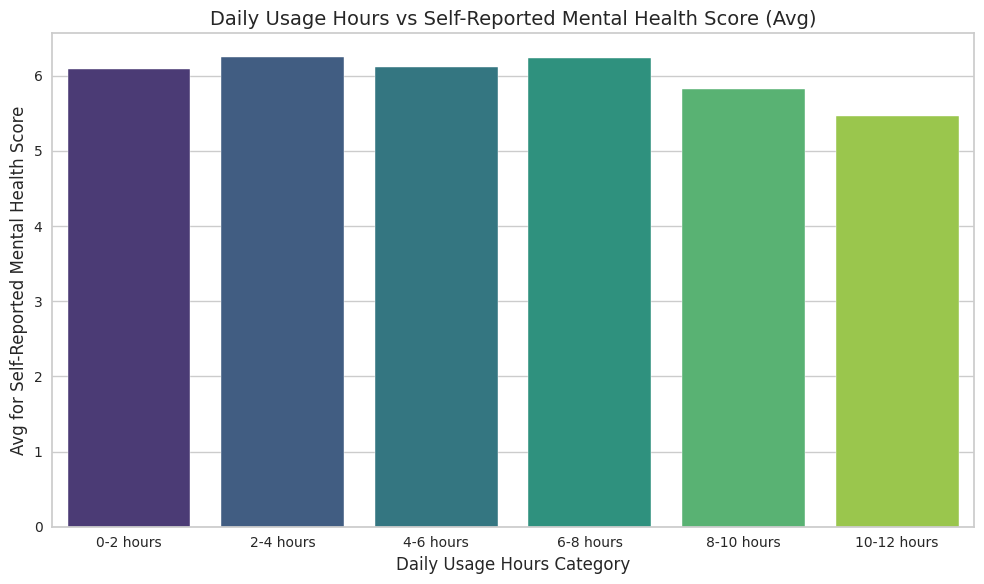

In [ ]:
# Categorize 'daily_usage_hours' into bins.
max_usage = df['daily_usage_hours'].max()

# It takes the continuous daily_usage_hours column and groups it into 2-hour intervals
bins = np.arange(0, max_usage + 2, 2)

# Create user-friendly labels for the bins.
labels = [f'{int(b)}-{int(b+2)} hours' for b in bins[:-1]]

# Create a temporary 'daily_usage_category' series for grouping.
daily_usage_category_temp = pd.cut(df['daily_usage_hours'], bins=bins, labels=labels, right=False, include_lowest=True)
daily_usage_category_temp.name = 'daily_usage_category'

# Calculate the standard deviation of 'self_reported_mental_health_score' for each category.
avg_mental_health = df.groupby(daily_usage_category_temp, observed=False)['self_reported_mental_health_score'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Create a bar plot to visualize the average scores.
sb.barplot(x='daily_usage_category', y='self_reported_mental_health_score', data=avg_mental_health, palette='viridis')
plt.title('Daily Usage Hours vs Self-Reported Mental Health Score (Avg)', fontsize=14)
plt.xlabel('Daily Usage Hours Category', fontsize=12)
plt.ylabel('Avg for Self-Reported Mental Health Score', fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### DAILY USAGE vs SLEEP DISRUPTION

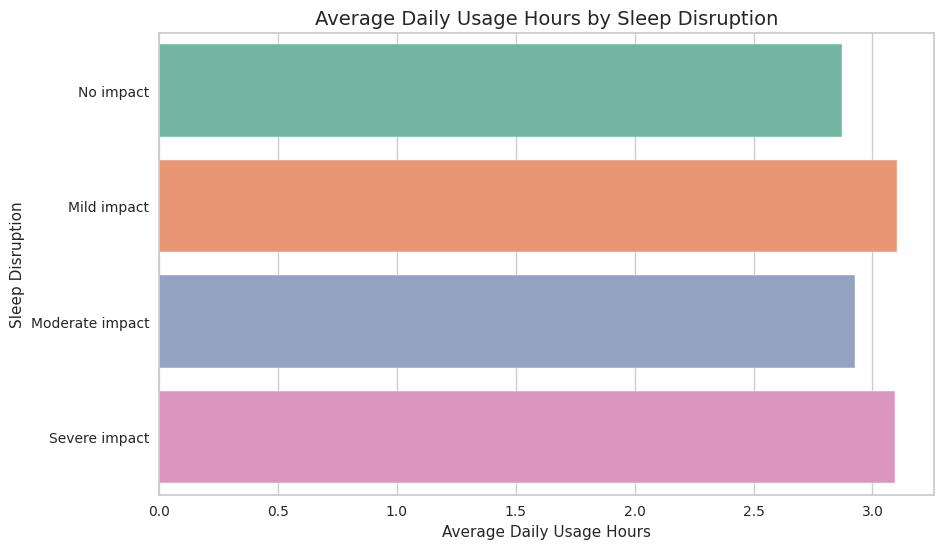

In [ ]:
# Calculate the mean daily usage hours for each sleep disruption category
avg_daily_usage_by_sleep = df.groupby('sleep_disruption')['daily_usage_hours'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Create a bar plot using the aggregated data
# x-axis: Average Daily Usage Hours, y-axis: Sleep Disruption categories
# Order the sleep disruption categories for better readability (from least to most impact)

sb.barplot(x='daily_usage_hours',
           y='sleep_disruption',
           data=avg_daily_usage_by_sleep,
           palette='Set2',
           order=['No impact', 'Mild impact', 'Moderate impact', 'Severe impact']
           )

plt.title("Average Daily Usage Hours by Sleep Disruption", fontsize=14)
plt.xlabel('Average Daily Usage Hours')
plt.ylabel('Sleep Disruption')
plt.show()

### AD CLICK RATE vs MONTHLY SPENDING

 To make the relationship between monthly spending and ad click rate clearer, we will categorize the 'monthly_spend_via_social_usd' column.

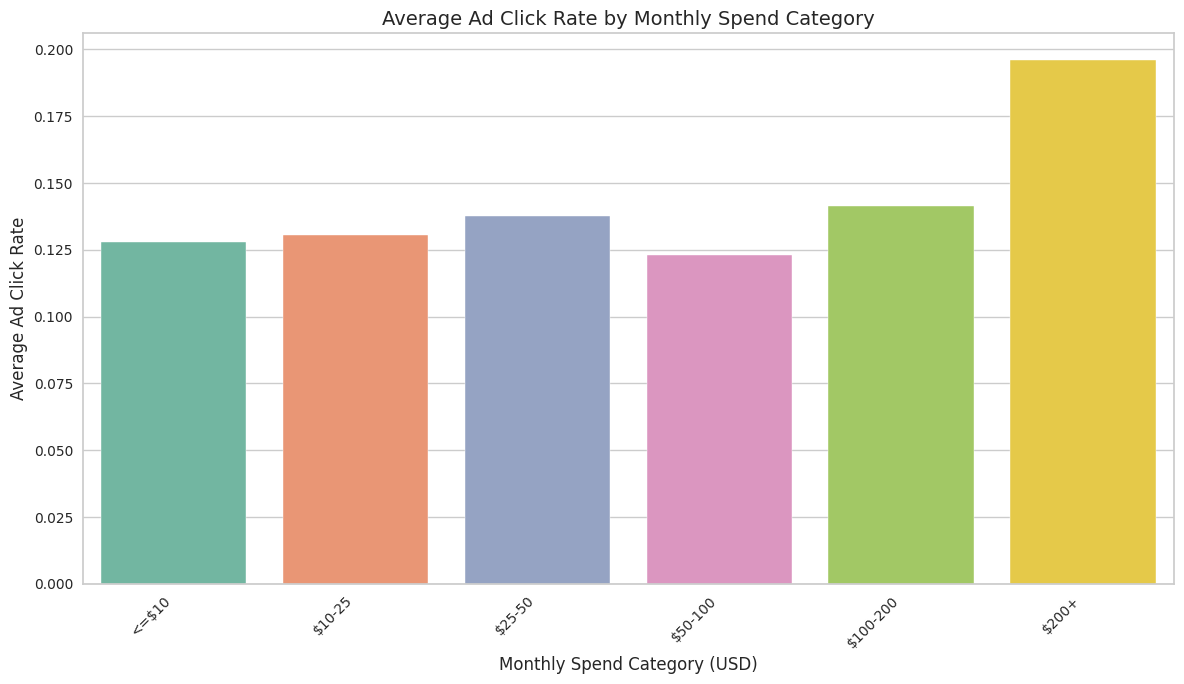

In [ ]:

bins = [0, 10, 25, 50, 100, 200, df['monthly_spend_via_social_usd'].max() + 1]
labels = ['<=$10', '$10-25', '$25-50', '$50-100', '$100-200', '$200+']

df['monthly_spend_category'] = pd.cut(df['monthly_spend_via_social_usd'], bins=bins, labels=labels, right=False, include_lowest=True)
avg_ad_click_rate_by_spend = df.groupby('monthly_spend_category', observed=False)['ad_click_rate'].mean().reset_index()

plt.figure(figsize=(12, 7))
sb.barplot(x='monthly_spend_category', y='ad_click_rate', data=avg_ad_click_rate_by_spend, palette='Set2')

plt.title("Average Ad Click Rate by Monthly Spend Category", fontsize=14)
plt.xlabel("Monthly Spend Category (USD)", fontsize=12)
plt.ylabel("Average Ad Click Rate", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Remove the temporary 'monthly_spend_category' column to keep the DataFrame clean.
df = df.drop(columns=['monthly_spend_category'])

###  PLATFORM vs DAILY USAGE

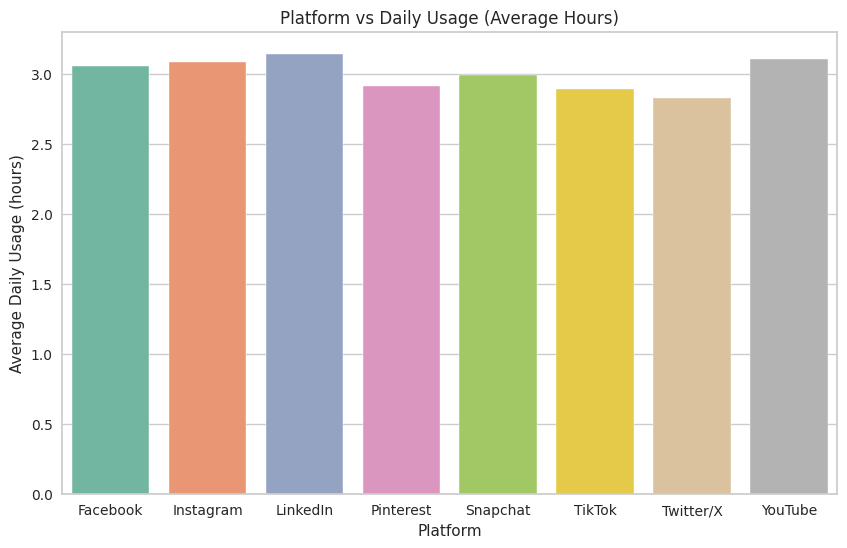

In [ ]:
# Calculate the mean daily usage hours for each primary platform
platform_usage = df.groupby('primary_platform')['daily_usage_hours'].mean().reset_index()

plt.figure(figsize=(10, 6))
sb.barplot(x='primary_platform', y='daily_usage_hours', data=platform_usage, palette='Set2')
plt.xlabel('Platform')
plt.ylabel('Average Daily Usage (hours)')
plt.title("Platform vs Daily Usage (Average Hours)")
plt.show()

### GENDER vs DAILY USAGE

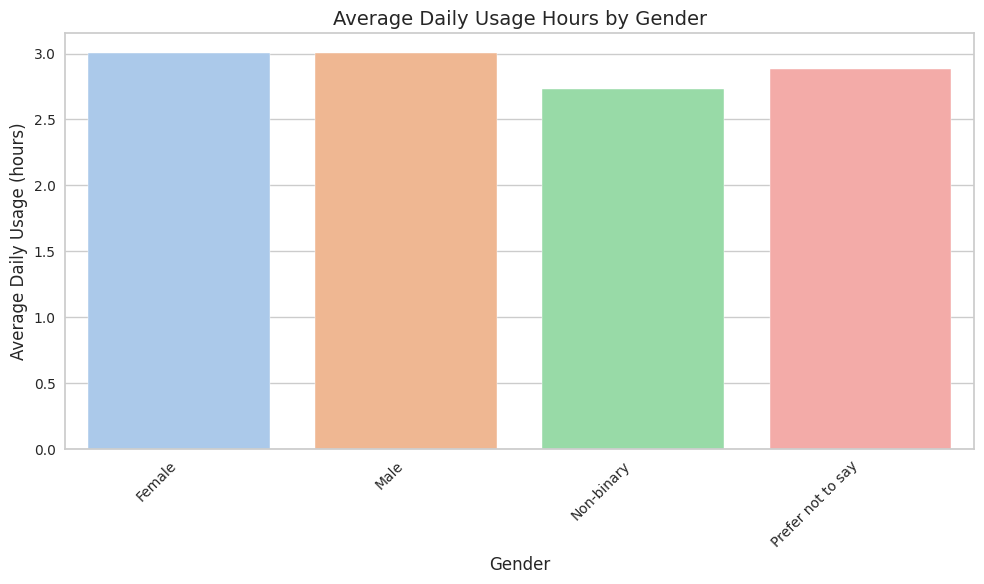

In [ ]:
# Calculate the average daily usage hours for each gender using mean()
avg_daily_usage_by_gender = df.groupby('gender')['daily_usage_hours'].mean().reset_index()

plt.figure(figsize=(10, 6))
# Create a bar plot to visualize the average daily usage hours by gender
sb.barplot(x='gender', y='daily_usage_hours', data=avg_daily_usage_by_gender, palette='pastel')

plt.title("Average Daily Usage Hours by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Daily Usage (hours)", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

###  FOLLOWERS vs POSTS PER WEEK


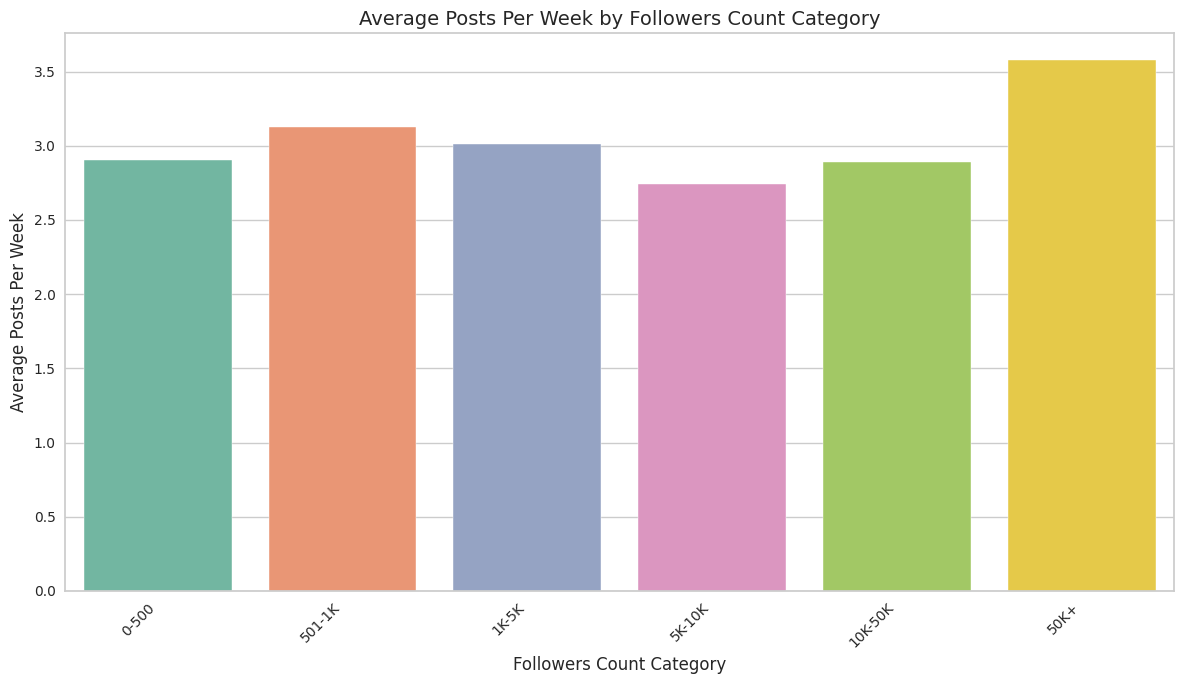

In [ ]:
# To make the relationship between followers and posts per week clearer, we will categorize the 'followers_count' column.
# Define bins for followers_count. These are chosen to represent different tiers of follower counts.
bins = [0, 500, 1000, 5000, 10000, 50000, df['followers_count'].max() + 1]

# Define labels for these bins to be displayed on the plot.
labels = ['0-500', '501-1K', '1K-5K', '5K-10K', '10K-50K', '50K+']

# Create a new categorical column 'followers_category' using pd.cut.
df['followers_category'] = pd.cut(df['followers_count'], bins=bins, labels=labels, right=False, include_lowest=True)

# Calculate the average posts per week for each new followers category.
avg_posts_by_followers = df.groupby('followers_category', observed=False)['posts_per_week'].mean().reset_index()

plt.figure(figsize=(12, 7))
# Create a bar plot using the aggregated data.
sb.barplot(x='followers_category', y='posts_per_week', data=avg_posts_by_followers, palette='Set2')

plt.title("Average Posts Per Week by Followers Count Category", fontsize=14)
plt.xlabel("Followers Count Category", fontsize=12)
plt.ylabel("Average Posts Per Week", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Remove the temporary 'followers_category' column to keep the DataFrame clean.
df = df.drop(columns=['followers_category'])

### INFLUENCER vs NORMAL USERS

Followers Comparison

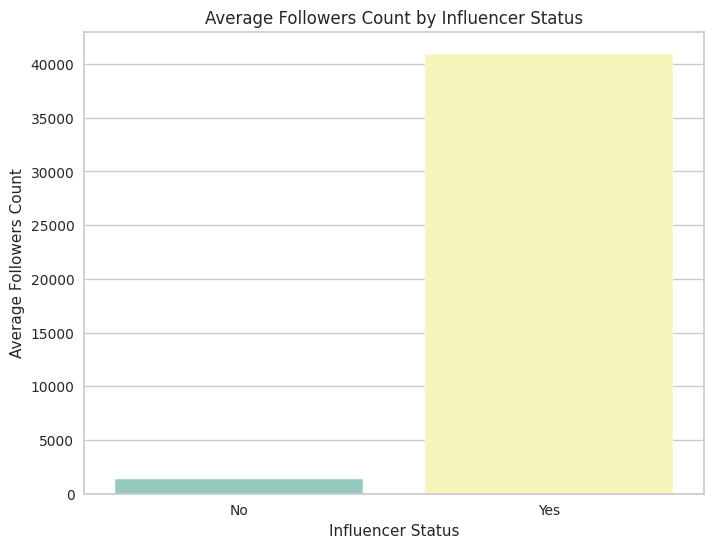

In [ ]:
# Calculate the average followers count for each influencer status
avg_followers_by_status = df.groupby('influencer_status')['followers_count'].mean().reset_index()

plt.figure(figsize=(8,6))
sb.barplot(
    x= 'influencer_status',
    y= 'followers_count',
    data=avg_followers_by_status,
    palette='Set3'
)

plt.title('Average Followers Count by Influencer Status')
plt.xlabel('Influencer Status')
plt.ylabel('Average Followers Count')
plt.show()

Posts Per Week Comparison

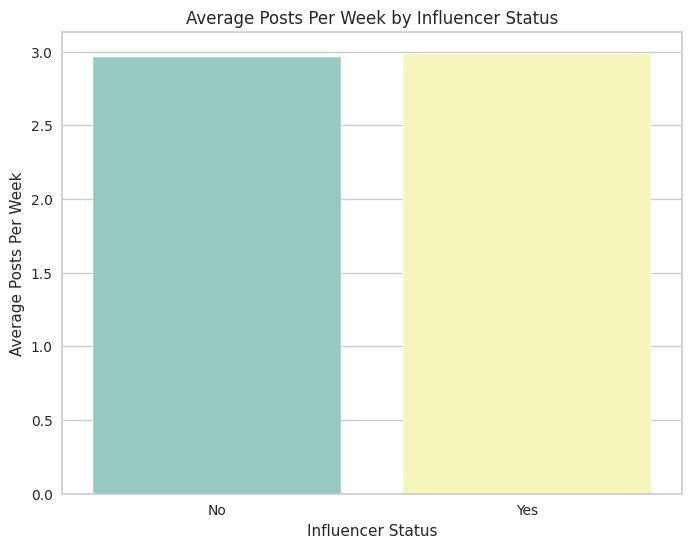

In [ ]:
avg_post_per_week_by_status = df.groupby('influencer_status')['posts_per_week'].mean().reset_index()

plt.figure(figsize=(8,6))
sb.barplot(
    x= 'influencer_status',
    y= 'posts_per_week',
    data=avg_post_per_week_by_status,
    palette='Set3'
)

plt.title('Average Posts Per Week by Influencer Status')
plt.xlabel('Influencer Status')
plt.ylabel('Average Posts Per Week')
plt.show()

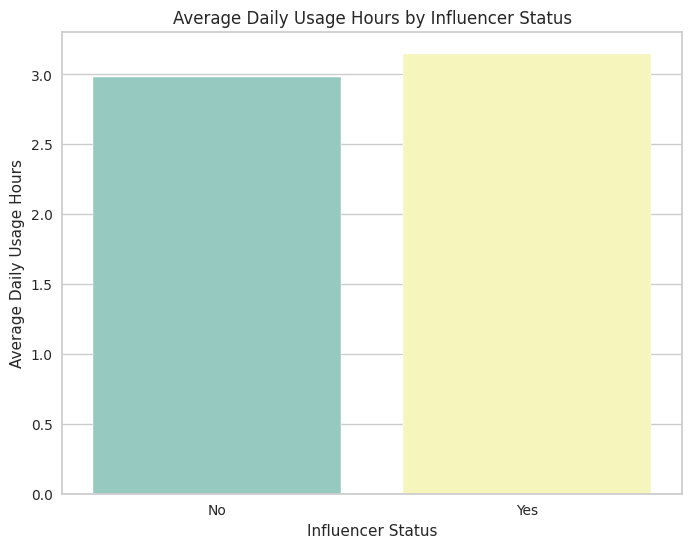

In [ ]:
# Usage Hours Comparison

avg_usage_hours_by_status = df.groupby('influencer_status')['daily_usage_hours'].mean().reset_index()

plt.figure(figsize=(8,6))
sb.barplot(
    x= 'influencer_status',
    y= 'daily_usage_hours',
    data=avg_usage_hours_by_status,
    palette='Set3'
)

plt.title('Average Daily Usage Hours by Influencer Status')
plt.xlabel('Influencer Status')
plt.ylabel('Average Daily Usage Hours')
plt.show()

###  SCREEN TIME CONCERN vs USAGE

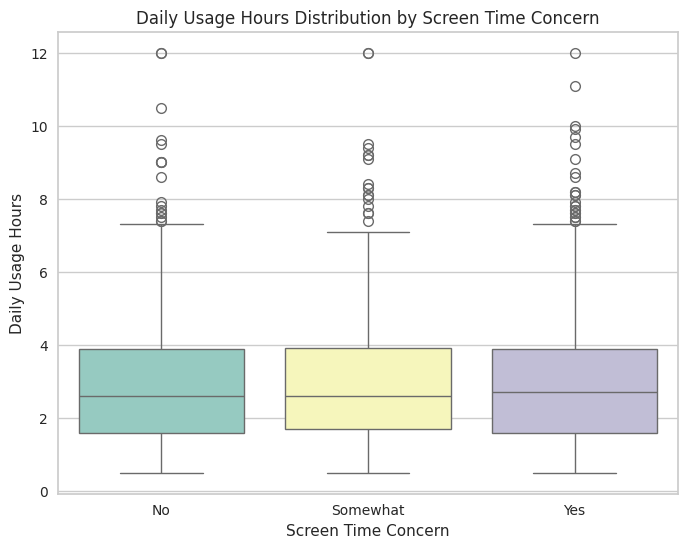

In [ ]:
# Define the order for the x-axis categories
concern_order = ['No', 'Somewhat', 'Yes']

plt.figure(figsize=(8,6))
sb.boxplot(
    x='screen_time_concern',
    y='daily_usage_hours',
    data=df,
    palette='Set3',
    order=concern_order
)

plt.title('Daily Usage Hours Distribution by Screen Time Concern')
plt.xlabel('Screen Time Concern')
plt.ylabel('Daily Usage Hours')
plt.show()

### PURCHASE BEHAVIOR ANALYSIS

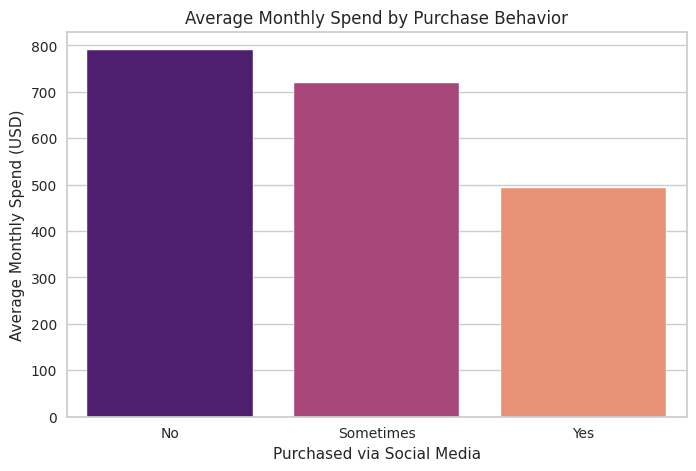

In [ ]:
# Average Monthly Spend via Social Media by Purchase Behavior
avg_monthly_spend_by_purchase = df.groupby('purchased_via_social_media')['monthly_spend_via_social_usd'].count().reset_index()

plt.figure(figsize=(8, 5))
sb.barplot(
    x='purchased_via_social_media',
    y='monthly_spend_via_social_usd',
    data=avg_monthly_spend_by_purchase,
    palette='magma',
    order=df['purchased_via_social_media'].value_counts().index
)
plt.title('Average Monthly Spend by Purchase Behavior')
plt.xlabel('Purchased via Social Media')
plt.ylabel('Average Monthly Spend (USD)')
plt.show()



### sessions_per_day VS avg_session_duration_min  

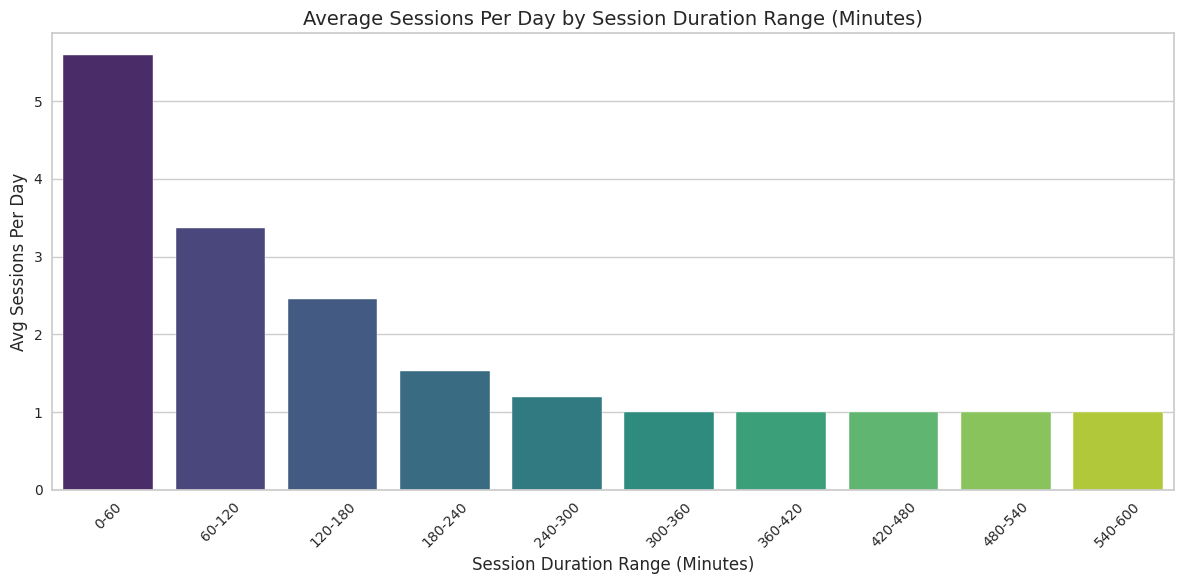

In [ ]:
# 1. Create 30-minute bins for session duration with clean labels
bins = np.arange(0, df['avg_session_duration_min'].max() + 60, 60)
labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]

df['duration_range'] = pd.cut(df['avg_session_duration_min'], bins=bins, labels=labels, right=True)

# 2. Plot the average sessions per day for each range
plt.figure(figsize=(12, 6))
sb.barplot(x='duration_range', y='sessions_per_day', data=df, palette='viridis', ci=None)

plt.title('Average Sessions Per Day by Session Duration Range (Minutes)', fontsize=14)
plt.xlabel('Session Duration Range (Minutes)', fontsize=12)
plt.ylabel('Avg Sessions Per Day', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cleanup
df.drop(columns=['duration_range'], inplace=True)

### daily_usage_hours VS avg_session_duration_min

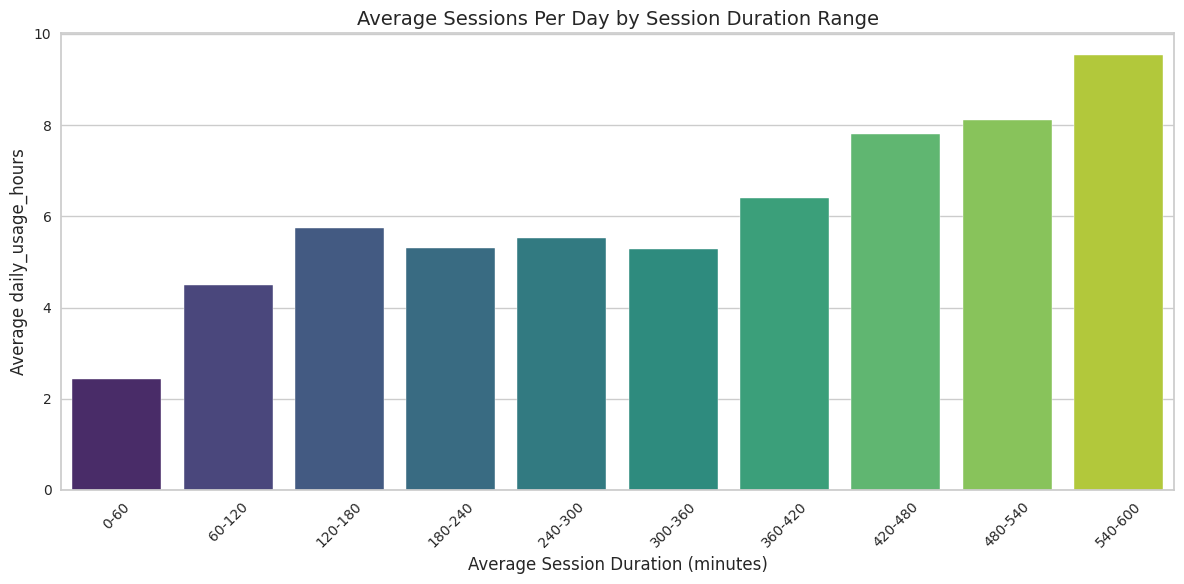

In [ ]:
# To make the plot clearer, we bin the continuous duration variable
bins = np.arange(0, df['avg_session_duration_min'].max() + 60, 60)

labels = [f'{int(b)}-{int(b+60)}' for b in bins[:-1]]

# Create temporary bins for plotting
df['duration_bin'] = pd.cut(df['avg_session_duration_min'], bins=bins, labels=labels, right=False)

# Calculate mean sessions per day for each duration bin
avg_sessions_bin = df.groupby('duration_bin', observed=False)['daily_usage_hours'].mean().reset_index()

plt.figure(figsize=(12, 6))
sb.barplot(
    x='duration_bin',
    y='daily_usage_hours',
    data=avg_sessions_bin,
    palette='viridis'
)

plt.title('Average Sessions Per Day by Session Duration Range', fontsize=14)
plt.xlabel('Average Session Duration (minutes)', fontsize=12)
plt.ylabel('Average daily_usage_hours', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Clean up
df = df.drop(columns=['duration_bin'])


### comments_per_day VS daily_usage_hours

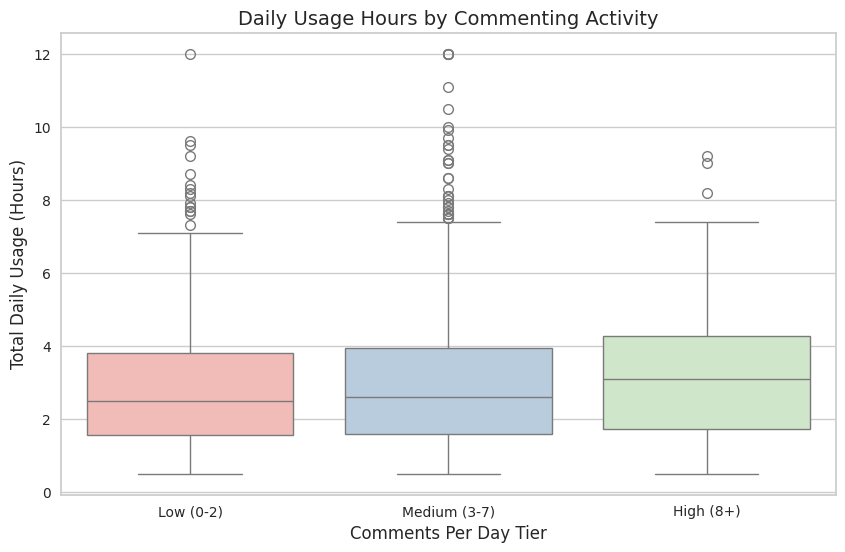

In [ ]:
# Binning comments into clear categories instead of plotting every single number
def comment_tier(x):
    if x <= 2: return 'Low (0-2)'
    if x <= 7: return 'Medium (3-7)'
    return 'High (8+)'

df['comment_tier'] = df['comments_per_day'].apply(comment_tier)

plt.figure(figsize=(10, 6))
sb.boxplot(x='comment_tier', y='daily_usage_hours', data=df,
            palette='Pastel1', order=['Low (0-2)', 'Medium (3-7)', 'High (8+)'])

plt.title('Daily Usage Hours by Commenting Activity', fontsize=14)
plt.xlabel('Comments Per Day Tier', fontsize=12)
plt.ylabel('Total Daily Usage (Hours)', fontsize=12)
plt.show()

df = df.drop(columns=['comment_tier'])

### avg_session_duration_min VS following_count

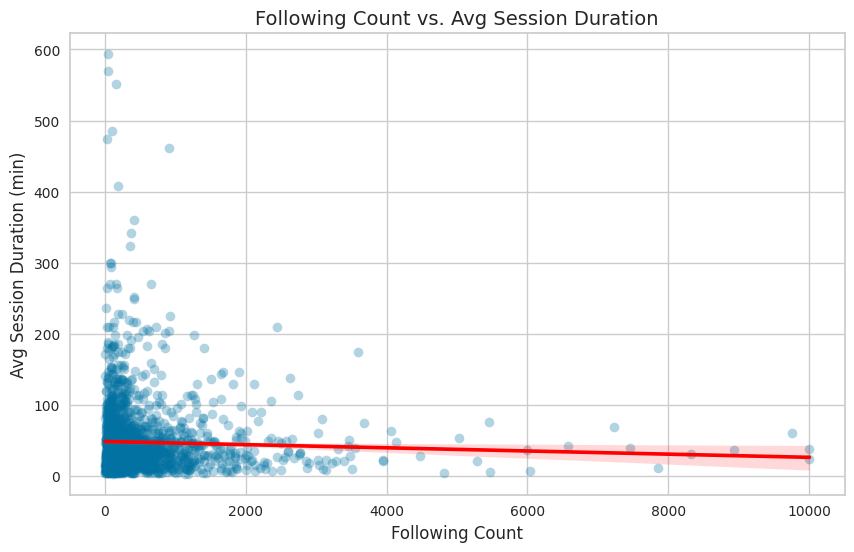

In [ ]:
plt.figure(figsize=(10, 6))
# Using a regression plot to show the relationship between following count and session duration
sb.regplot(
    x='following_count',
    y='avg_session_duration_min',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Following Count vs. Avg Session Duration', fontsize=14)
plt.xlabel('Following Count', fontsize=12)
plt.ylabel('Avg Session Duration (min)', fontsize=12)
plt.show()

### self_reported_mental_health_score   vs    shares_per_day  

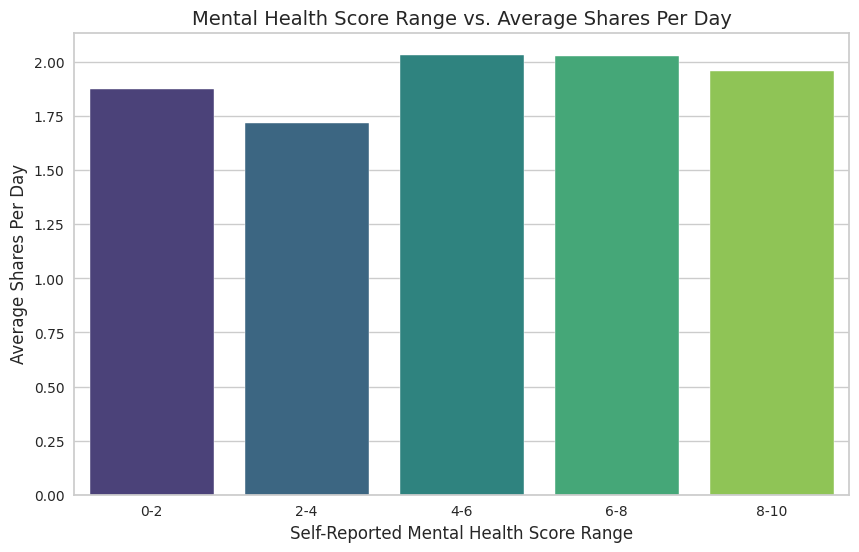

In [ ]:
# Binning Mental Health Scores into groups of 2
bins = [0, 2, 4, 6, 8, 11]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10']

# Create a temporary binned column
df['mental_health_bin'] = pd.cut(df['self_reported_mental_health_score'], bins=bins, labels=labels, right=False)

# Calculate mean shares per day for each bin
avg_shares_binned = df.groupby('mental_health_bin', observed=False)['shares_per_day'].mean().reset_index()

plt.figure(figsize=(10, 6))
sb.barplot(
    x='mental_health_bin',
    y='shares_per_day',
    data=avg_shares_binned,
    palette='viridis'
)

plt.title('Mental Health Score Range vs. Average Shares Per Day', fontsize=14)
plt.xlabel('Self-Reported Mental Health Score Range', fontsize=12)
plt.ylabel('Average Shares Per Day', fontsize=12)
plt.show()

# Clean up
df = df.drop(columns=['mental_health_bin'])

### country VS daily usage hours

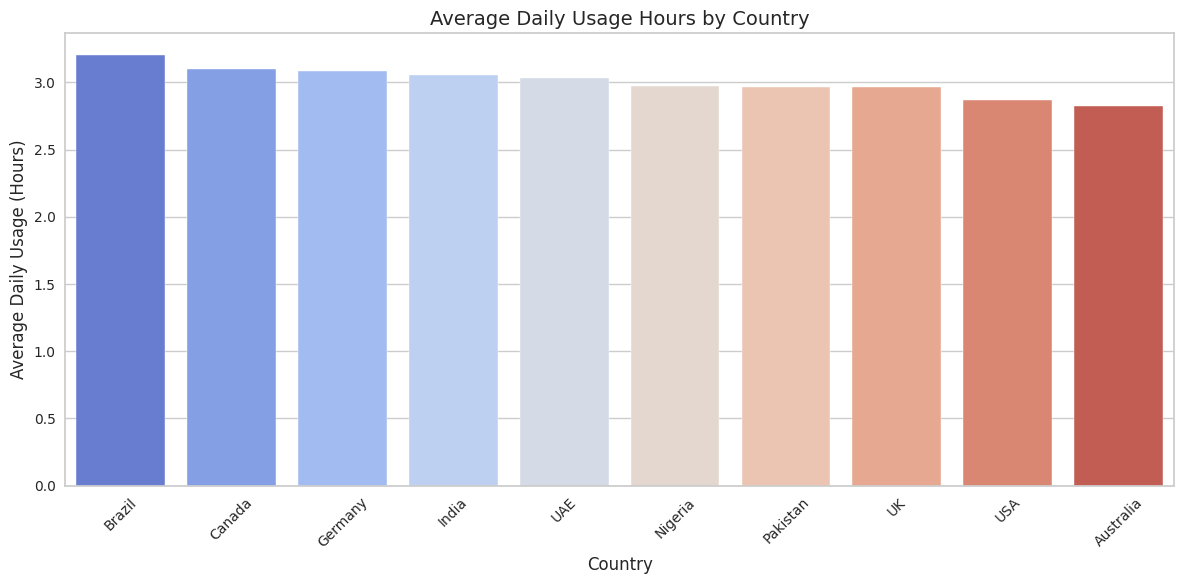

In [ ]:
# Calculate the average daily usage hours for each country
country_usage = df.groupby('country')['daily_usage_hours'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
# Create a bar plot to show the average usage per country
sb.barplot(x='country', y='daily_usage_hours', data=country_usage, palette='coolwarm')

plt.title('Average Daily Usage Hours by Country', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Daily Usage (Hours)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation measures how strongly two variables move together.

Positive Correlation (+) ---> If one increases, the other also increases.

Negative Correlation (-) ---> If one increases, the other decreases.

No Correlation (0) --> No relationship.



**Correlation Matrix & HeatMap**

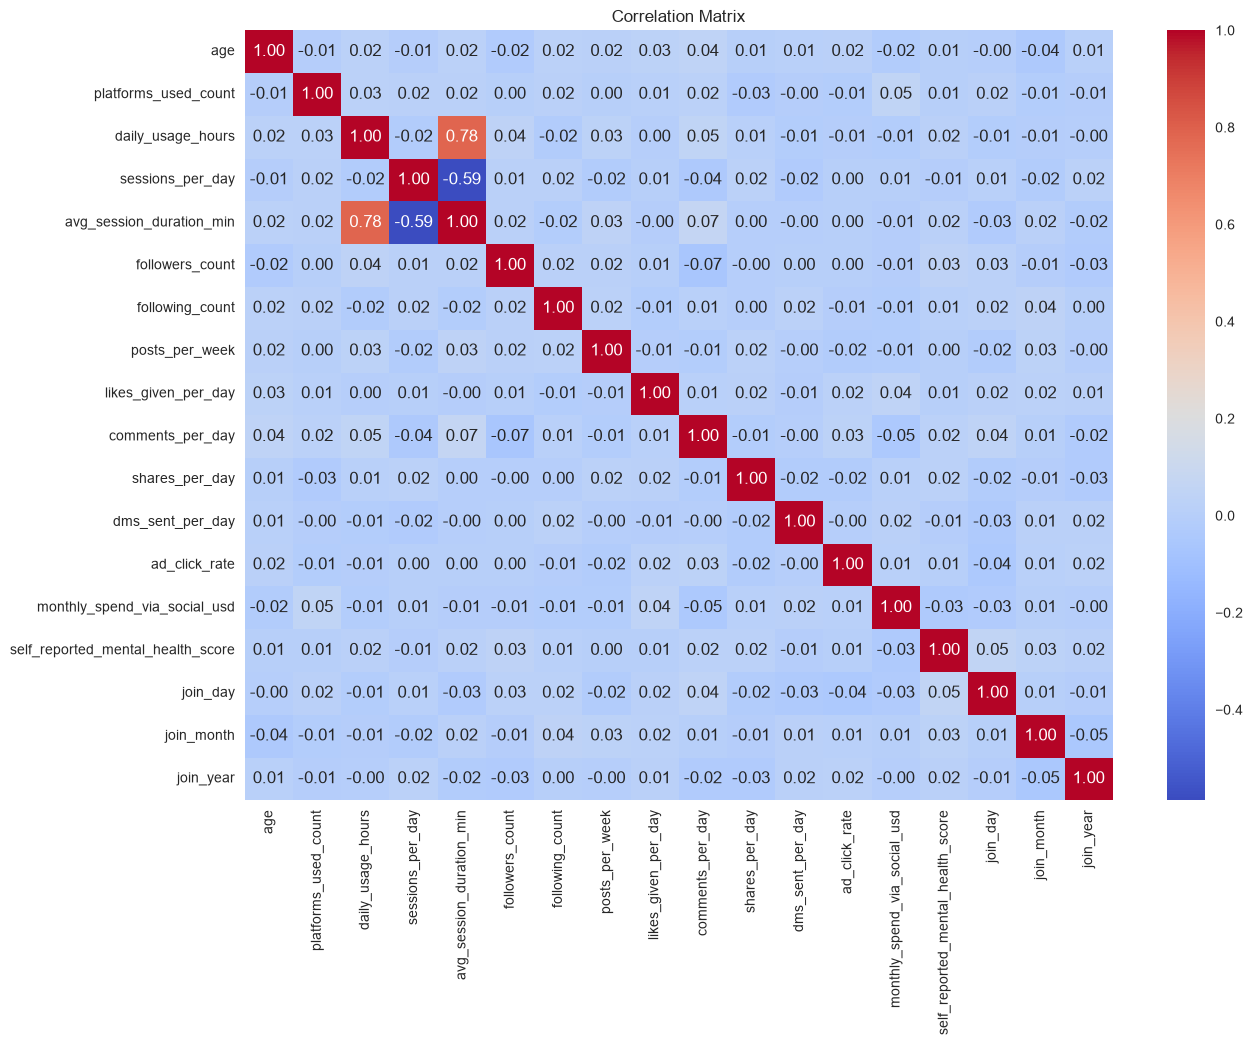

In [17]:
corr = df.corr(
    method='spearman', # Use Spearman correlation, which is suitable for non-normally distributed data or ordinal variables.
    numeric_only=True # Only consider numerical columns for correlation calculation.
)

plt.figure(figsize=(14,10))
sb.heatmap(
    corr, # The correlation matrix to be plotted.
    annot=True, # Display the correlation values on the heatmap cells.
    cmap='coolwarm', # Color map to use for the heatmap (coolwarm shows positive in red, negative in blue).
    fmt=".2f" # Format the annotation values to two decimal places.
)
plt.title("Correlation Matrix")
plt.show()

**TOP CORRELATION PAIRS**

In [ ]:
# Converts the matrix into a Series with unstack(), with sort_value() will sort correlations from highest to lowest.
corr_pairs = corr.unstack().sort_values(ascending=False)

# This removes duplicate values. like Age ↔ Salary = 0.75, Salary ↔ Age = 0.75
corr_pairs = corr_pairs.drop_duplicates()

print("\nTop Correlations:\n", corr_pairs.head(10)) # Shows the top 20 highest correlations.


Top Correlations:
 join_year                     join_year                            1.000000
daily_usage_hours             avg_session_duration_min             0.784670
avg_session_duration_min      comments_per_day                     0.069992
join_day                      self_reported_mental_health_score    0.051950
comments_per_day              daily_usage_hours                    0.048711
platforms_used_count          monthly_spend_via_social_usd         0.047970
age                           comments_per_day                     0.043956
comments_per_day              join_day                             0.039880
monthly_spend_via_social_usd  likes_given_per_day                  0.039337
daily_usage_hours             followers_count                      0.035378
dtype: float64


**TARGETED CORRELATION**

In [ ]:
corr = df.corr(
    method='spearman', # Use Spearman correlation, which is suitable for non-normally distributed data or ordinal variables.
    numeric_only=True # Only consider numerical columns for correlation calculation.
)

# Correlation with daily_usage_hours
target = 'daily_usage_hours'
print(f"\nCorrelation with {target}:\n",
      corr[target].sort_values(ascending=False)
      )


Correlation with daily_usage_hours:
 daily_usage_hours                    1.000000
avg_session_duration_min             0.784670
comments_per_day                     0.048711
followers_count                      0.035378
posts_per_week                       0.031092
platforms_used_count                 0.025196
age                                  0.024184
self_reported_mental_health_score    0.019070
shares_per_day                       0.011085
likes_given_per_day                  0.000190
join_year                           -0.003911
ad_click_rate                       -0.006689
join_month                          -0.009976
join_day                            -0.010404
dms_sent_per_day                    -0.013682
monthly_spend_via_social_usd        -0.014822
following_count                     -0.017668
sessions_per_day                    -0.020055
Name: daily_usage_hours, dtype: float64


#### Outliners Detection

A boxplot helps identify outliers, which are values that are unusually high or low compared to the rest of the data.

Components of a Boxplot


*  Box → Represents the middle 50% of data (Interquartile Range - IQR).
*   Middle Line → Median (50th percentile).
*   Middle Line → Median (50th percentile).
*   Whiskers → Normal range of data.
*   Whiskers → Normal range of data.
*   Dots outside whiskers → Potential outliers.


**Boxplots for all numerical columns**

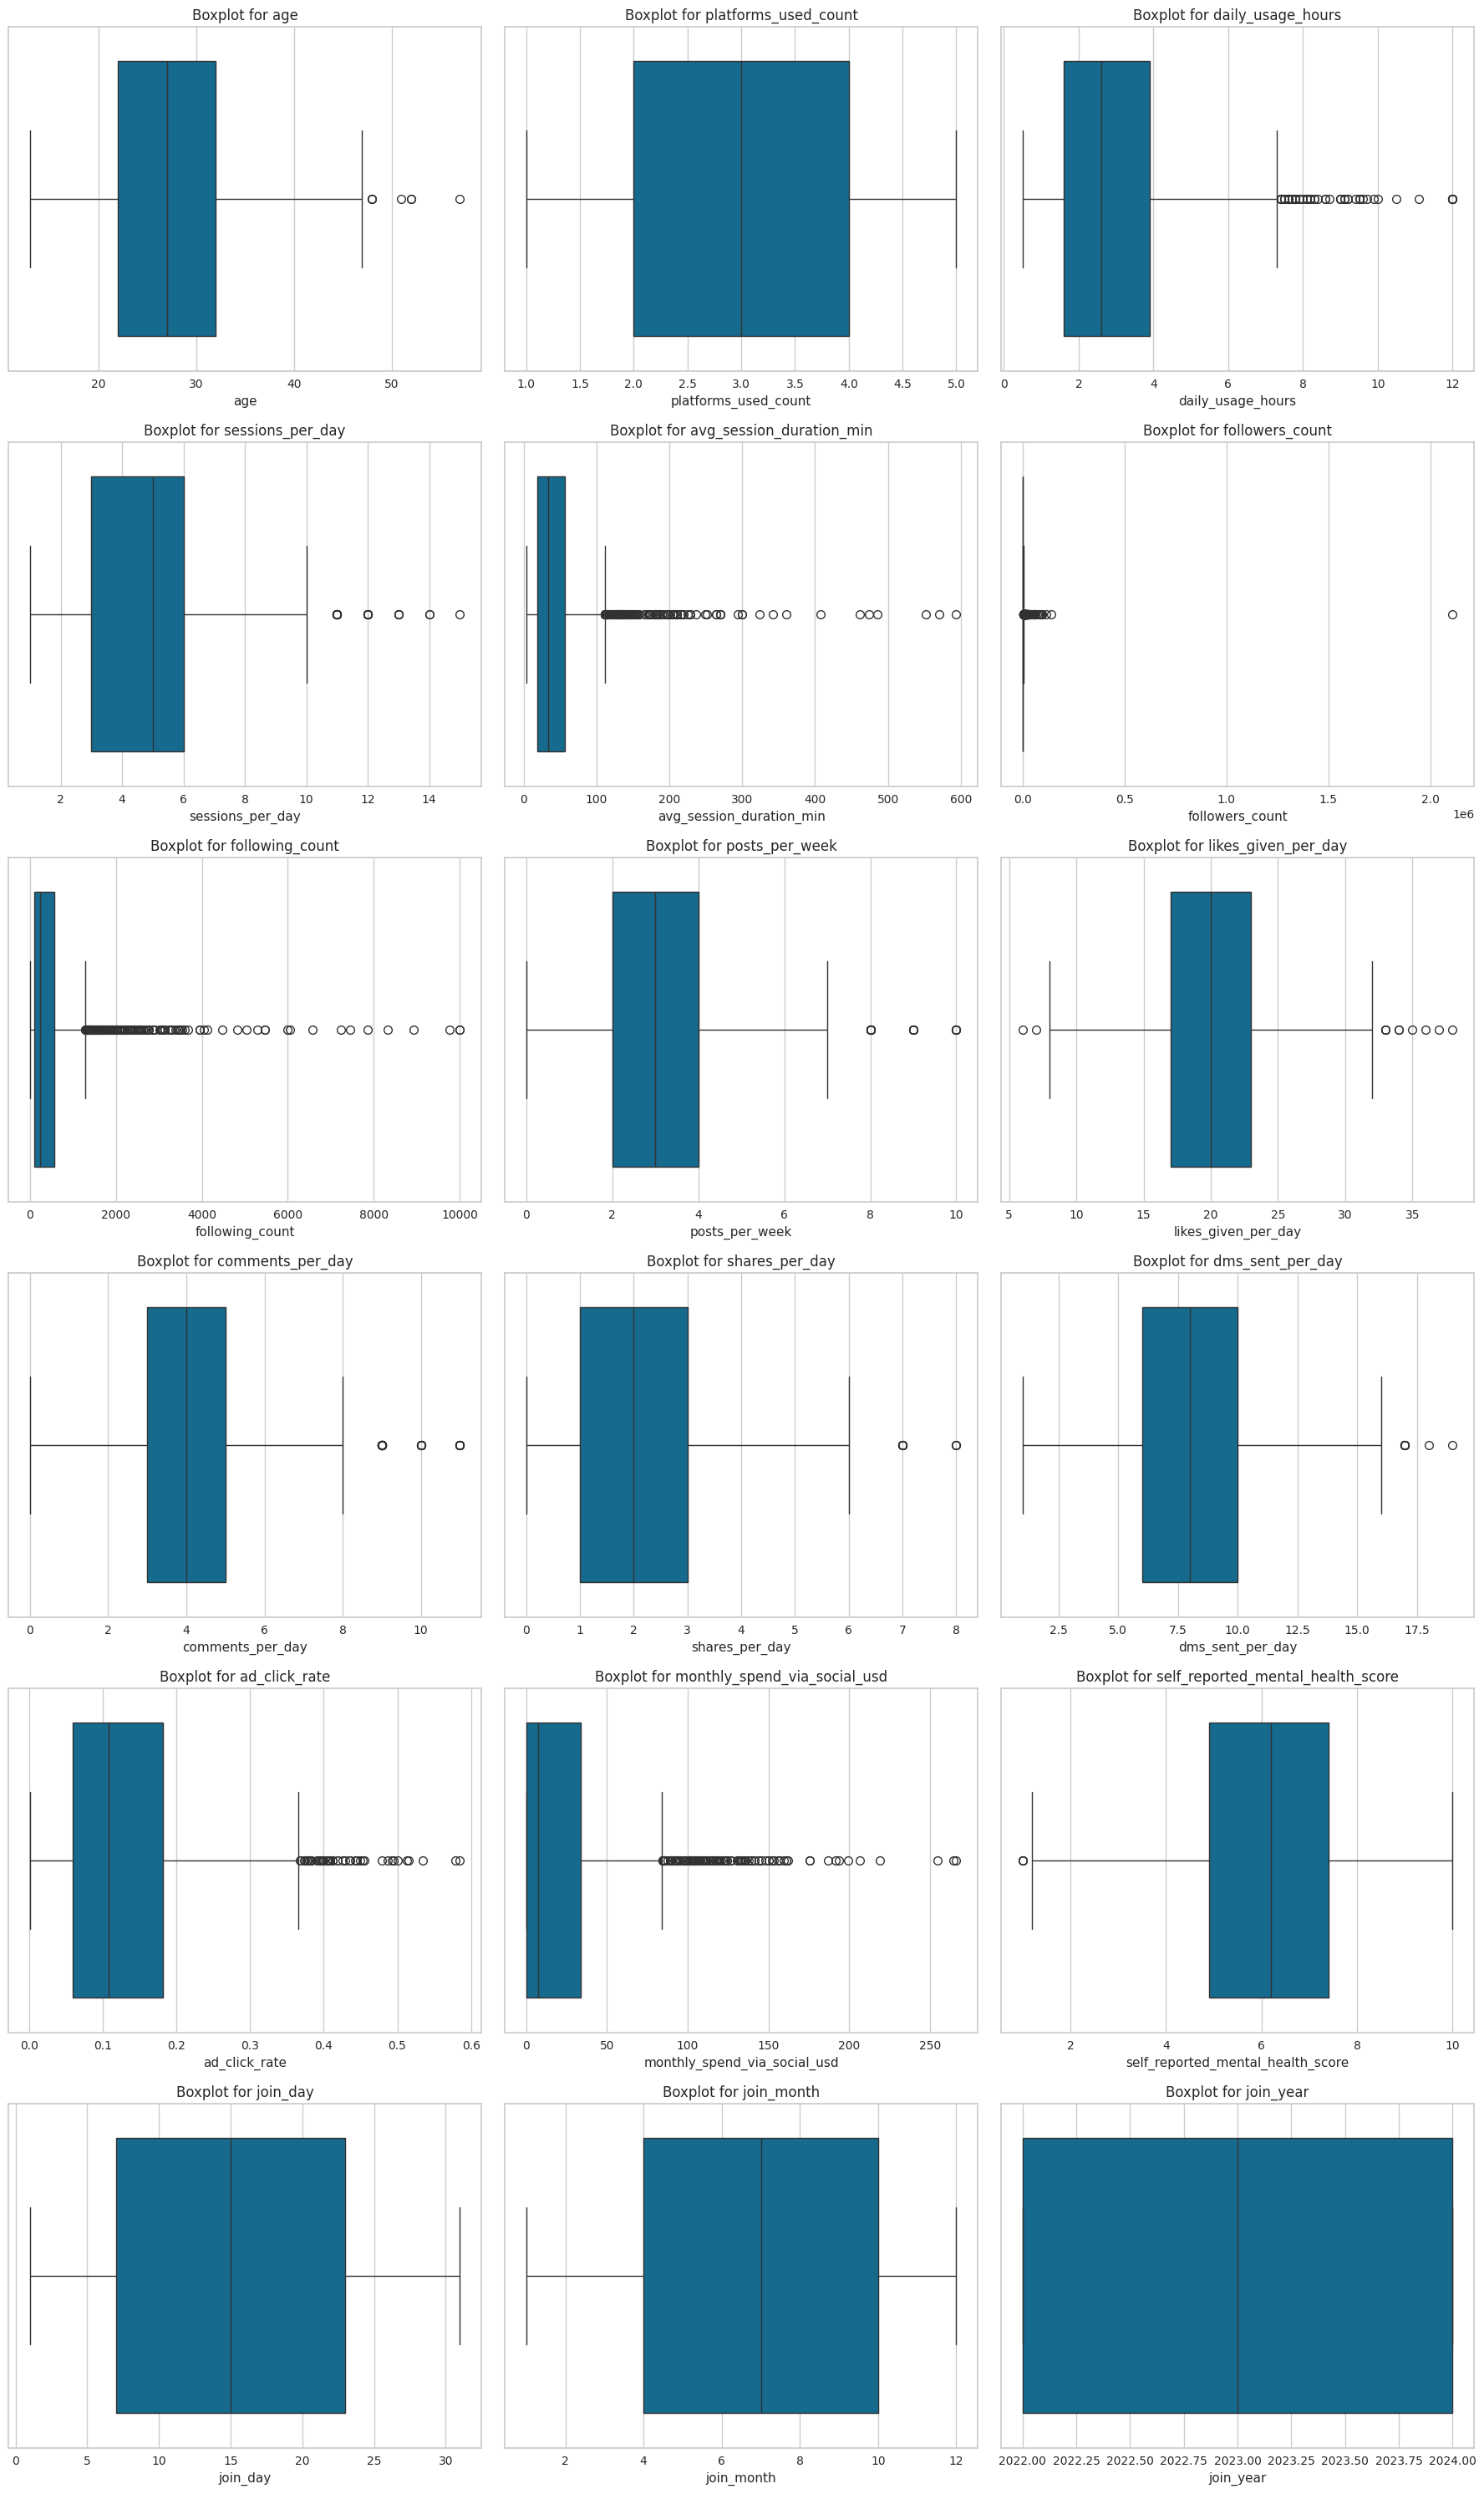

In [ ]:
# Total number of numerical features/columns
num_features = len(numeric_features)

# Calculate the number of rows needed if we display 3 boxplots per row
rows = (num_features + 2) // 3

# Create a grid of subplots with 3 columns
# figsize controls the overall figure size
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))

# Convert the subplot axes array into a 1D array for easy iteration
axes = axes.flatten()

# Loop through each numerical column
for i, col in enumerate(numeric_features):

    # Draw a boxplot for the current column
    # Boxplots are commonly used in EDA to detect outliers
    sb.boxplot(x=df[col], ax=axes[i])

    # Set title for each boxplot
    axes[i].set_title(f'Boxplot for {col}')

# Adjust spacing between plots to avoid overlapping
plt.tight_layout()

# Display all boxplots
plt.show()

### **FEATURE REMOVAL**



In [18]:
drop_cols = [
    'user_id', # Removing it bcs doesn't describe user behaviour
    'account_join_date', # we have already created separate date, year, month columns
]
df_cleaned = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [19]:
df_cleaned.head()

,age,gender,country,profession,primary_platform,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,preferred_device,...,self_reported_mental_health_score,screen_time_concern,notification_frequency,privacy_setting,influencer_status,mood_while_scrolling,takes_social_media_breaks,join_day,join_month,join_year
0,30,Female,UK,Doctor,Facebook,1,1.6,2,48.0,Smartphone,...,3.9,No,Do Not Disturb,Friends Only,No,Neutral,No,21,10,2022
1,25,Male,USA,Entrepreneur,Instagram,2,2.4,5,28.8,Smartphone,...,4.2,No,Selected,Public,No,Neutral,Yes,3,12,2024
2,32,Male,UAE,Freelancer,TikTok,5,0.5,6,5.0,Smartphone,...,4.8,Yes,Always On,Friends Only,No,Happy,Yes,29,3,2023
3,39,Prefer not to say,Pakistan,Other,TikTok,4,3.0,7,25.7,Smartphone,...,7.9,Somewhat,Always On,Public,Yes,Happy,No,26,4,2024
4,25,Male,UK,Other,YouTube,3,3.9,7,33.4,Tablet,...,6.5,No,Do Not Disturb,Public,No,Inspired,No,8,9,2023


# Step: 4 Clustering

## **Kmeans Functions**



In [20]:
def apply_kmeans(k,cluster_name, x_scaled):
  kmeans_model = KMeans(
      n_clusters= k,
      init='k-means++',
      max_iter=500,
      random_state=0, # Controls random centroid initialization.
      n_init=10
  )
  df_cleaned[cluster_name] = kmeans_model.fit_predict(x_scaled)
  print(df_cleaned[cluster_name].value_counts())
  return kmeans_model

Implement the PCA for clusters

In [21]:
def apply_PCA(X_scaled, df_base, cluster_col_name, output_cluster_col_name):
    pca = PCA(n_components=2, random_state=0)

    pca_results = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame(
        data=pca_results,
        columns=['PC1', 'PC2']
    )

    # Ensure 'df_base' contains 'cluster_col_name' and convert to string
    if cluster_col_name in df_base.columns:
        pca_df[output_cluster_col_name] = df_base[cluster_col_name].astype(str)
    else:
        # Handle case where cluster column might be missing, or log a warning
        print(f"Warning: Cluster column '{cluster_col_name}' not found in df_base.")
        pca_df[output_cluster_col_name] = 'Unknown'

    return pca_df


PCA_visulaization function

In [22]:
def apply_PCA_visualization(pca_df, output_cluster_col_name):

    fig = px.scatter(
        pca_df,
        x='PC1',
        y='PC2',
        color=output_cluster_col_name,
        title='PCA Visualization of Clustering ',
        labels={
            'PC1': 'Principal Component 1',
            'PC2': 'Principal Component 2'
        },
        hover_data=[output_cluster_col_name],
        color_discrete_sequence=px.colors.qualitative.Set1
    )

    fig.update_traces(
        marker=dict(
            size=8,
            opacity=0.7
        )
    )

    fig.update_layout(
        template='plotly',
        width=1000,
        height=650,
        title_x=0.5,
        title_font=dict(size=22),
        legend_title='User Segment',
        font=dict(size=13),
        xaxis=dict(showgrid=True, gridcolor='lightgray'),
        yaxis=dict(showgrid=True, gridcolor='lightgray')
    )

    fig.show()

## Pattern discovery

### User Behavior Clustering  

In [ ]:
User_Behavior_features = np.array([
    'daily_usage_hours',
    'sessions_per_day',
    'avg_session_duration_min',
    'scroll_speed',
    'notification_frequency',
    'takes_social_media_breaks',
    'peak_usage_time'
])
X_user_behavior = df_cleaned[User_Behavior_features]

#### Feature Scaling by StandardScaler in User Behavior Clustering

In [ ]:
# encoding
x_user_behavior = pd.get_dummies(X_user_behavior, drop_first=True)

# scaling
# Learn mean and standard deviation from training data
# and transform the data into a standardized scale helps in Calculates Mean and Standard Deviation.
X_scaled = StandardScaler().fit_transform(x_user_behavior)

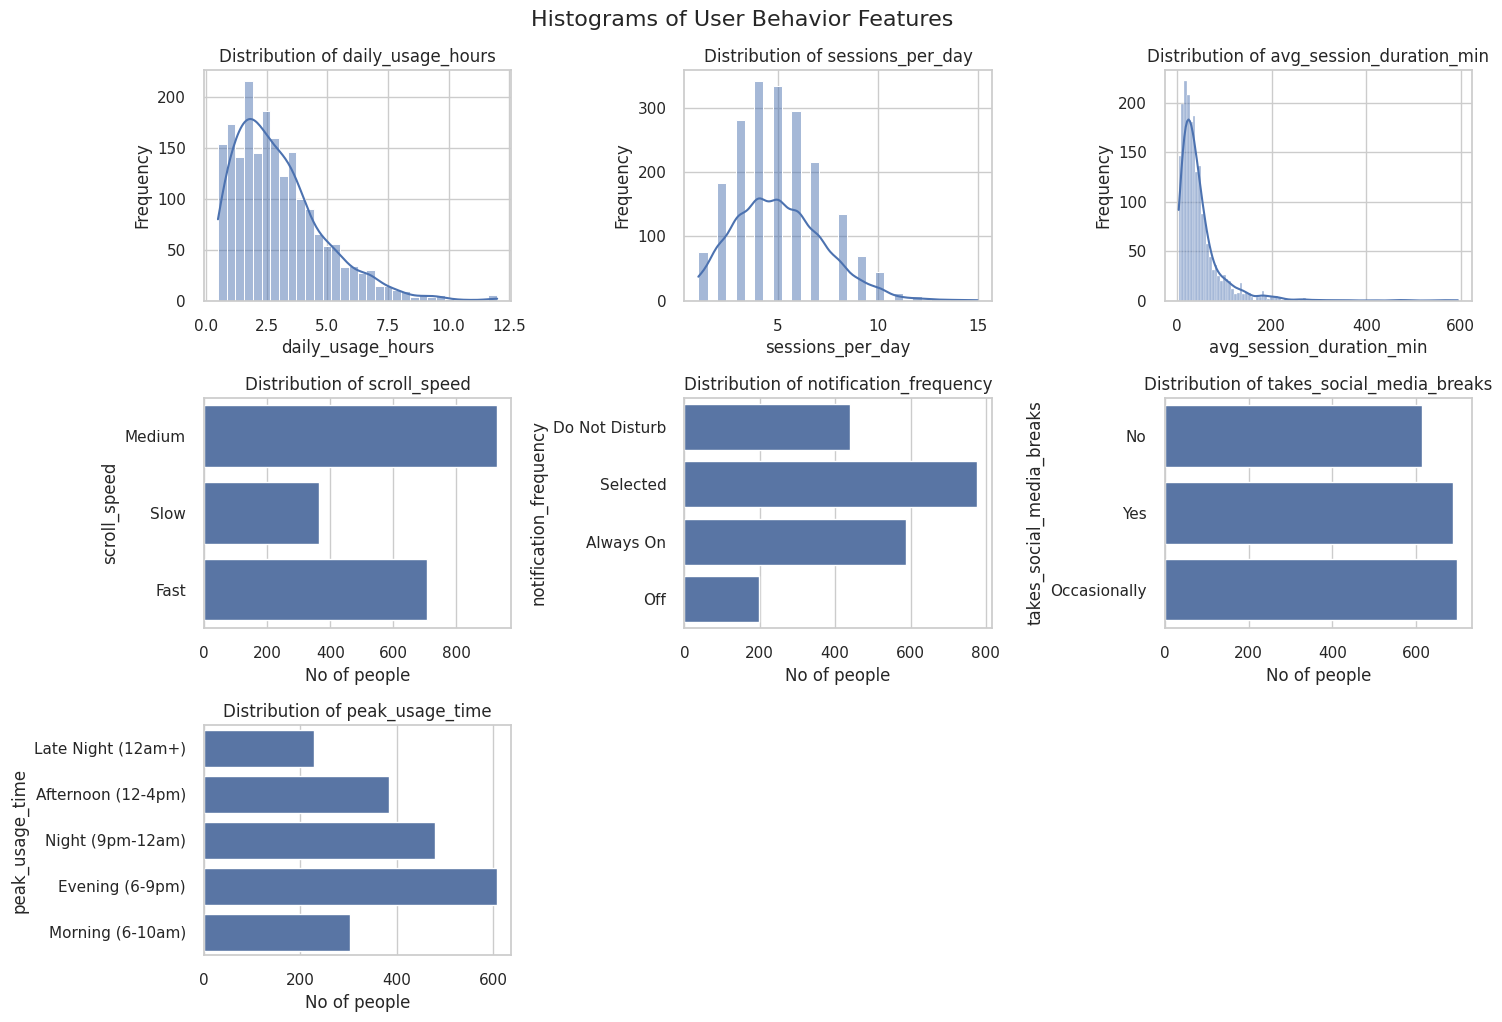

In [ ]:
plt.figure(figsize=(15, 10))
num_features = len(User_Behavior_features)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(User_Behavior_features):
    plt.subplot(num_rows, num_cols, i + 1)
    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature}')
        plt.xlabel('No of people')
        plt.ylabel(feature)
    else: # Handle numerical features
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of User Behavior Features', y=1.02, fontsize=16)
plt.show()

#### Fnding the Optimal K (Elbow Method) And Apllying the K means and PCA

In [ ]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia

[25417.750785657267,
 23243.671985678888,
 21085.432471121003,
 19705.694476426965,
 18643.7721060064,
 17300.741904028833,
 16268.302410445016,
 15504.47663907073,
 15101.002842210457]

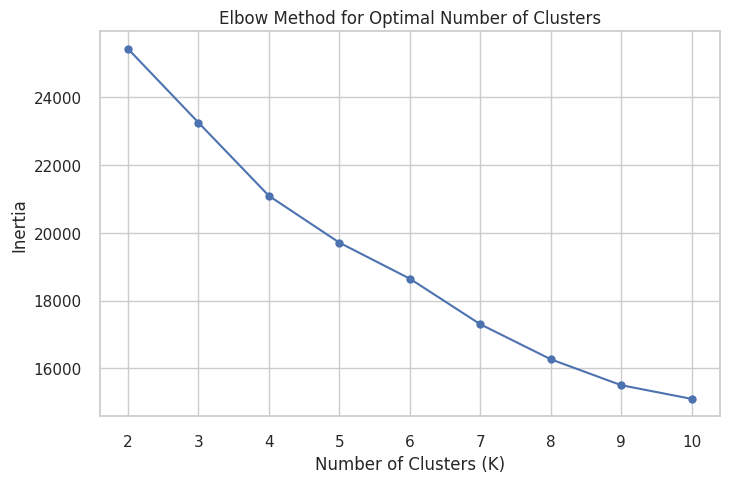

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans_model = apply_kmeans(k=4,cluster_name='Kmeans_cluster', x_scaled=X_scaled)

Kmeans_cluster
1    990
0    479
2    303
3    228
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'User_Behavior_Clusters'
pca_df = apply_PCA(X_scaled, df_cleaned, 'Kmeans_cluster', output_cluster_col_name='User_Behavior_Clusters')

In [ ]:
import plotly.express as px
# Call the function to visualize the PCA results
apply_PCA_visualization(pca_df, 'User_Behavior_Clusters')

#### Cluster Profiling on User_Behavior_Clusters

In [ ]:
# Identify numerical features within User_Behavior_features
numerical_behavior_features = [f for f in User_Behavior_features if f in df_cleaned.select_dtypes(include=['number']).columns]
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster')[numerical_behavior_features].mean()
display(cluster_summary_numerical)

,daily_usage_hours,sessions_per_day,avg_session_duration_min
Kmeans_cluster,,,
0,2.981837,5.181628,43.383507
1,2.980404,4.976768,48.508788
2,3.053465,4.874587,52.247525
3,2.970175,5.100877,45.874561


In [ ]:
# Identify categorical features within User_Behavior_features
categorical_behavior_features = [f for f in User_Behavior_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in categorical_behavior_features:
    print(f"\nMost frequent '{feature}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'scroll_speed' by KMeans Cluster:


,scroll_speed
Kmeans_cluster,
0,Medium
1,Medium
2,Medium
3,Medium



Most frequent 'notification_frequency' by KMeans Cluster:


,notification_frequency
Kmeans_cluster,
0,Always On
1,Selected
2,Selected
3,Selected



Most frequent 'takes_social_media_breaks' by KMeans Cluster:


,takes_social_media_breaks
Kmeans_cluster,
0,Occasionally
1,Occasionally
2,Yes
3,Yes



Most frequent 'peak_usage_time' by KMeans Cluster:


,peak_usage_time
Kmeans_cluster,
0,Night (9pm-12am)
1,Evening (6-9pm)
2,Morning (6-10am)
3,Late Night (12am+)


In [ ]:
# Percentage crosstab of features
for feature in User_Behavior_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


daily_usage_hours


daily_usage_hours,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,...,9.2,9.4,9.5,9.6,9.7,9.9,10.0,10.5,11.1,12.0
Kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,4.0,1.0,3.0,1.0,2.0,2.0,3.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,1.0,1.0,1.0,2.0,2.0,3.0,3.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.0,0.0,1.0,2.0,2.0,3.0,2.0,3.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



sessions_per_day


sessions_per_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Kmeans_cluster,,,,,,,,,,,,,,,
0,3.0,8.0,11.0,18.0,17.0,18.0,12.0,8.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0
1,4.0,9.0,15.0,17.0,17.0,14.0,10.0,6.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0
2,4.0,13.0,16.0,16.0,14.0,15.0,10.0,6.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0
3,3.0,8.0,14.0,16.0,20.0,12.0,11.0,10.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0



avg_session_duration_min


...

notification_frequency,Always On,Do Not Disturb,Off,Selected
Kmeans_cluster,,,,
0,35.0,21.0,9.0,35.0
1,26.0,23.0,10.0,41.0
2,27.0,22.0,11.0,41.0
3,33.0,21.0,8.0,37.0



takes_social_media_breaks


takes_social_media_breaks,No,Occasionally,Yes
Kmeans_cluster,,,
0,32.0,36.0,32.0
1,31.0,35.0,34.0
2,29.0,34.0,37.0
3,29.0,34.0,38.0



peak_usage_time


peak_usage_time,Afternoon (12-4pm),Evening (6-9pm),Late Night (12am+),Morning (6-10am),Night (9pm-12am)
Kmeans_cluster,,,,,
0,0.0,0.0,0.0,0.0,100.0
1,39.0,61.0,0.0,0.0,0.0
2,0.0,0.0,0.0,100.0,0.0
3,0.0,0.0,100.0,0.0,0.0


#### **Cluster Maping accourding to profiling**

In [ ]:
engaement_cluster_name = {
    0: "Night Time Active Users",
    1: "Evening-AfterNoon Users",
    2: "Morning Browesers ",
    3: "late-Night Browsers"
}
df_cleaned['User_behaviour_Clusters_names'] = df_cleaned['Kmeans_cluster'].map(engaement_cluster_name)
print(df_cleaned['User_behaviour_Clusters_names'].value_counts())

User_behaviour_Clusters_names
Evening-AfterNoon Users    990
Night Time Active Users    479
Morning Browesers          303
late-Night Browsers        228
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'User_Behavior_Clusters'
pca_df = apply_PCA(X_scaled, df_cleaned, 'User_behaviour_Clusters_names', output_cluster_col_name='User_Behavior_Clusters')

In [ ]:
apply_PCA_visualization(pca_df, 'User_Behavior_Clusters')

In [ ]:
pd.crosstab(df_cleaned['User_behaviour_Clusters_names'], df_cleaned['peak_usage_time'])

peak_usage_time,Afternoon (12-4pm),Evening (6-9pm),Late Night (12am+),Morning (6-10am),Night (9pm-12am)
User_behaviour_Clusters_names,,,,,
Evening-AfterNoon Users,383,607,0,0,0
Morning Browesers,0,0,0,303,0
Night Time Active Users,0,0,0,0,479
late-Night Browsers,0,0,228,0,0


In [ ]:
pd.crosstab(df_cleaned['User_behaviour_Clusters_names'], df_cleaned['age'])

age,13,14,15,16,17,18,19,20,21,22,...,42,43,44,45,46,47,48,51,52,57
User_behaviour_Clusters_names,,,,,,,,,,,,,,,,,,,,,
Evening-AfterNoon Users,46,22,10,13,22,29,34,36,37,44,...,7,7,5,0,4,2,0,0,1,0
Morning Browesers,11,5,9,3,9,6,8,9,10,14,...,3,3,1,3,0,2,1,1,0,0
Night Time Active Users,16,6,12,11,9,17,12,18,19,27,...,4,5,6,2,1,1,1,0,0,0
late-Night Browsers,10,2,5,6,3,4,8,8,11,10,...,0,0,1,1,1,2,1,0,1,1


 **Daily Usage Hours** in User_behaviour_Clusters

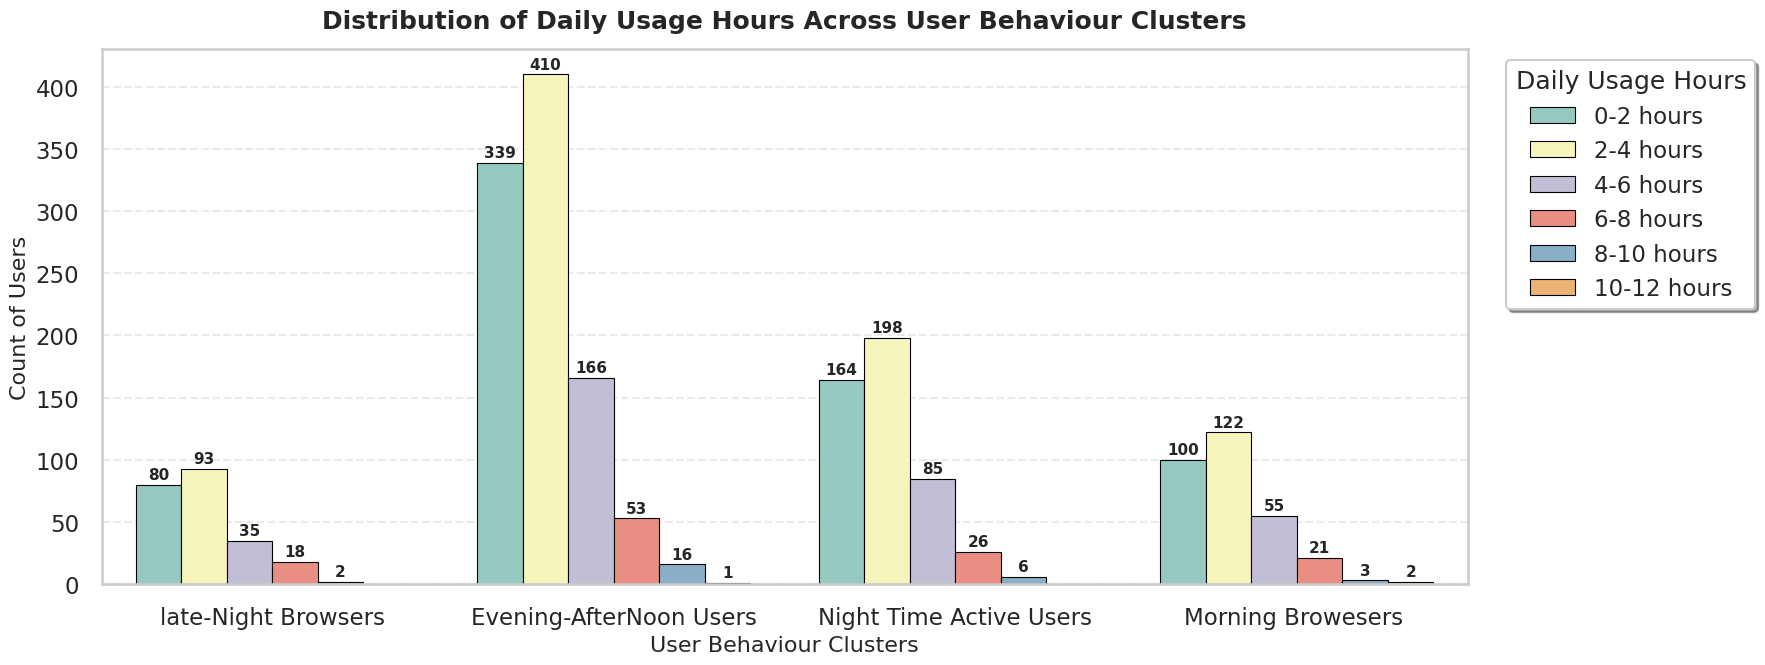

In [ ]:
max_usage = df_cleaned['daily_usage_hours'].max()
bins = np.arange(0, max_usage + 2, 2)

labels = [f'{int(b)}-{int(b+2)} hours' for b in bins[:-1]]

# Create temporary bins for plotting
df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['daily_usage_hours'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Enhanced plot styling
sb.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(18, 7))

ax = sb.countplot(
    data=df_cleaned,
    x='User_behaviour_Clusters_names',
    hue='duration_bin',
    palette='Set3',
    edgecolor='black',
    linewidth=0.8
)

# Titles and labels
ax.set_title(
    'Distribution of Daily Usage Hours Across User Behaviour Clusters',
    fontsize=18,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('User Behaviour Clusters', fontsize=16)
ax.set_ylabel('Count of Users', fontsize=16,)

# Add count labels to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight='bold',
        padding=2
    )

# Improve legend
plt.legend(
    title='Daily Usage Hours',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    shadow=True
)

# Grid customization
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Drop temporary column
df_cleaned.drop(columns=['duration_bin'], inplace=True)

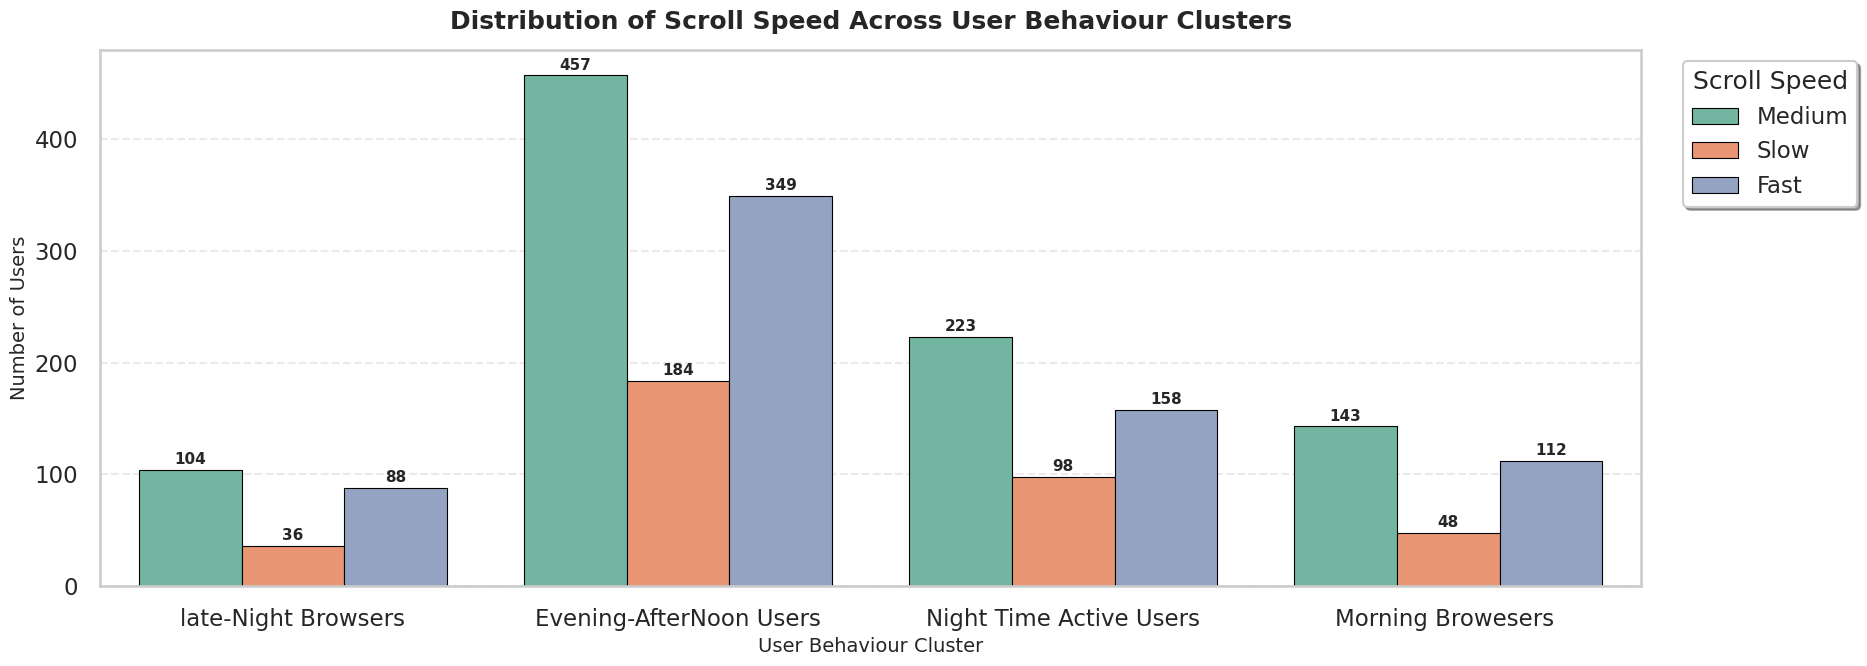

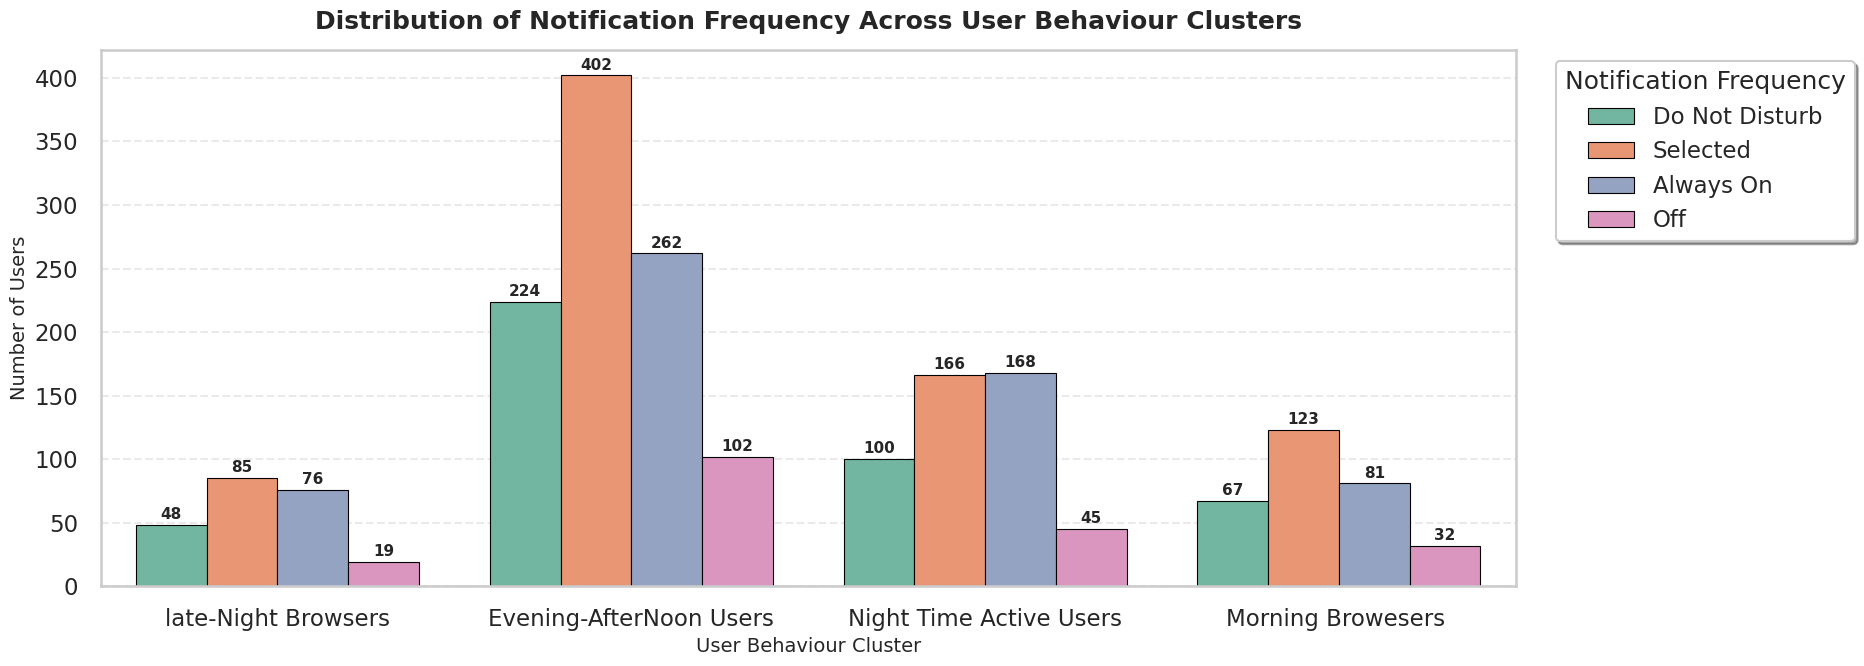

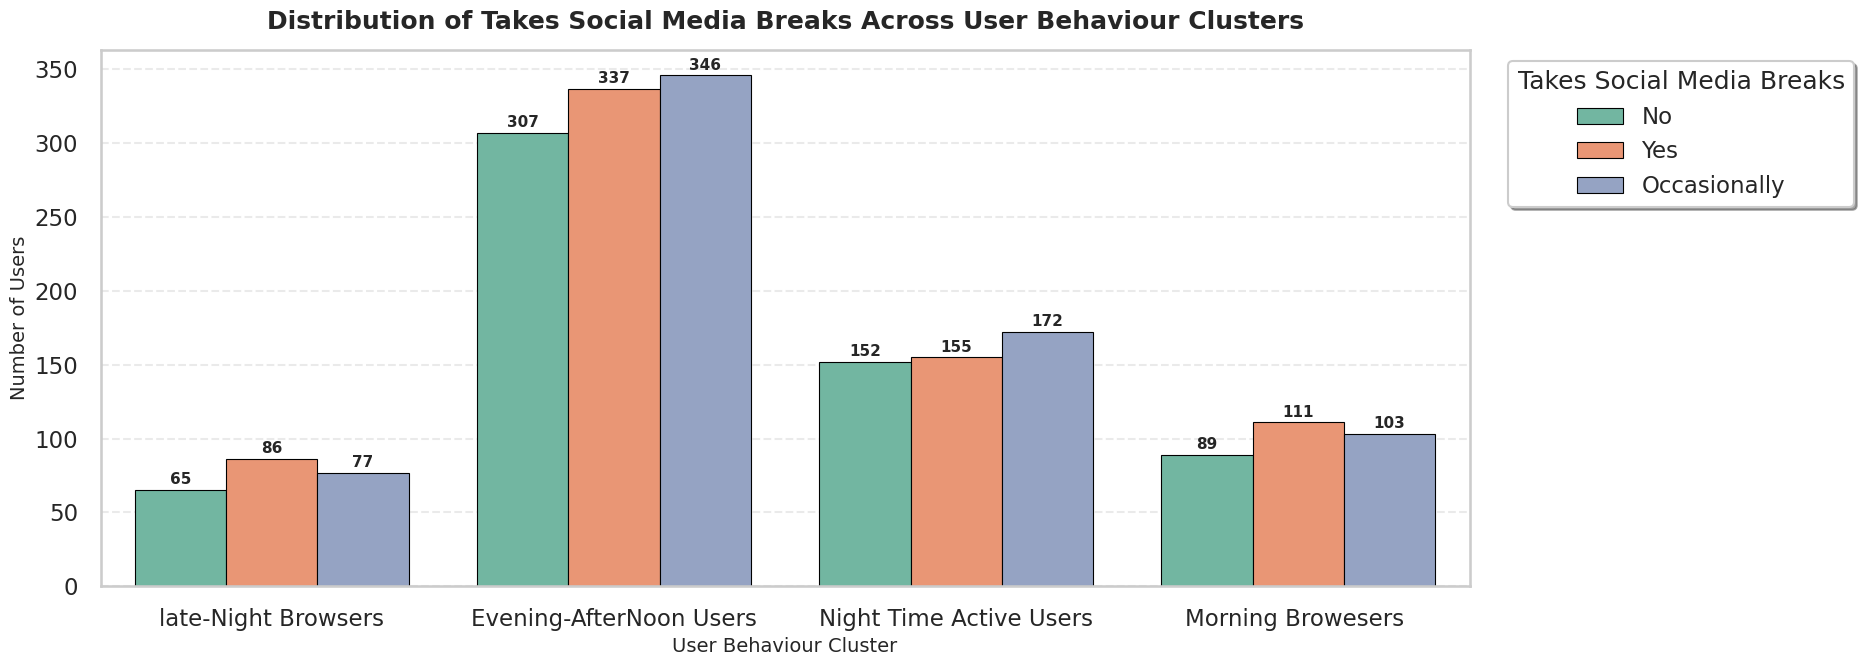

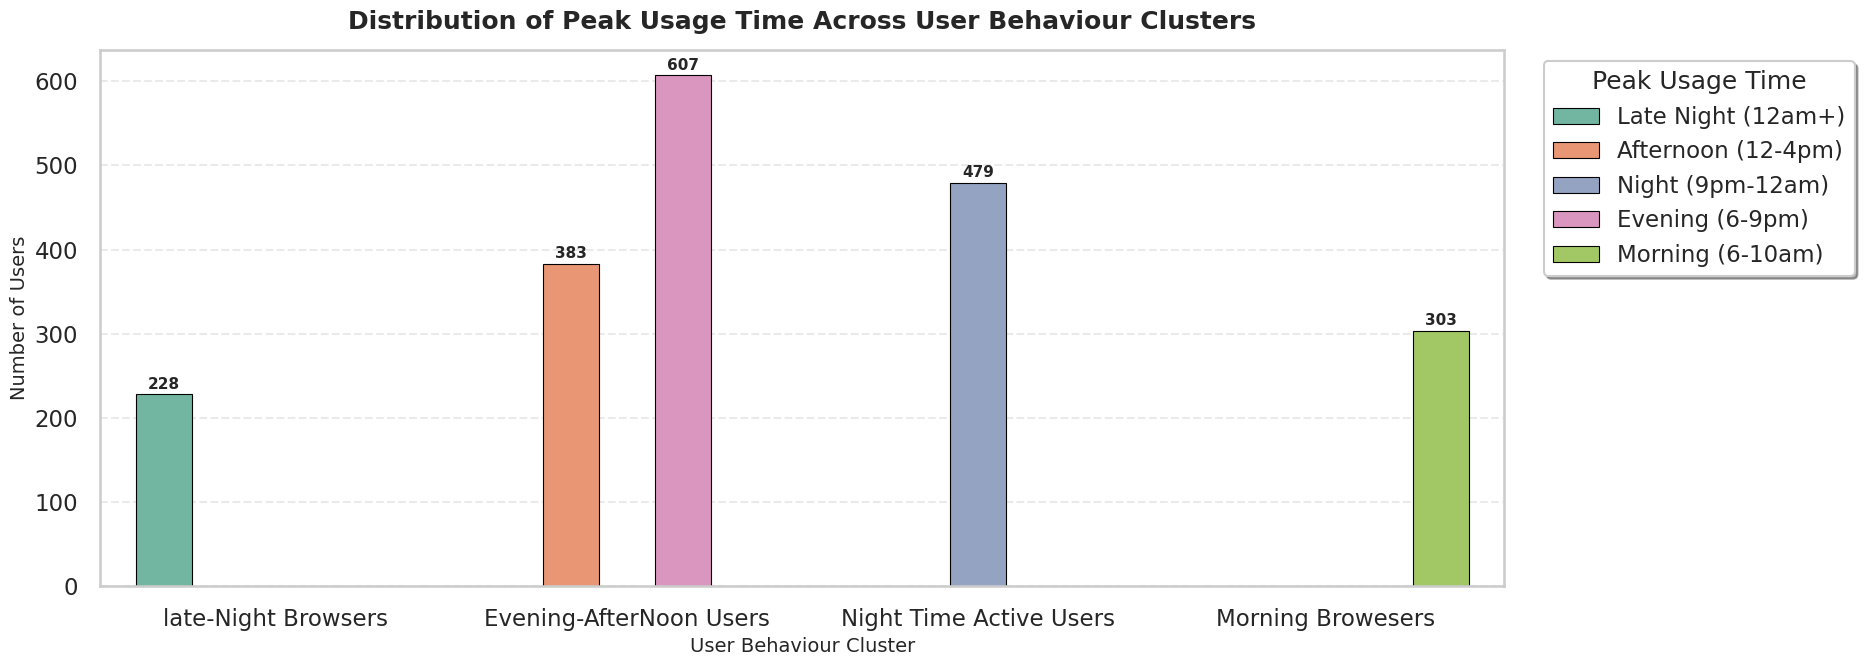

In [ ]:

# Set theme once
sb.set_theme(style="whitegrid", context="talk")

for f in categorical_behavior_features:

    plt.figure(figsize=(19, 7))

    ax = sb.countplot(
        data=df_cleaned,
        x='User_behaviour_Clusters_names',
        hue=f,
        palette='Set2',
        edgecolor='black',
        linewidth=0.8
    )

    # Title and labels
    ax.set_title(
        f'Distribution of {f.replace("_", " ").title()} Across User Behaviour Clusters',
        fontsize=18,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel('User Behaviour Cluster', fontsize=14)
    ax.set_ylabel('Number of Users', fontsize=14)

    # Add count labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=11,
            fontweight='bold',
            padding=2
        )

    # Customize legend
    plt.legend(
        title=f.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=True,
        shadow=True
    )

    # Grid styling
    ax.grid(axis='y', linestyle='--', alpha=0.4)



    plt.tight_layout()
    plt.show()

**Session Per day** in User_behaviour_Clusters

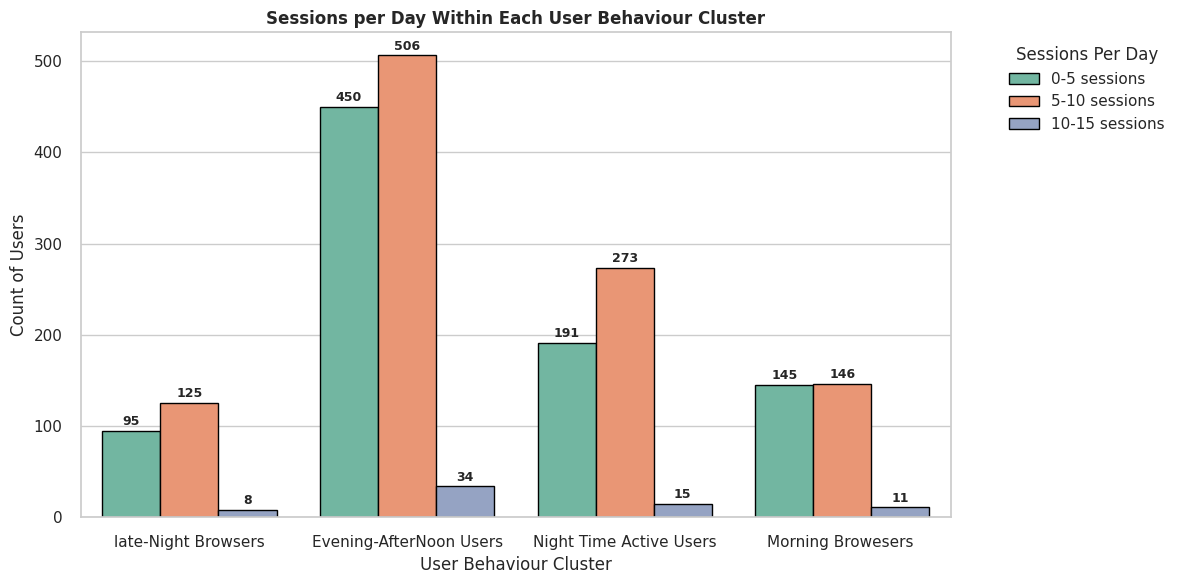

In [ ]:
max_usage = df_cleaned['sessions_per_day'].max()
bins = np.arange(0, max_usage + 5, 5)

labels = [f'{int(b)}-{int(b+5)} sessions' for b in bins[:-1]]

# Create temporary bins for plotting
df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['sessions_per_day'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

sb.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sb.countplot(
    data=df_cleaned,
    x='User_behaviour_Clusters_names',
    hue='duration_bin',
    palette='Set2',
    edgecolor='black'
)

plt.title('Sessions per Day Within Each User Behaviour Cluster', fontweight='bold')
plt.xlabel('User Behaviour Cluster')
plt.ylabel('Count of Users')

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold', padding=2)

plt.legend(
    title='Sessions Per Day',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Drop temporary column
df_cleaned.drop(columns=['duration_bin'], inplace=True)

#### DBSCAN Clustering - User Behaviour

In [ ]:
# Example for User Behavior features (X_scaled)
dbscan = DBSCAN(eps=3, min_samples=6) # Tune these parameters
df_cleaned['DBSCAN_User_Behavior_Cluster'] = dbscan.fit_predict(X_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_User_Behavior_Cluster'].value_counts())

DBSCAN_User_Behavior_Cluster
 1    1578
 0     209
 2     177
-1      23
 3      13
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_User_Behavior_Cluster']
mask = d_labels != -1

sil_d = silhouette_score(X_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.17
KMeans Davies-Bouldin Index: 2.13

DBSCAN Silhouette Score: 0.15
DBSCAN Davies-Bouldin Index: 1.77


In [ ]:
pd.crosstab(df_cleaned['DBSCAN_User_Behavior_Cluster'], df_cleaned['scroll_speed'])

scroll_speed,Fast,Medium,Slow
DBSCAN_User_Behavior_Cluster,,,
-1,4,10,9
0,83,94,32
1,555,731,292
2,60,84,33
3,5,8,0


In [ ]:
engagement_profile = (
    df_cleaned
    .groupby('DBSCAN_User_Behavior_Cluster')[User_Behavior_features]
    .mean(numeric_only=True)
    .round(2)
)
print(engagement_profile)

                              daily_usage_hours  sessions_per_day  \
DBSCAN_User_Behavior_Cluster                                        
-1                                         6.43              3.17   
 0                                         2.91              5.09   
 1                                         2.94              5.06   
 2                                         3.04              4.87   
 3                                         3.68              5.08   

                              avg_session_duration_min  
DBSCAN_User_Behavior_Cluster                            
-1                                              275.36  
 0                                               45.13  
 1                                               44.59  
 2                                               47.23  
 3                                               46.22  


In [ ]:
# Percentage crosstab of features
for feature in User_Behavior_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_User_Behavior_Cluster'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


daily_usage_hours


daily_usage_hours,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,...,9.2,9.4,9.5,9.6,9.7,9.9,10.0,10.5,11.1,12.0
DBSCAN_User_Behavior_Cluster,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,4.0
0,2.0,0.0,1.0,2.0,2.0,3.0,2.0,3.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,1.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,2.0,2.0,4.0,1.0,3.0,1.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



sessions_per_day


sessions_per_day,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
DBSCAN_User_Behavior_Cluster,,,,,,,,,,,,,,,
-1,61.0,9.0,4.0,4.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0
0,3.0,9.0,15.0,15.0,20.0,12.0,11.0,10.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
1,3.0,9.0,14.0,17.0,16.0,15.0,11.0,6.0,4.0,2.0,1.0,0.0,0.0,0.0,0.0
2,3.0,11.0,14.0,19.0,18.0,14.0,9.0,7.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,8.0,31.0,31.0,15.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



avg_session_duration_min


...

notification_frequency,Always On,Do Not Disturb,Off,Selected
DBSCAN_User_Behavior_Cluster,,,,
-1,4.0,17.0,35.0,43.0
0,36.0,23.0,0.0,41.0
1,32.0,25.0,0.0,43.0
2,0.0,0.0,100.0,0.0
3,0.0,0.0,100.0,0.0



takes_social_media_breaks


takes_social_media_breaks,No,Occasionally,Yes
DBSCAN_User_Behavior_Cluster,,,
-1,30.0,39.0,30.0
0,28.0,33.0,38.0
1,31.0,35.0,34.0
2,31.0,35.0,34.0
3,15.0,46.0,38.0



peak_usage_time


peak_usage_time,Afternoon (12-4pm),Evening (6-9pm),Late Night (12am+),Morning (6-10am),Night (9pm-12am)
DBSCAN_User_Behavior_Cluster,,,,,
-1,13.0,35.0,26.0,22.0,4.0
0,0.0,0.0,100.0,0.0,0.0
1,22.0,34.0,0.0,17.0,27.0
2,20.0,37.0,0.0,18.0,25.0
3,0.0,0.0,100.0,0.0,0.0


In [ ]:
dbscan_user_behavior_cluster_names = {
   -1: "Long-Session Explorers",
    0: "Moderate Daily Engagers",
    1: "Core Regular Users",
    2: "Average Session Users",
    3: "Above-Average Daily Users"
}

df_cleaned['DBSCAN_User_Behavior_Cluster_Names'] = df_cleaned['DBSCAN_User_Behavior_Cluster'].map(dbscan_user_behavior_cluster_names)
print(df_cleaned['DBSCAN_User_Behavior_Cluster_Names'].value_counts())


DBSCAN_User_Behavior_Cluster_Names
Core Regular Users           1578
Moderate Daily Engagers       209
Average Session Users         177
Long-Session Explorers         23
Above-Average Daily Users      13
Name: count, dtype: int64


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

###  Engagement Clustering

In [ ]:
Engagement_features = np.array([
    'posts_per_week',
    'likes_given_per_day',
    'comments_per_day',
    'shares_per_day',
    'ad_click_rate',
    'preferred_content_type',
    'mood_while_scrolling'
])

x_engagement = df_cleaned[Engagement_features]

#### encoding and scaling of Engagemment features

In [ ]:
x_engagement = pd.get_dummies(x_engagement, drop_first=True)
X_scaled_engagement = StandardScaler().fit_transform(x_engagement)

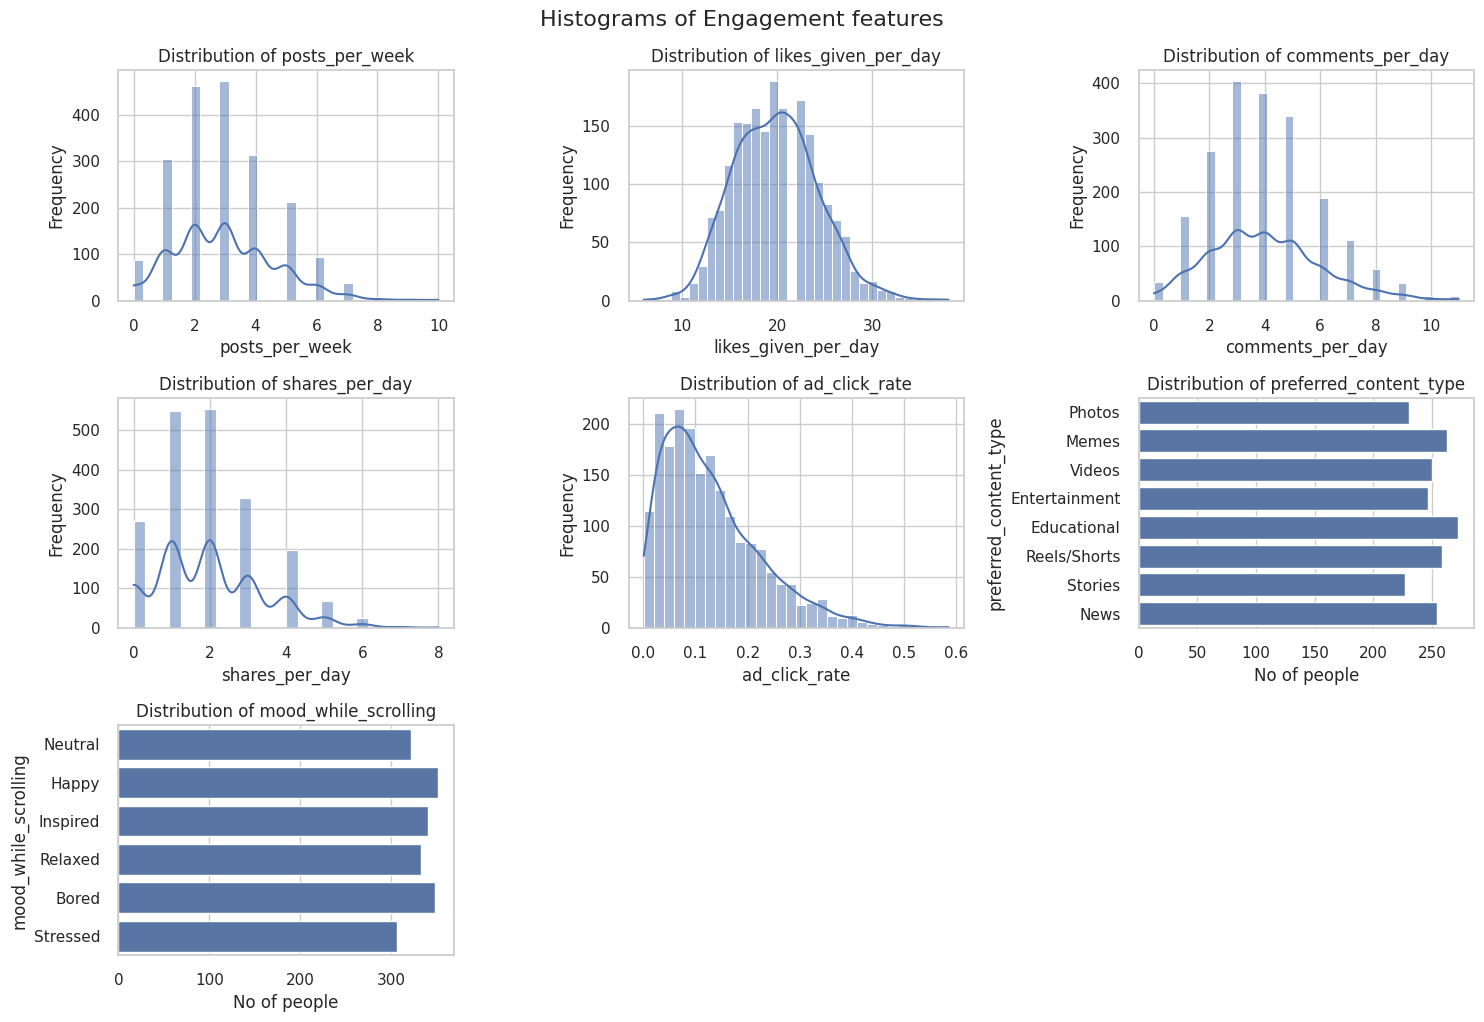

In [ ]:
objects_engagement = []

plt.figure(figsize=(15, 10))
num_features = len(Engagement_features)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(Engagement_features):

    plt.subplot(num_rows, num_cols, i + 1)
    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        objects_engagement.append(feature)
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature}')
        plt.xlabel('No of people')
        plt.ylabel(feature)
    else: # Handle numerical features
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of Engagement features', y=1.02, fontsize=16)
plt.show()

#### Elbow Method and silhouette score

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=0,
        n_init=10
    )

    kmeans.fit(X_scaled_engagement)
    inertia.append(kmeans.inertia_)

inertia

[31795.717401389225,
 29393.86474318622,
 27190.80469337244,
 25133.771840956942,
 23042.926243245227,
 21111.850290872557,
 20564.211729192863,
 19470.42165321205,
 19116.858383070652]

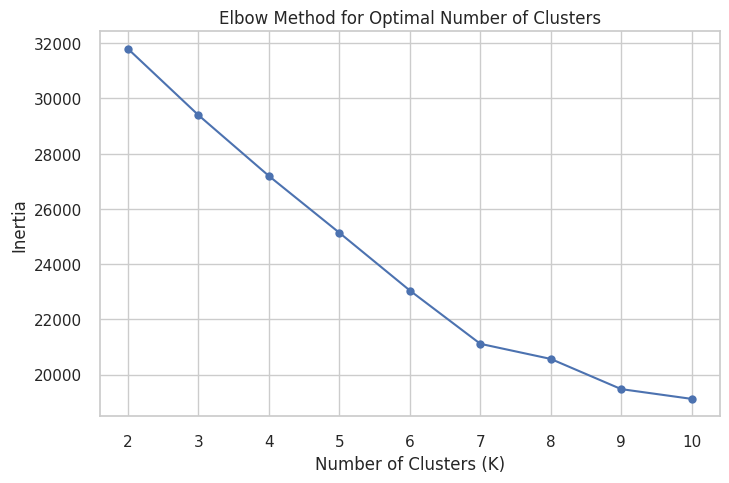

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

**K-Means Clutsering**

In [ ]:
kmeans_model = apply_kmeans(k=5,cluster_name='Kmeans_cluster_Engagement', x_scaled=X_scaled_engagement)
sl= silhouette_score(X_scaled_engagement, kmeans_model.labels_)

print(f"score{sl:.2f}")

Kmeans_cluster_Engagement
2    1007
1     263
0     254
4     246
3     230
Name: count, dtype: int64
score0.17


In [ ]:
pca_df_engagement = apply_PCA(X_scaled_engagement, df_cleaned, 'Kmeans_cluster_Engagement', output_cluster_col_name='Engagement_Clusters')

In [ ]:
apply_PCA_visulaization(pca_df_engagement, 'Engagement_Clusters')

NameError: name 'apply_PCA_visulaization' is not defined

#### Cluster Profiling: Engagement Clustering

In [ ]:
# Identify numerical features within Engagement Clustering
numerical_engagement_features = [f for f in Engagement_features if f in df_cleaned.select_dtypes(include=['number']).columns]
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster_Engagement')[numerical_engagement_features].mean()
display(cluster_summary_numerical)


,posts_per_week,likes_given_per_day,comments_per_day,shares_per_day,ad_click_rate
Kmeans_cluster_Engagement,,,,,
0,2.988189,20.200787,4.090551,1.897638,0.129079
1,3.015209,20.030418,3.897338,1.832700,0.123205
2,2.930487,19.815293,4.071500,1.988083,0.131443
3,3.108696,19.826087,3.908696,2.143478,0.125017
4,2.886179,19.727642,3.739837,2.105691,0.137354


In [ ]:
# Identify categorical features within User_Behavior_features
categorical_engagement_features = [f for f in Engagement_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in categorical_engagement_features:
    print(f"\nMost frequent '{feature}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster_Engagement')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'preferred_content_type' by KMeans Cluster:


,preferred_content_type
Kmeans_cluster_Engagement,
0,News
1,Memes
2,Educational
3,Photos
4,Entertainment



Most frequent 'mood_while_scrolling' by KMeans Cluster:


,mood_while_scrolling
Kmeans_cluster_Engagement,
0,Happy
1,Inspired
2,Bored
3,Relaxed
4,Neutral


In [ ]:
# Percentage crosstab of features
for feature in Engagement_features :
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster_Engagement'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


posts_per_week


posts_per_week,0,1,2,3,4,5,6,7,8,9,10
Kmeans_cluster_Engagement,,,,,,,,,,,
0,5.0,14.0,21.0,24.0,17.0,11.0,4.0,2.0,0.0,0.0,0.0
1,4.0,13.0,21.0,29.0,18.0,10.0,3.0,2.0,0.0,0.0,0.0
2,4.0,16.0,24.0,23.0,15.0,10.0,5.0,2.0,0.0,0.0,0.0
3,4.0,14.0,24.0,21.0,16.0,13.0,4.0,3.0,1.0,0.0,0.0
4,5.0,17.0,24.0,23.0,14.0,9.0,6.0,1.0,0.0,0.0,0.0



likes_given_per_day


likes_given_per_day,6,7,8,9,10,11,12,13,14,15,...,29,30,31,32,33,34,35,36,37,38
Kmeans_cluster_Engagement,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,3.0,...,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,3.0,7.0,...,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,7.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,1.0,1.0,4.0,4.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,4.0,5.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0



comments_per_day


...

ad_click_rate,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.479,0.487,0.492,0.495,0.501,0.513,0.515,0.534,0.579,0.585
Kmeans_cluster_Engagement,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



preferred_content_type


preferred_content_type,Educational,Entertainment,Memes,News,Photos,Reels/Shorts,Stories,Videos
Kmeans_cluster_Engagement,,,,,,,,
0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
1,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
2,27.0,0.0,0.0,0.0,0.0,26.0,23.0,25.0
3,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
4,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0



mood_while_scrolling


mood_while_scrolling,Bored,Happy,Inspired,Neutral,Relaxed,Stressed
Kmeans_cluster_Engagement,,,,,,
0,17.0,21.0,18.0,13.0,17.0,15.0
1,17.0,17.0,19.0,16.0,16.0,14.0
2,18.0,18.0,16.0,17.0,17.0,15.0
3,15.0,14.0,17.0,14.0,20.0,20.0
4,18.0,17.0,17.0,19.0,15.0,15.0


**Cluster Maping accourding to profiling**

In [ ]:
engaement_cluster_name = {
    0: "Educational Engagers",
    1: "Caual Learners",
    2: "Happy Meme Viewers",
    3: "Inspired Social Interactors",
    4: "Enterainment Enthusiasts"
}

df_cleaned['Engagement_Clusters_segament'] = df_cleaned['Kmeans_cluster_Engagement'].map(engaement_cluster_name)

print(df_cleaned['Engagement_Clusters_segament'].value_counts())

Engagement_Clusters_segament
Happy Meme Viewers             1007
Caual Learners                  263
Educational Engagers            254
Enterainment Enthusiasts        246
Inspired Social Interactors     230
Name: count, dtype: int64


In [ ]:
pca_df_engagement = apply_PCA(X_scaled_engagement, df_cleaned, 'Engagement_Clusters_segament', output_cluster_col_name='Engagement_Clusters')

In [ ]:
apply_PCA_visualization(pca_df_engagement, 'Engagement_Clusters')

#### sessions_per_day in Engagement Clustering

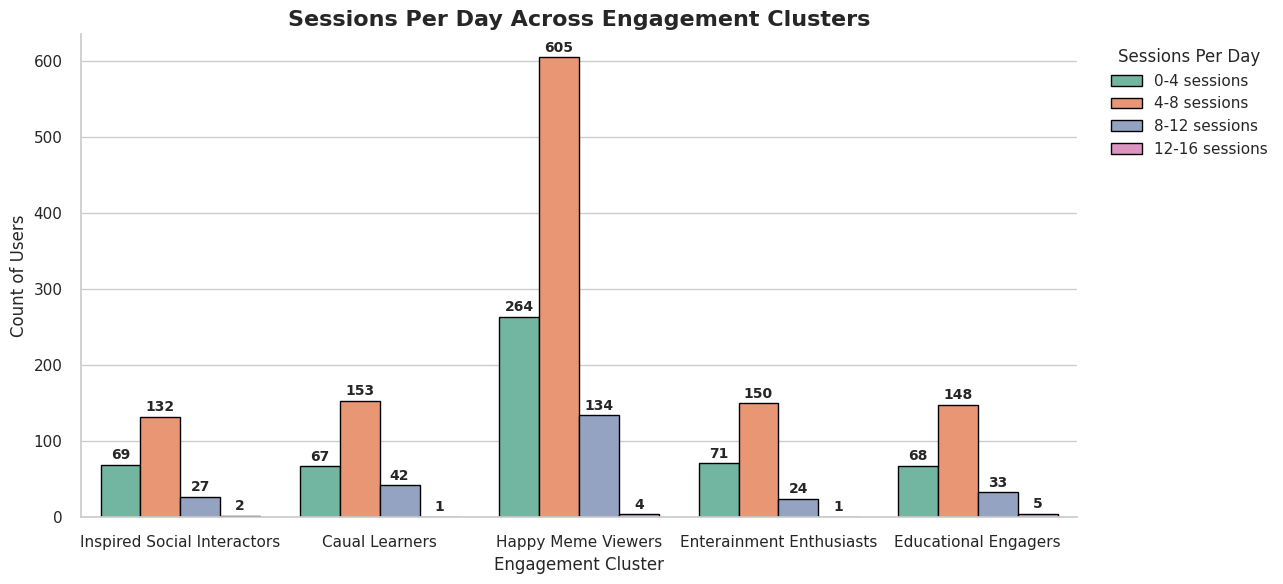

In [ ]:
max_usage = df_cleaned['sessions_per_day'].max()
bins = np.arange(0, max_usage + 4, 4)

labels = [f'{int(b)}-{int(b+4)} sessions' for b in bins[:-1]]

df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['sessions_per_day'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

sb.set_theme(style="whitegrid")

plt.figure(figsize=(13, 6))

ax = sb.countplot(
    data=df_cleaned,
    x='Engagement_Clusters_segament',
    hue='duration_bin',
    palette='Set2',
    edgecolor='black'
)

plt.title(
    'Sessions Per Day Across Engagement Clusters',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Engagement Cluster')
plt.ylabel('Count of Users')

# Add counts on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=2)

plt.legend(
    title='Sessions Per Day',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sb.despine()
plt.tight_layout()
plt.show()

df_cleaned.drop(columns=['duration_bin'], inplace=True)

In [ ]:

sb.set_theme(style="whitegrid")

for f in objects_engagement:

    plt.figure(figsize=(16, 6))

    ax = sb.countplot(
        data=df_cleaned,
        x='Engagement_Clusters_segament',
        hue=f,
        palette='Set3',
        edgecolor='grey'
    )

    plt.title(
        f'Distribution of {f.replace("_", " ").title()} Across Engagement Clusters',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Engagement Cluster')
    plt.ylabel('Number of Users')

    # Add counts on bars
    for container in ax.containers:
        ax.bar_label(container, fontsize=8, fontweight= 'bold', padding= 2)

    plt.legend(
        title=f.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    sb.despine()
    plt.tight_layout()
    plt.show()

#### DBSCAN CLustering

In [ ]:
# Example for Engagemnet features (X_scaled_engagement)
dbscan = DBSCAN(eps=3, min_samples=5) # Tune these parameters
df_cleaned['DBSCAN_cluster_Engagement'] = dbscan.fit_predict(X_scaled_engagement)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_Engagement'].value_counts())

DBSCAN_cluster_Engagement
 1    788
 5    253
 2    249
 3    244
 0    228
 4    225
-1     13
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_scaled_engagement, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_scaled_engagement, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_Engagement']
mask = d_labels != -1

sil_d = silhouette_score(X_scaled_engagement[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_scaled_engagement[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.17
KMeans Davies-Bouldin Index: 2.11

DBSCAN Silhouette Score: 0.20
DBSCAN Davies-Bouldin Index: 2.01


In [ ]:
# Percentage crosstab of features
for feature in Engagement_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_Engagement'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


posts_per_week


posts_per_week,0,1,2,3,4,5,6,7,8,9,10
DBSCAN_cluster_Engagement,,,,,,,,,,,
-1,8.0,15.0,8.0,15.0,8.0,0.0,8.0,0.0,8.0,15.0,15.0
0,4.0,14.0,24.0,21.0,16.0,13.0,4.0,3.0,1.0,0.0,0.0
1,4.0,16.0,22.0,24.0,15.0,11.0,4.0,2.0,0.0,0.0,0.0
2,2.0,14.0,29.0,25.0,14.0,10.0,4.0,1.0,0.0,0.0,0.0
3,5.0,17.0,24.0,23.0,14.0,9.0,6.0,1.0,0.0,0.0,0.0
4,6.0,15.0,20.0,23.0,19.0,8.0,6.0,1.0,1.0,0.0,0.0
5,5.0,14.0,21.0,24.0,17.0,11.0,4.0,2.0,0.0,0.0,0.0



likes_given_per_day


likes_given_per_day,6,7,8,9,10,11,12,13,14,15,...,29,30,31,32,33,34,35,36,37,38
DBSCAN_cluster_Engagement,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,...,8.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,8.0
0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,4.0,4.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4.0,3.0,6.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,5.0,8.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,5.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,2.0,2.0,5.0,5.0,8.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,3.0,...,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0



comments_per_day


...

ad_click_rate,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.479,0.487,0.492,0.495,0.501,0.513,0.515,0.534,0.579,0.585
DBSCAN_cluster_Engagement,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,8.0,8.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



preferred_content_type


preferred_content_type,Educational,Entertainment,Memes,News,Photos,Reels/Shorts,Stories,Videos
DBSCAN_cluster_Engagement,,,,,,,,
-1,8.0,15.0,15.0,8.0,15.0,15.0,15.0,8.0
0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
1,34.0,0.0,33.0,0.0,0.0,32.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
3,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
5,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0



mood_while_scrolling


mood_while_scrolling,Bored,Happy,Inspired,Neutral,Relaxed,Stressed
DBSCAN_cluster_Engagement,,,,,,
-1,0.0,23.0,23.0,15.0,38.0,0.0
0,15.0,14.0,18.0,14.0,19.0,20.0
1,18.0,18.0,16.0,17.0,17.0,14.0
2,20.0,18.0,16.0,16.0,15.0,15.0
3,18.0,16.0,17.0,19.0,14.0,15.0
4,15.0,17.0,18.0,16.0,17.0,18.0
5,17.0,21.0,18.0,12.0,17.0,15.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Engagement_names = {
   -1: "Exploratory Users",
    0: "Visual Content",
    1: "Multi-Content Explorers",
    2: "Video Enthusiasts",
    3: "Entertainment Fans",
    4: "Story Learners",
    5: "News Followers"
}

df_cleaned['DBSCAN_Engagement_Names'] = df_cleaned['DBSCAN_cluster_Engagement'].map(dbscan_Engagement_names)
print(df_cleaned['DBSCAN_Engagement_Names'].value_counts())


DBSCAN_Engagement_Names
Multi-Content Explorers    788
News Followers             253
Video Enthusiasts          249
Entertainment Fans         244
Visual Content             228
Story Learners             225
Exploratory Users           13
Name: count, dtype: int64


In [ ]:
from plotly.subplots import make_subplots
import plotly.express as px

# Create a DataFrame for the scores
scores_data_engagement = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df_engagement = pd.DataFrame(scores_data_engagement)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison for Engagement', 'Davies-Bouldin Index Comparison for Engagement'))

# Create Silhouette Score bar chart
fig_sil_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil_engagement.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi_engagement.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics for Engagement Features",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

### Social Influence Clustering

In [ ]:
social_influence_features = np.array(
    [
        'followers_count',
        'following_count',
        'posts_per_week',
        'influencer_status',
        'primary_platform',
    ]
)

x_sociall_influence = df_cleaned[social_influence_features]

#### Scaling and and Encoding

In [ ]:
X_Social = pd.get_dummies(x_sociall_influence, drop_first=True) # Encoding
X_socail_influence_scaled = StandardScaler().fit_transform(X_Social) # Scaling

In [ ]:

# Pre-Visualization of data in segament before Clustering
objects_platform =[]

plt.figure(figsize=(15, 10))
num_features = len(social_influence_features)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(social_influence_features):
    plt.subplot(num_rows, num_cols, i + 1)
    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        objects_platform.append(feature)
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature}')
        plt.xlabel('No of people')
        plt.ylabel(feature)
    elif feature == 'followers_count':
        sb.histplot(np.log1p(df_cleaned[feature]), kde=True)
        plt.title(f'Distribution of log-transformed {feature}')
        plt.xlabel('log(1 + followers_count)')
        plt.ylabel('Frequency')
    else: # Handle numerical features
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of Social Influence features', y=1.02, fontsize=16)
plt.show()

#### Elbow Method And silhouette score


In [ ]:
inertia_social = []
silhouette_scores_social = []


K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=10,
        n_init=10
    )

    kmeans.fit(X_socail_influence_scaled)
    inertia_social.append(kmeans.inertia_)

    labels = kmeans.fit_predict(X_socail_influence_scaled)
    score = silhouette_score(X_socail_influence_scaled, labels)
    silhouette_scores_social.append(score)

print(f"Elbow Score {inertia_social}\n")
print("Silhouette Score: ")
for k, score in zip(K, silhouette_scores_social):
    print(f"K={k}: Silhouette Score = {score:.4f}")

Elbow Score [19592.10278899759, 17279.55854150437, 15146.244128942499, 13037.520948691628, 10983.988881473917, 8953.69088986326, 7024.821940495326, 5862.321535016611, 4926.9230116386825]

Silhouette Score: 
K=2: Silhouette Score = 0.1448
K=3: Silhouette Score = 0.2417
K=4: Silhouette Score = 0.3194
K=5: Silhouette Score = 0.3829
K=6: Silhouette Score = 0.4458
K=7: Silhouette Score = 0.4861
K=8: Silhouette Score = 0.4833
K=9: Silhouette Score = 0.5085
K=10: Silhouette Score = 0.5204


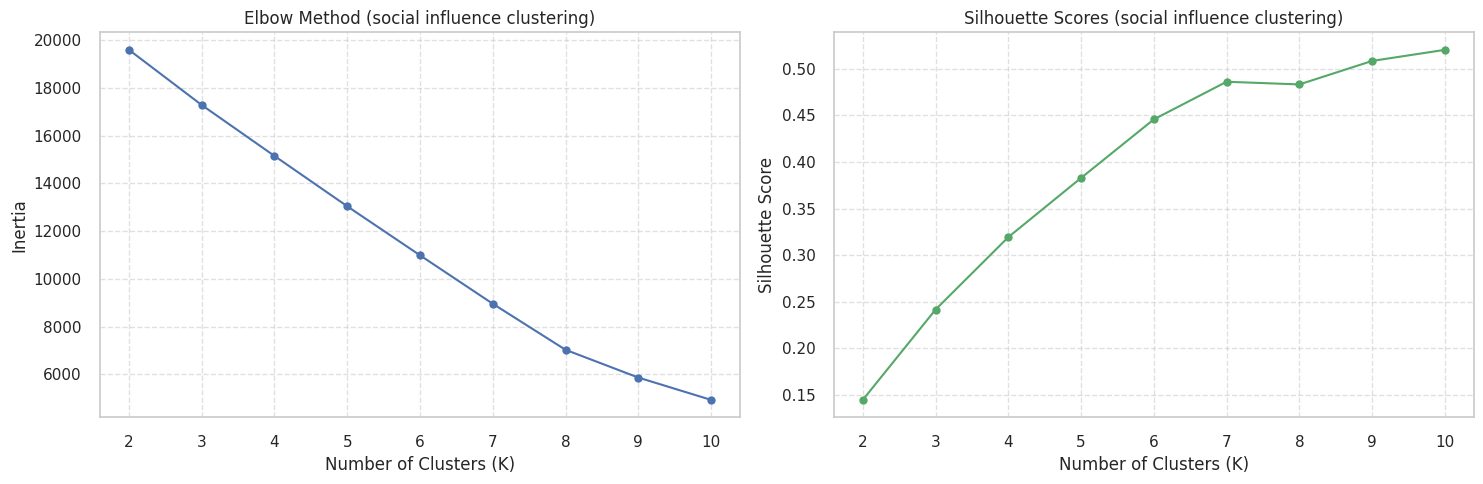

In [ ]:
plt.figure(figsize=(15, 5))
titile ='social influence clustering'
# Plotting Inertia (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(K, inertia_social, marker='o', color='b')
plt.title(f'Elbow Method ({titile.replace("_","  ")})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores_social, marker='o', color='g')
plt.title(f'Silhouette Scores ({titile.replace("_","  ")})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### **Kmeans and PCA**

With Elbow Method And silhouette score by k is 5



In [ ]:
# Applying the Kmeans
kmeans_model = apply_kmeans(k=5,cluster_name='Kmeans_cluster_social_influence', x_scaled=X_socail_influence_scaled)
sl = silhouette_score(X_socail_influence_scaled, kmeans_model.labels_)
print(f"Silhouette Score: {sl:.2f}")


Kmeans_cluster_social_influence
4    861
2    415
3    316
1    250
0    158
Name: count, dtype: int64
Silhouette Score: 0.38


In [ ]:
# Applying the PCA Method for Visulaization
df_pca_social_influence = apply_PCA(X_socail_influence_scaled, df_cleaned, 'Kmeans_cluster_social_influence', output_cluster_col_name='Social_Influence_Clusters')
df_pca_social_influence.head()

,PC1,PC2,Social_Influence_Clusters
0,0.017180,0.072748,4
1,-1.396091,-1.364222,2
2,1.335691,-0.690964,4
3,3.363819,-1.031562,4
4,-0.188465,0.553998,1


In [ ]:
# Cluster Visulization
apply_PCA_visualization(df_pca_social_influence, 'Social_Influence_Clusters')

#### Profiling the clusters

In [ ]:
# Identify numerical features within social_influence_features
numerical_social_influence_features = [f for f in social_influence_features if f in df_cleaned.select_dtypes(include=['number']).columns]
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster_social_influence')[numerical_social_influence_features].mean()
display(cluster_summary_numerical)

,followers_count,following_count,posts_per_week
Kmeans_cluster_social_influence,,,
0,3245.601266,791.645570,3.025316
1,3067.480000,416.188000,2.948000
2,2639.903614,542.727711,3.069880
3,2864.367089,581.221519,2.955696
4,5838.675958,452.929152,2.909408


In [ ]:
# Identify categorical features within social_influence_features
categorical_social__influence_features = [f for f in social_influence_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in categorical_social__influence_features:
    print(f"\nMost frequent '{feature}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster_social_influence')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'influencer_status' by KMeans Cluster:


,influencer_status
Kmeans_cluster_social_influence,
0,No
1,No
2,No
3,No
4,No



Most frequent 'primary_platform' by KMeans Cluster:


,primary_platform
Kmeans_cluster_social_influence,
0,Snapchat
1,YouTube
2,Instagram
3,Twitter/X
4,TikTok


In [ ]:
pd.crosstab(df_cleaned['Kmeans_cluster_social_influence'], df_cleaned['followers_count'])

followers_count,0,1,2,3,4,5,6,7,8,10,...,71352,78134,81406,85953,90336,93695,94448,117400,142022,2110323
Kmeans_cluster_social_influence,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,1,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,3,1,2,0,1,1,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,0,0,1,1,1,...,0,0,1,0,0,1,0,0,0,0
4,0,1,1,2,0,0,2,2,2,3,...,0,1,0,0,0,0,1,0,1,1


In [ ]:
# Percentage crosstab of features
for feature in social_influence_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster_social_influence'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


followers_count


followers_count,0,1,2,3,4,5,6,7,8,10,...,71352,78134,81406,85953,90336,93695,94448,117400,142022,2110323
Kmeans_cluster_social_influence,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



following_count


following_count,4,6,8,9,10,11,12,13,14,15,...,5988,6042,6579,7232,7453,7853,8315,8925,9755,10000
Kmeans_cluster_social_influence,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



posts_per_week


posts_per_week,0,1,2,3,4,5,6,7,8,9,10
Kmeans_cluster_social_influence,,,,,,,,,,,
0,3.0,15.0,23.0,26.0,15.0,10.0,6.0,2.0,0.0,1.0,0.0
1,4.0,11.0,29.0,26.0,15.0,8.0,6.0,1.0,1.0,0.0,0.0
2,3.0,16.0,21.0,21.0,20.0,12.0,4.0,2.0,0.0,0.0,0.0
3,4.0,14.0,23.0,27.0,14.0,11.0,3.0,2.0,1.0,0.0,0.0
4,5.0,16.0,23.0,22.0,15.0,11.0,5.0,2.0,0.0,0.0,0.0



influencer_status


influencer_status,No,Yes
Kmeans_cluster_social_influence,,
0,92.0,8.0
1,94.0,6.0
2,95.0,5.0
3,93.0,7.0
4,92.0,8.0



primary_platform


primary_platform,Facebook,Instagram,LinkedIn,Pinterest,Snapchat,TikTok,Twitter/X,YouTube
Kmeans_cluster_social_influence,,,,,,,,
0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
2,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
4,31.0,0.0,13.0,10.0,0.0,46.0,0.0,0.0


Cluster Maping accourding to profiling

In [ ]:
social_influence_cluster_name = {
    0: "Active Snapchart Users",
    1: "Active You Tube Users ",
    2: "Active Instagram Users",
    3: "Active Twitter/X Users",
    4: "Balanced platform Users"
}
df_cleaned['Social_Influence_Clusters'] = df_cleaned['Kmeans_cluster_social_influence'].map(social_influence_cluster_name)

print(df_cleaned['Social_Influence_Clusters'].value_counts())

Social_Influence_Clusters
Balanced platform Users    861
Active Instagram Users     415
Active Twitter/X Users     316
Active You Tube Users      250
Active Snapchart Users     158
Name: count, dtype: int64


In [ ]:
# Applying the PCA Method for Visulaization
df_pca_social_influence = apply_PCA(X_socail_influence_scaled, df_cleaned, 'Social_Influence_Clusters', output_cluster_col_name='Social_Influence_Clusters')
df_pca_social_influence.head()

,PC1,PC2,Social_Influence_Clusters
0,0.017180,0.072748,Balanced platform Users
1,-1.396091,-1.364222,Active Instagram Users
2,1.335691,-0.690964,Balanced platform Users
3,3.363819,-1.031562,Balanced platform Users
4,-0.188465,0.553998,Active You Tube Users


In [ ]:
# Cluster Visulization
apply_PCA_visualization(df_pca_social_influence, 'Social_Influence_Clusters')

**posts_per_week**

In [ ]:
max_usage = df_cleaned['posts_per_week'].max()
bins = np.arange(0, max_usage + 4, 4)

labels = [f'{int(b)}-{int(b+4)} Sessions per day' for b in bins[:-1}]

# Create temporary bins for plotting
df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['sessions_per_day'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

sb.set_theme(style="whitegrid")

plt.figure(figsize=(17, 10))

ax = sb.countplot(
    data=df_cleaned,
    x='Social_Influence_Clusters',
    hue='duration_bin',
    palette='Set2',
    edgecolor='black'
)

# Titles
plt.title('Sessions per week by across Social Influence Clusters', fontweight='bold', fontsize=20)
plt.xlabel('Social Influence Cluster', fontsize=20)
plt.xticks(fontsize=14, fontweight=14)
plt.yticks(fontsize=14, fontweight=14)
plt.ylabel('Count of Users', fontsize=20)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=14, padding=2, fontweight='bold')

plt.legend(
    title='Sessions per Day',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Drop temporary column
df_cleaned.drop(columns=['duration_bin'], inplace=True)

KeyError: 'posts_per_day'

following count

In [ ]:

max_count = df_cleaned['following_count'].max()
bin= np.arange(0,max_count+100, 1000)
labels_following = ['{}-{:d} k'.format(int(b), int(b+100)) for b in bin[:-1]]

df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['following_count'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

sb.set_theme(style="whitegrid")

plt.figure(figsize=(13, 6))

ax = sb.countplot(
    data=df_cleaned,
    x='Social_Influence_Clusters',
    hue='duration_bin',
    palette='colorblind',
    edgecolor='black'
)

plt.title(
    'Sessions Per Day Across Engagement Clusters',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Engagement Cluster')
plt.ylabel('Count of Users')

# Add counts on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.legend(
    title='Sessions Per Day',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sb.despine()
plt.tight_layout()
plt.show()

df_cleaned.drop(columns=['duration_bin'], inplace=True)

ValueError: labels must be unique if ordered=True; pass ordered=False for duplicate labels

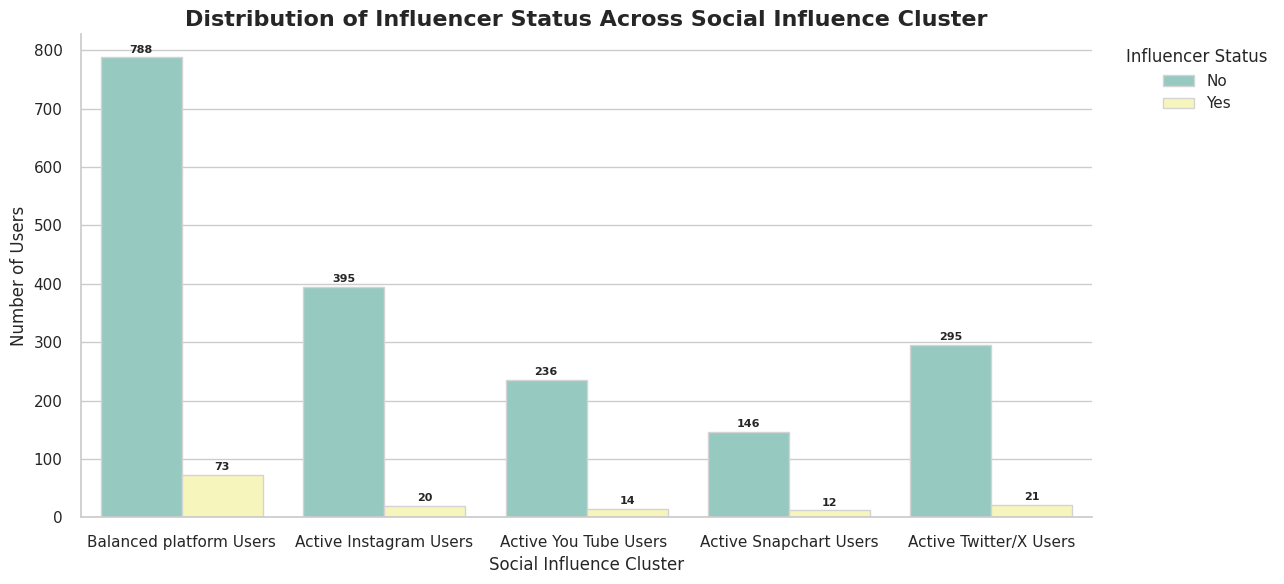

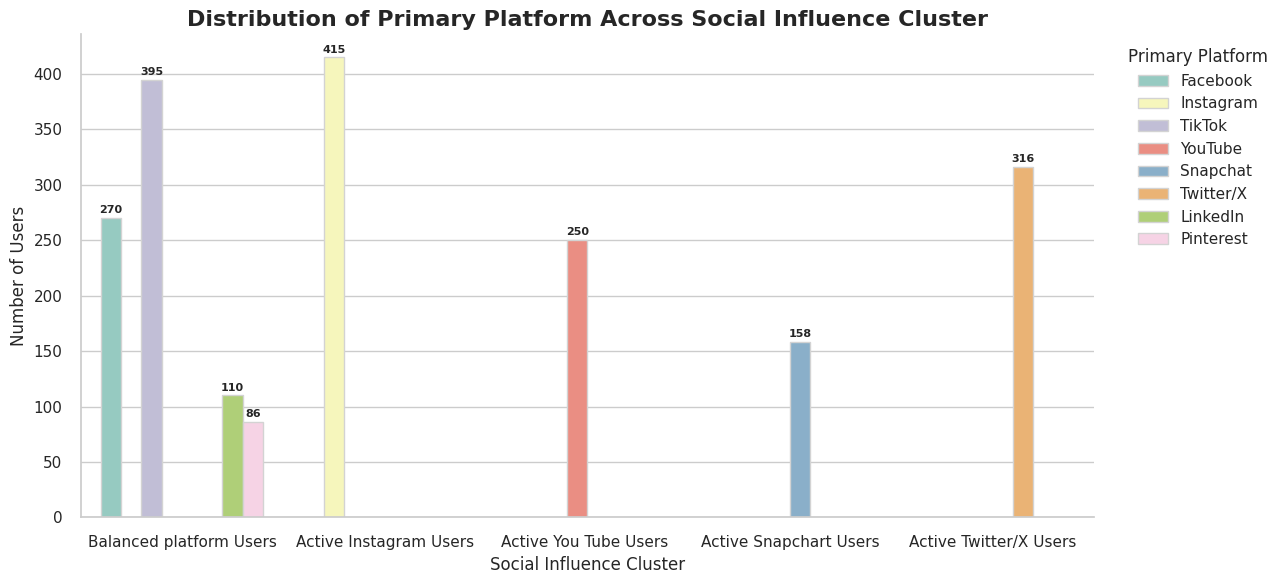

In [ ]:

sb.set_theme(style="whitegrid")

for f in objects_platform:

    plt.figure(figsize=(13, 6))

    ax = sb.countplot(
        data=df_cleaned,
        x='Social_Influence_Clusters',
        hue=f,
        palette='Set3',
        edgecolor='lightgrey'
    )

    plt.title(
        f'Distribution of {f.replace("_", " ").title()} Across Social Influence Cluster',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Social Influence Cluster')
    plt.ylabel('Number of Users')

    # Add counts on bars
    for container in ax.containers:
        ax.bar_label(container, fontsize=8, fontweight='bold', padding=2)

    plt.legend(
        title=f.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    sb.despine()
    plt.tight_layout()
    plt.show()

#### DBSCAN CLustering

In [ ]:
# Example for Social features (x_sociall_influence)
dbscan = DBSCAN(eps=4, min_samples=6) # Tune these parameters
df_cleaned['DBSCAN_cluster_Social_Influence'] = dbscan.fit_predict(X_socail_influence_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_Social_Influence'].value_counts())

DBSCAN_cluster_Social_Influence
 0    1797
 1     110
 2      86
-1       7
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_socail_influence_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_socail_influence_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_Social_Influence']
mask = d_labels != -1

sil_d = silhouette_score(X_socail_influence_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_socail_influence_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.38
KMeans Davies-Bouldin Index: 1.28

DBSCAN Silhouette Score: 0.36
DBSCAN Davies-Bouldin Index: 0.87


In [ ]:
# Percentage crosstab of features
for feature in social_influence_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_Social_Influence'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


followers_count


followers_count,0,1,2,3,4,5,6,7,8,10,...,71352,78134,81406,85953,90336,93695,94448,117400,142022,2110323
DBSCAN_cluster_Social_Influence,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



following_count


following_count,4,6,8,9,10,11,12,13,14,15,...,5988,6042,6579,7232,7453,7853,8315,8925,9755,10000
DBSCAN_cluster_Social_Influence,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,14.0,14.0,14.0,14.0,14.0,14.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



posts_per_week


posts_per_week,0,1,2,3,4,5,6,7,8,9,10
DBSCAN_cluster_Social_Influence,,,,,,,,,,,
-1,14.0,14.0,29.0,14.0,14.0,0.0,14.0,0.0,0.0,0.0,0.0
0,4.0,15.0,23.0,24.0,16.0,11.0,5.0,2.0,0.0,0.0,0.0
1,6.0,15.0,26.0,21.0,13.0,12.0,3.0,3.0,0.0,0.0,1.0
2,5.0,16.0,22.0,21.0,16.0,12.0,6.0,0.0,1.0,0.0,1.0



influencer_status


influencer_status,No,Yes
DBSCAN_cluster_Social_Influence,,
-1,86.0,14.0
0,93.0,7.0
1,90.0,10.0
2,90.0,10.0



primary_platform


primary_platform,Facebook,Instagram,LinkedIn,Pinterest,Snapchat,TikTok,Twitter/X,YouTube
DBSCAN_cluster_Social_Influence,,,,,,,,
-1,0.0,0.0,0.0,0.0,71.0,29.0,0.0,0.0
0,15.0,23.0,0.0,0.0,9.0,22.0,18.0,14.0
1,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Social_names = {
   -1: "High-Influence Outliers",
    0: "General Social Media Users",
    1: "LinkedIn Professionals",
    2: "Pinterest Creators"
}

df_cleaned['DBSCAN_Socials_Names'] = df_cleaned['DBSCAN_cluster_Social_Influence'].map(dbscan_Social_names)
print(df_cleaned['DBSCAN_Socials_Names'].value_counts())


DBSCAN_Socials_Names
General Social Media Users    1797
LinkedIn Professionals         110
Pinterest Creators              86
High-Influence Outliers          7
Name: count, dtype: int64


In [ ]:
from plotly.subplots import make_subplots
import plotly.express as px

# Create a DataFrame for the scores
scores_data_engagement = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df_engagement = pd.DataFrame(scores_data_engagement)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison for Engagement', 'Davies-Bouldin Index Comparison for Engagement'))

# Create Silhouette Score bar chart
fig_sil_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil_engagement.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi_engagement.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics for Engagement Features",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

### Spending & Marketing Clustering

In [ ]:
Spending_marketing_features = [
    'ad_click_rate',
    'purchased_via_social_media',
    'monthly_spend_via_social_usd',
    'primary_purpose'
]
X_spending_marketing = df_cleaned[Spending_marketing_features]

In [ ]:
x_spending = pd.get_dummies(X_spending_marketing, drop_first=True) # encoding
X_spending_scaled = StandardScaler().fit_transform(x_spending)      # Scaling

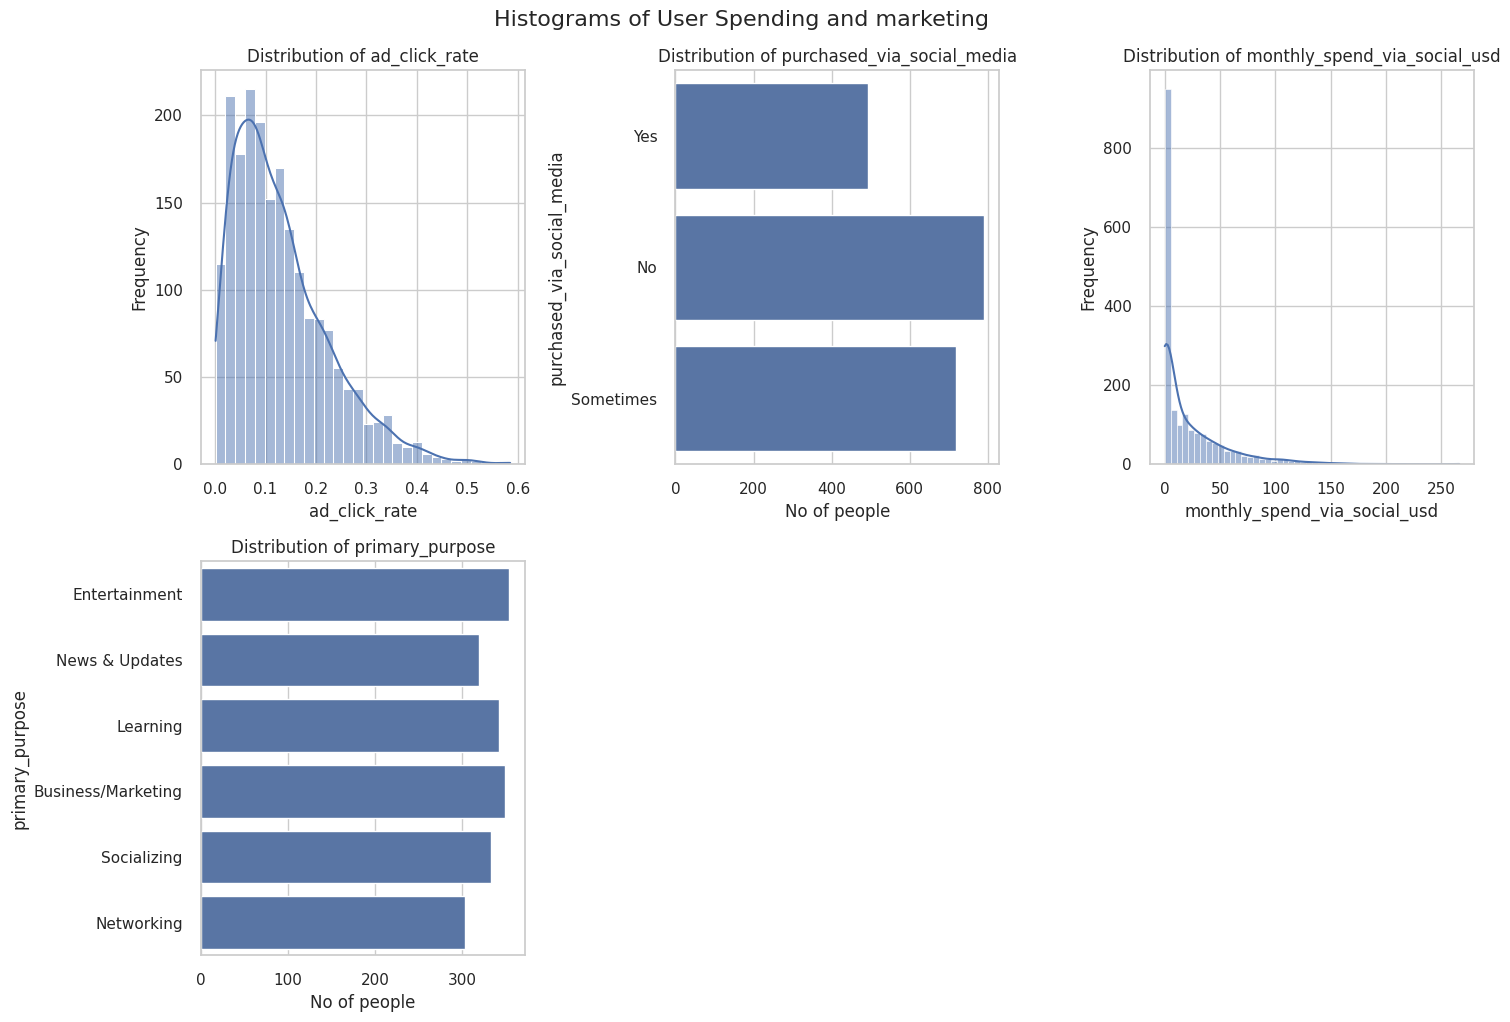

In [ ]:
# Pre-Visualization of data in segament Before Clustering
objects_spending = []
plt.figure(figsize=(15, 10))
num_features = len(Spending_marketing_features)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(Spending_marketing_features):
    plt.subplot(num_rows, num_cols, i + 1)
    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        objects_spending.append(feature)
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature}')
        plt.xlabel('No of people')
        plt.ylabel(feature)
    else: # Handle numerical features
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of User Spending and marketing', y=1.02, fontsize=16)
plt.show()

#### Kmeans and silhouette Score

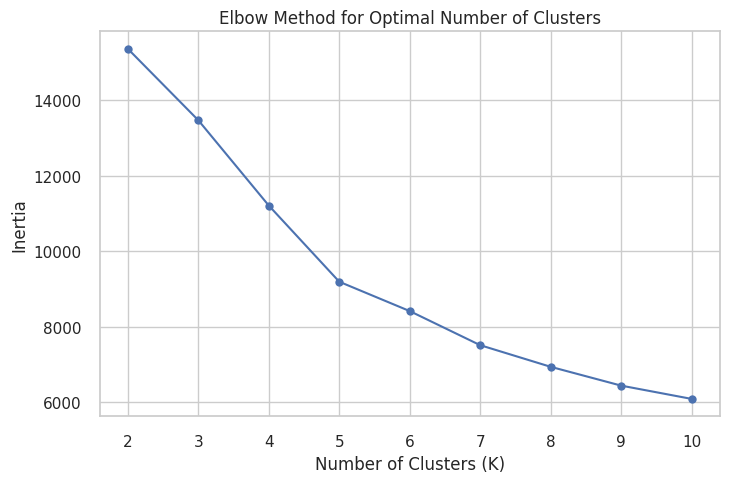

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=10,
        n_init=10
    )

    kmeans.fit(X_spending_scaled)
    inertia.append(kmeans.inertia_)

inertia
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans_model_spending = apply_kmeans(k=5,cluster_name='Kmeans_cluster_spending_Marketing', x_scaled=X_spending_scaled)

Kmeans_cluster_spending_Marketing
3    703
0    342
4    333
2    319
1    303
Name: count, dtype: int64


In [ ]:
df_spending_pca = apply_PCA(X_spending_scaled, df_cleaned, 'Kmeans_cluster_spending_Marketing', output_cluster_col_name='Spending_Marketing_Clusters')
apply_PCA_visualization(df_spending_pca, 'Spending_Marketing_Clusters')

#### Cluster Profiling -- Spending and Marketing

In [ ]:
# Identify ONLY numerical features within Spending_marketing_features to avoid TypeErrors
numerical_Spending_marketing_features = [f for f in Spending_marketing_features if df_cleaned[f].dtype in ['int64', 'float64']]

# Group by cluster and calculate mean only for numeric columns
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster_spending_Marketing')[numerical_Spending_marketing_features].mean()

display(cluster_summary_numerical)

,ad_click_rate,monthly_spend_via_social_usd
Kmeans_cluster_spending_Marketing,,
0,0.134155,21.959912
1,0.118201,21.365974
2,0.135781,23.569530
3,0.129404,24.133926
4,0.132474,20.322643


In [ ]:
# Identify categorical features within Spending_marketing_features
categorical_Spending_marketing_features = [f for f in Spending_marketing_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in categorical_Spending_marketing_features:
    print(f"\nMost frequent '{feature}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster_spending_Marketing')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)



Most frequent 'purchased_via_social_media' by KMeans Cluster:


,purchased_via_social_media
Kmeans_cluster_spending_Marketing,
0,No
1,No
2,No
3,No
4,No



Most frequent 'primary_purpose' by KMeans Cluster:


,primary_purpose
Kmeans_cluster_spending_Marketing,
0,Learning
1,Networking
2,News & Updates
3,Entertainment
4,Socializing


In [ ]:
# Percentage crosstab of features
for feature in Spending_marketing_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster_spending_Marketing'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


ad_click_rate


ad_click_rate,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.479,0.487,0.492,0.495,0.501,0.513,0.515,0.534,0.579,0.585
Kmeans_cluster_spending_Marketing,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



purchased_via_social_media


purchased_via_social_media,No,Sometimes,Yes
Kmeans_cluster_spending_Marketing,,,
0,40.0,34.0,25.0
1,38.0,38.0,24.0
2,40.0,38.0,22.0
3,39.0,36.0,24.0
4,39.0,33.0,28.0



monthly_spend_via_social_usd


monthly_spend_via_social_usd,0.00,0.03,0.06,0.11,0.12,0.16,0.17,0.21,0.22,0.23,...,175.56,186.87,191.44,193.49,199.24,206.75,219.22,254.77,264.54,266.37
Kmeans_cluster_spending_Marketing,,,,,,,,,,,,,,,,,,,,,
0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



primary_purpose


primary_purpose,Business/Marketing,Entertainment,Learning,Networking,News & Updates,Socializing
Kmeans_cluster_spending_Marketing,,,,,,
0,0.0,0.0,100.0,0.0,0.0,0.0
1,0.0,0.0,0.0,100.0,0.0,0.0
2,0.0,0.0,0.0,0.0,100.0,0.0
3,50.0,50.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,100.0


In [ ]:
# Fix: Map the cluster names to the main DataFrame first
spending_marketing_cluster_names = {
    0: "Low Spenders",
    1: "Occasional Buyers",
    2: "High Spenders",
    3: "Value Buyers",
    4: "Budget Buyers"
}

df_cleaned['Spending_Marketing_Clusters'] = df_cleaned['Kmeans_cluster_spending_Marketing'].map(spending_marketing_cluster_names)
print(df_cleaned['Spending_Marketing_Clusters'].value_counts())

Spending_Marketing_Clusters
Value Buyers         703
Low Spenders         342
Budget Buyers        333
High Spenders        319
Occasional Buyers    303
Name: count, dtype: int64


In [ ]:
df_spending_pca = apply_PCA(X_spending_scaled, df_cleaned, 'Spending_Marketing_Clusters', output_cluster_col_name='Spending_Marketing_Clusters')
apply_PCA_visualization(df_spending_pca, 'Spending_Marketing_Clusters')

**Identify categorical vs numerical features for appropriate plotting**

In [ ]:
pd.crosstab(df_cleaned['Spending_Marketing_Clusters'], df_cleaned['purchased_via_social_media'])

purchased_via_social_media,No,Sometimes,Yes
Spending_Marketing_Clusters,,,
Budget Buyers,130,110,93
High Spenders,129,120,70
Low Spenders,138,117,87
Occasional Buyers,116,115,72
Value Buyers,277,256,170


In [ ]:
for feature in Spending_marketing_features:

    print(f"\nMost frequent '{feature}' by Cluster:")
    mode_by_cluster = (
        df_cleaned.groupby('Kmeans_cluster_spending_Marketing')[feature]
        .agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    )
    display(mode_by_cluster)


Most frequent 'ad_click_rate' by Cluster:


,ad_click_rate
Kmeans_cluster_spending_Marketing,
0,0.061
1,0.028
2,0.153
3,0.030
4,0.035



Most frequent 'purchased_via_social_media' by Cluster:


,purchased_via_social_media
Kmeans_cluster_spending_Marketing,
0,No
1,No
2,No
3,No
4,No



Most frequent 'monthly_spend_via_social_usd' by Cluster:


,monthly_spend_via_social_usd
Kmeans_cluster_spending_Marketing,
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0



Most frequent 'primary_purpose' by Cluster:


,primary_purpose
Kmeans_cluster_spending_Marketing,
0,Learning
1,Networking
2,News & Updates
3,Entertainment
4,Socializing


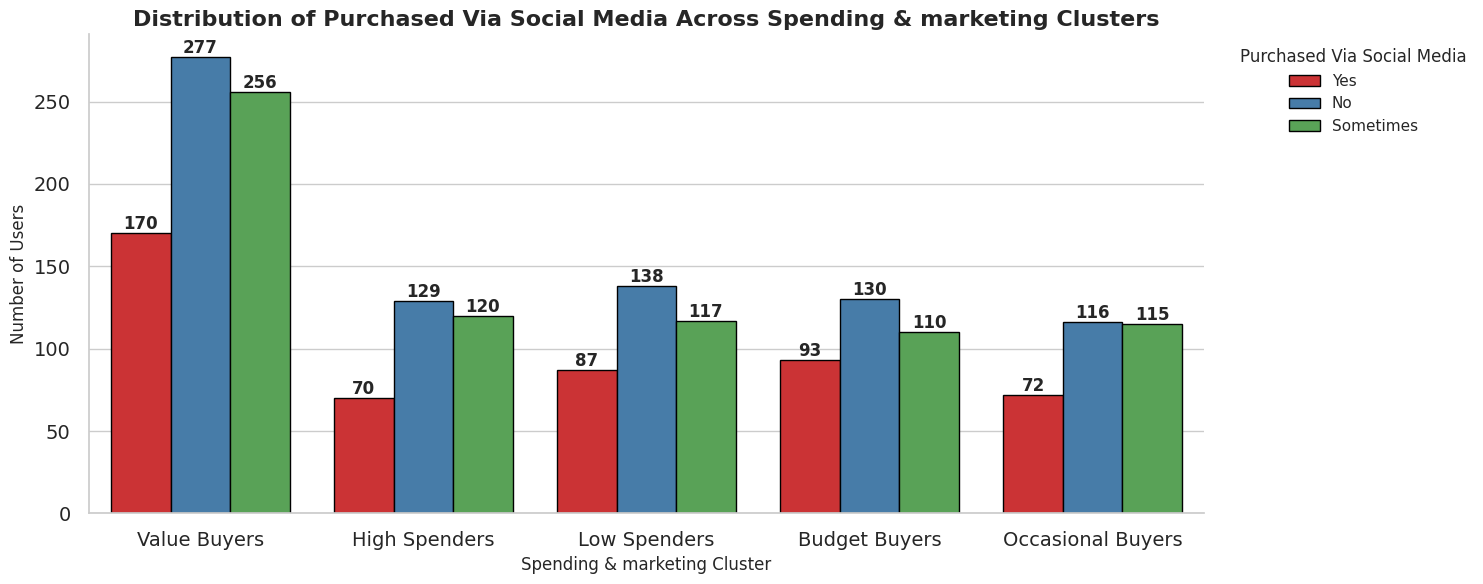

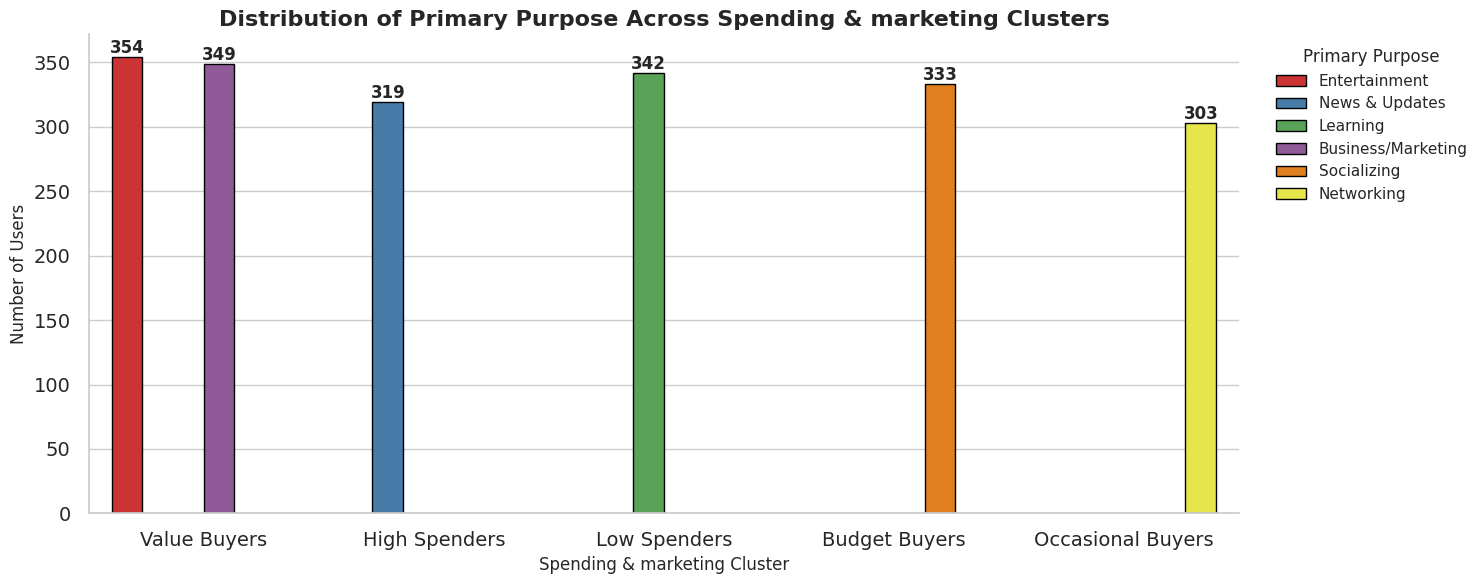

In [ ]:
# for f in objects_spending:
#   plt.figure(figsize=(15, 6))
#   plt.title(f'Distribution of {f.replace("_", " ").title()} spending and marketing CLuster', fontsize=14, fontweight='bold')
#   sb.countplot(data=df_cleaned, x='Kmeans_cluster_spending_Marketing', hue=f, palette='Set2')
#   plt.ylabel('Number of Users')
#   plt.legend(title= f.replace("_"," ").title(), bbox_to_anchor=(1.05, 1), loc='upper left')
#   plt.xlabel('spending and marketing Cluster')
#   plt.tight_layout()
#   plt.show()

#   # Template for Cluster vs Categorical Feature Countplots

sb.set_theme(style="whitegrid")

for f in objects_spending:

    plt.figure(figsize=(15, 6))

    ax = sb.countplot(
        data=df_cleaned,
        x='Spending_Marketing_Clusters',
        hue=f,
        palette='Set1',
        edgecolor='black'
    )

    plt.title(
        f'Distribution of {f.replace("_", " ").title()} Across Spending & marketing Clusters',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Spending & marketing Cluster')
    plt.ylabel('Number of Users')
    plt.xticks(fontsize=14, fontweight=14)
    plt.yticks(fontsize=14, fontweight=14)
    # Add counts on bars
    for container in ax.containers:
        ax.bar_label(container, fontsize=12, fontweight='bold')

    plt.legend(
        title=f.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    sb.despine()
    plt.tight_layout()
    plt.show()

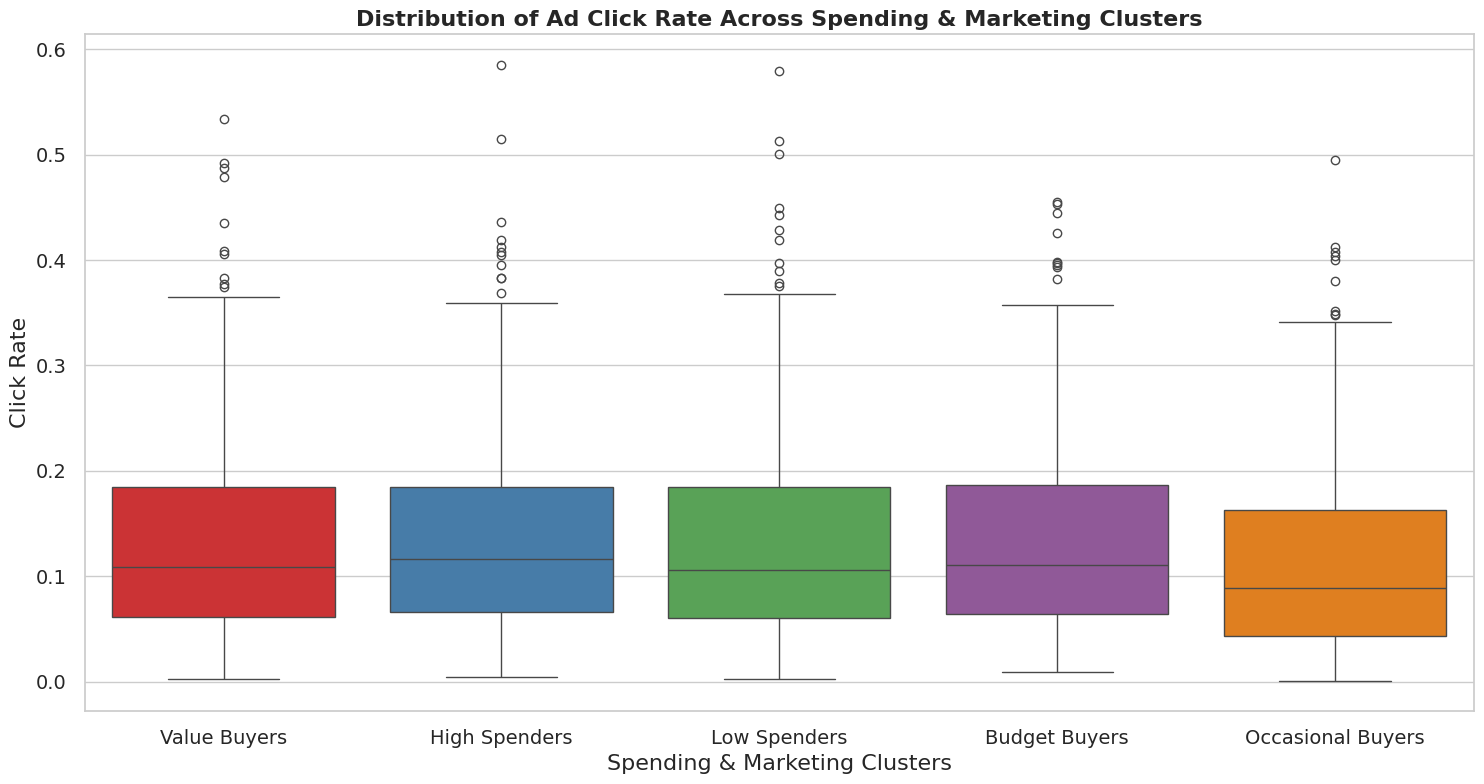

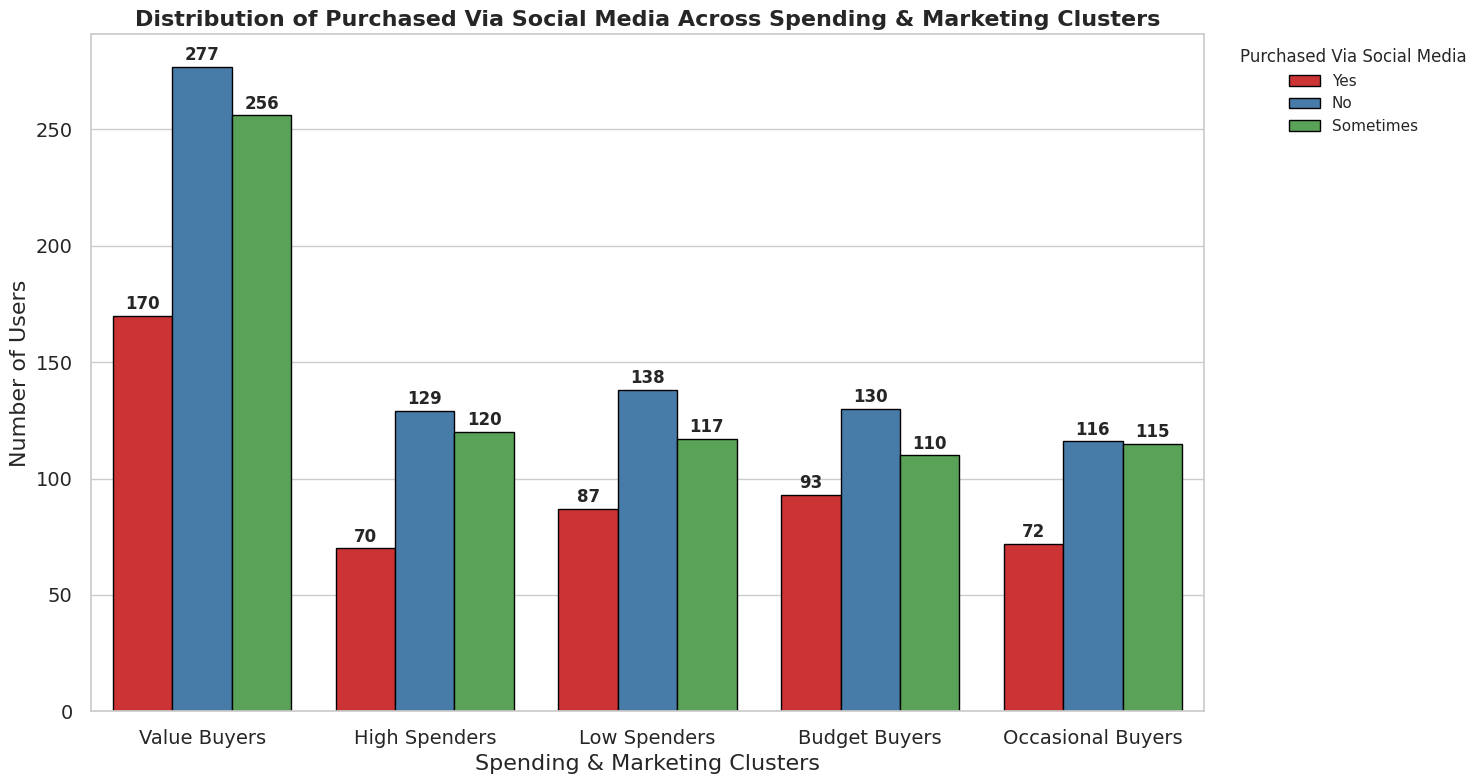

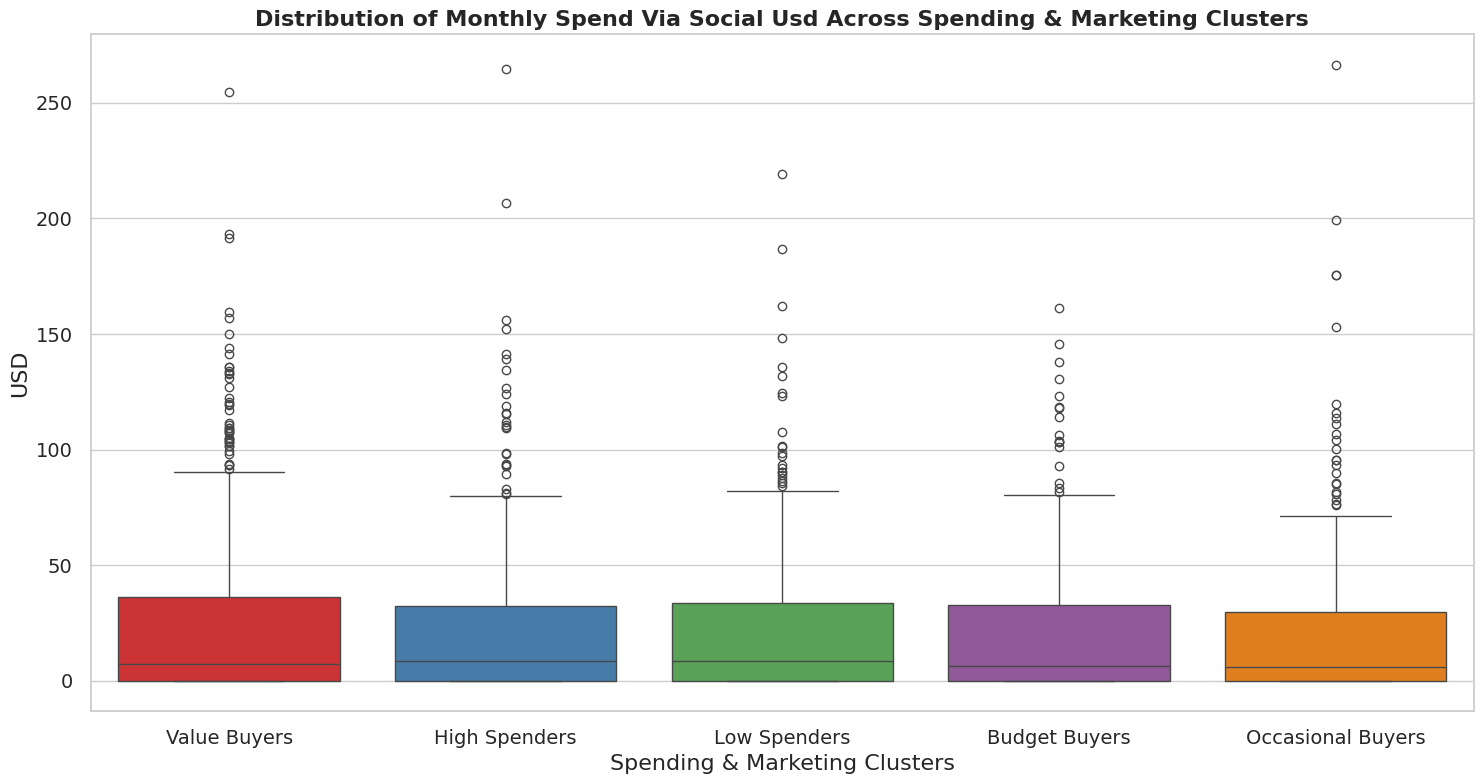

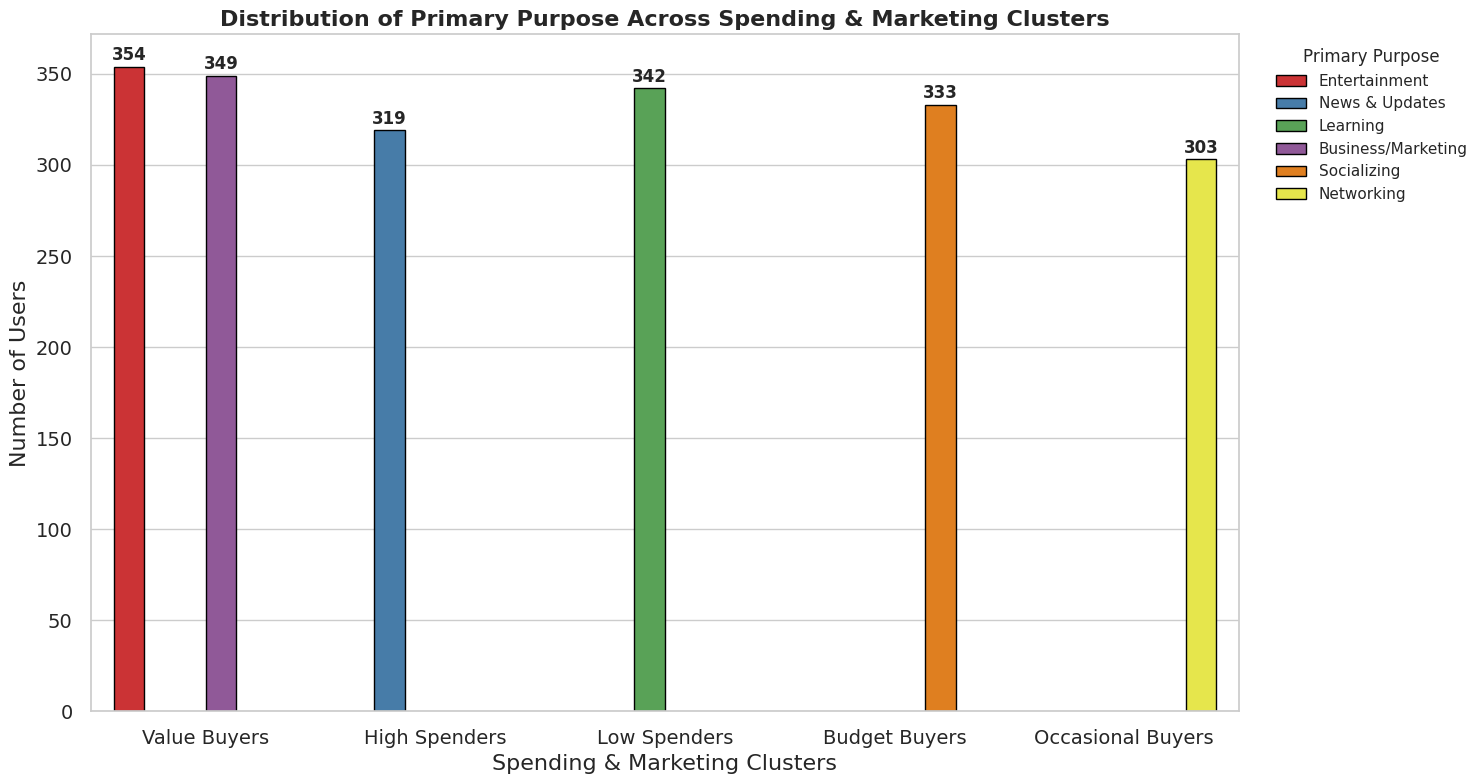

In [ ]:
sb.set_theme(style="whitegrid")

categorical_Spending_marketing_features = [
    f for f in Spending_marketing_features
    if f in df_cleaned.select_dtypes(include=['object', 'category']).columns
]

for feature in Spending_marketing_features:

    plt.figure(figsize=(15, 8))

    if feature == 'monthly_spend_via_social_usd':

        ax = sb.boxplot(
            data=df_cleaned,
            x='Spending_Marketing_Clusters',
            y=feature,
            palette='Set1'
        )
        plt.ylabel('USD', fontweight=16, fontsize= 16)

    elif feature == 'ad_click_rate':

        ax = sb.boxplot(
            data=df_cleaned,
            x='Spending_Marketing_Clusters',
            y=feature,
            palette='Set1'
        )
        plt.ylabel('Click Rate', fontweight=16, fontsize= 16)

    else:

        ax = sb.countplot(
            data=df_cleaned,
            x='Spending_Marketing_Clusters',
            hue=feature,
            palette='Set1',
            edgecolor='black'
        )

        for container in ax.containers:
            ax.bar_label(container, fontsize=12, padding=2, fontweight='bold')
        plt.ylabel('Number of Users', fontweight=16, fontsize= 16)
        plt.legend(
            title=feature.replace('_', ' ').title(),
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
    plt.title(
        f'Distribution of {feature.replace("_", " ").title()} Across Spending & Marketing Clusters',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Spending & Marketing Clusters', fontweight=16, fontsize= 16)
    plt.xticks(fontsize=14, fontweight=14)
    plt.yticks(fontsize=14, fontweight=14)

    plt.tight_layout()
    plt.show()

#### DBSCAN CLustering

In [ ]:
# Example for Social features (x_sociall_influence)
dbscan = DBSCAN(eps=2.5, min_samples=5) # Tune these parameters
df_cleaned['DBSCAN_cluster_Spending_Marketing'] = dbscan.fit_predict(X_spending_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_Spending_Marketing'].value_counts())

DBSCAN_cluster_Spending_Marketing
 0    353
 3    349
 2    342
 4    333
 1    318
 5    303
-1      2
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_spending_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_spending_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_Spending_Marketing']
mask = d_labels != -1

sil_d = silhouette_score(X_spending_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_spending_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: -0.02
KMeans Davies-Bouldin Index: 36.70

DBSCAN Silhouette Score: 0.34
DBSCAN Davies-Bouldin Index: 1.40


In [ ]:
# Percentage crosstab of features
for feature in Spending_marketing_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_Spending_Marketing'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


ad_click_rate


ad_click_rate,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.479,0.487,0.492,0.495,0.501,0.513,0.515,0.534,0.579,0.585
DBSCAN_cluster_Spending_Marketing,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



purchased_via_social_media


purchased_via_social_media,No,Sometimes,Yes
DBSCAN_cluster_Spending_Marketing,,,
-1,0.0,50.0,50.0
0,39.0,39.0,23.0
1,41.0,37.0,22.0
2,40.0,34.0,25.0
3,40.0,34.0,26.0
4,39.0,33.0,28.0
5,38.0,38.0,24.0



monthly_spend_via_social_usd


monthly_spend_via_social_usd,0.00,0.03,0.06,0.11,0.12,0.16,0.17,0.21,0.22,0.23,...,175.56,186.87,191.44,193.49,199.24,206.75,219.22,254.77,264.54,266.37
DBSCAN_cluster_Spending_Marketing,,,,,,,,,,,,,,,,,,,,,
-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,50.0,0.0
0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,40.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



primary_purpose


primary_purpose,Business/Marketing,Entertainment,Learning,Networking,News & Updates,Socializing
DBSCAN_cluster_Spending_Marketing,,,,,,
-1,0.0,50.0,0.0,0.0,50.0,0.0
0,0.0,100.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,100.0,0.0
2,0.0,0.0,100.0,0.0,0.0,0.0
3,100.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,100.0
5,0.0,0.0,0.0,100.0,0.0,0.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Spendings_names = {
   -1: "Selective High Spenders",
    0: "Entertainment Users",
    1: "News Followers",
    2: "Learners",
    3: "Business Users",
    4: "Social Connectors",
    5: "Network Builders"
}

df_cleaned['DBSCAN_Spendings_Names'] = df_cleaned['DBSCAN_cluster_Spending_Marketing'].map(dbscan_Spendings_names)
print(df_cleaned['DBSCAN_Spendings_Names'].value_counts())


DBSCAN_Spendings_Names
Entertainment Users        353
Business Users             349
Learners                   342
Social Connectors          333
News Followers             318
Network Builders           303
Selective High Spenders      2
Name: count, dtype: int64


In [ ]:
from plotly.subplots import make_subplots
import plotly.express as px

# Create a DataFrame for the scores
scores_data_engagement = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df_engagement = pd.DataFrame(scores_data_engagement)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison for Engagement', 'Davies-Bouldin Index Comparison for Engagement'))

# Create Silhouette Score bar chart
fig_sil_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi_engagement = px.bar(scores_df_engagement, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil_engagement.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi_engagement.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics for Engagement Features",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

###  Demographic + Lifestyle Clustering

In [ ]:
demographic_lifestyle_features = np.array([
    'age',
    'gender',
    'country',
    'profession',
    'preferred_device',
    'privacy_setting'
])
X_demographic_lifestyle = df_cleaned[demographic_lifestyle_features]

In [ ]:
x_demographic_lifestyle = pd.get_dummies(X_demographic_lifestyle, drop_first=True) # Encoding
X_demographic_lifestyle_scaled = StandardScaler().fit_transform(x_demographic_lifestyle) # Scaling

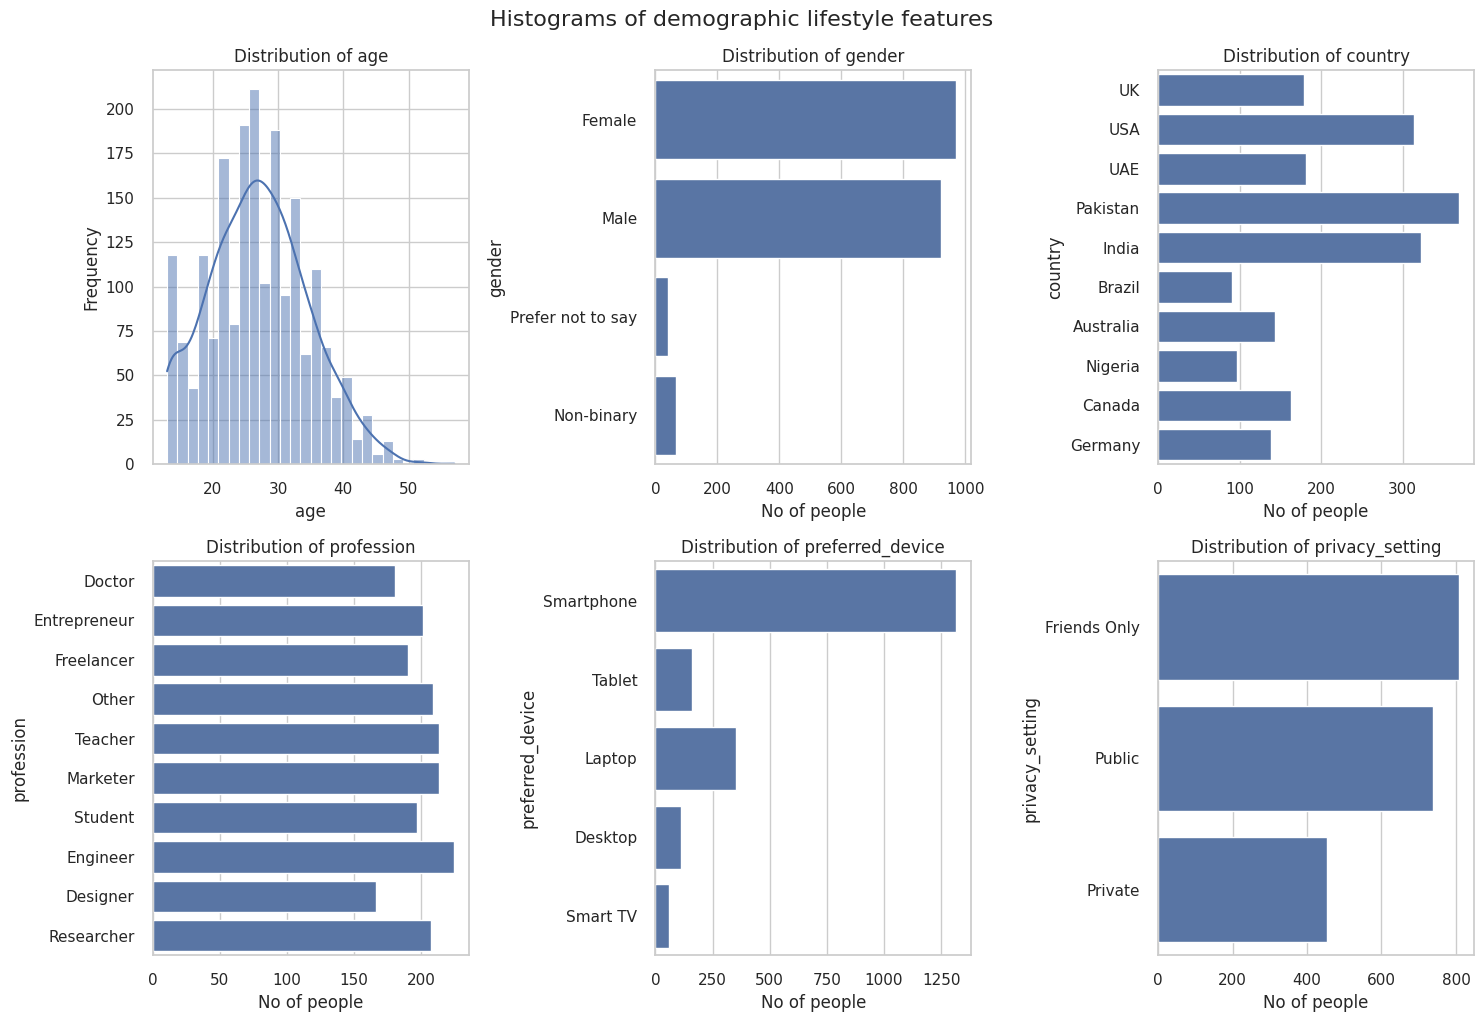

In [ ]:
plt.figure(figsize=(15, 10))
num_features = len(demographic_lifestyle_features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(demographic_lifestyle_features):
    plt.subplot(num_rows, num_cols, i + 1)
    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature}')
        plt.xlabel('No of people')
        plt.ylabel(feature)
    else:                                      # Handle numerical features
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of demographic lifestyle features', y=1.02, fontsize=16)
plt.show()

#### Elbow Method and Silhouette score  for clustering

In [ ]:
inertia = []
silhouette_scores =[]
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X_demographic_lifestyle_scaled)
    inertia.append(kmeans.inertia_)

    # Silhouette score
    labels = kmeans.fit_predict(X_demographic_lifestyle_scaled)
    score = silhouette_score(X_demographic_lifestyle_scaled, labels)
    silhouette_scores.append(score)

print("Elbow score: ")
print(inertia)

for k, score in zip(K, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")



Elbow score: 
[52695.499176246296, 51130.85877164235, 48768.95207923746, 47017.27222674646, 45180.84618545394, 42708.30718598672, 40717.58263919055, 39536.387964717935, 37897.20845024986]
K=2: Silhouette Score = 0.0866
K=3: Silhouette Score = 0.0322
K=4: Silhouette Score = 0.0823
K=5: Silhouette Score = 0.0920
K=6: Silhouette Score = 0.1139
K=7: Silhouette Score = 0.1348
K=8: Silhouette Score = 0.1640
K=9: Silhouette Score = 0.1619
K=10: Silhouette Score = 0.1773


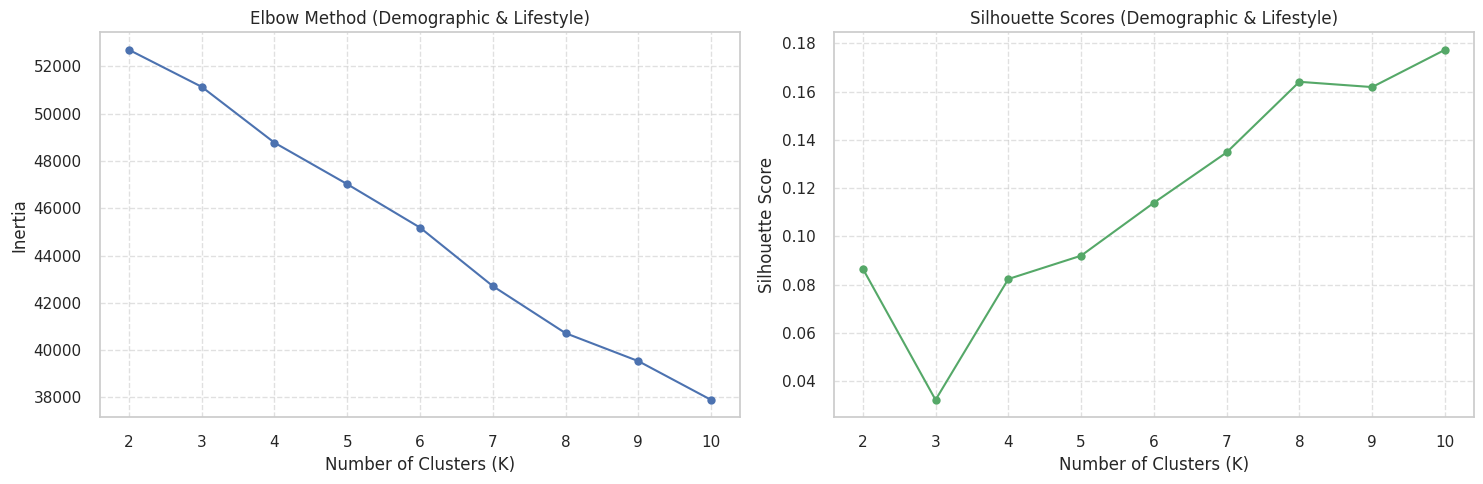

In [ ]:
plt.figure(figsize=(15, 5))

# Plotting Inertia (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o', color='b')
plt.title('Elbow Method (Demographic & Lifestyle)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='g')
plt.title('Silhouette Scores (Demographic & Lifestyle)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Clustering- Kmeans and PCA

In [ ]:
kmeans_model = apply_kmeans(k=4,cluster_name='Kmeans_cluster_demographic_lifestyle', x_scaled=X_demographic_lifestyle_scaled) # demographic_lifestyle_features

Kmeans_cluster_demographic_lifestyle
1    1274
3     369
2     198
0     159
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'User_Behavior_Clusters'
pca_Df = apply_PCA(X_demographic_lifestyle_scaled, df_cleaned, cluster_col_name='Kmeans_cluster_demographic_lifestyle', output_cluster_col_name='demographic_lifestyle_Clusters')


In [ ]:
import plotly.express as px

# Call the function to visualize the PCA results
apply_PCA_visualization (pca_Df, 'demographic_lifestyle_Clusters')

#### Profiling of CLusters by naming

In [ ]:
# Identify ONLY numerical features within demographic_lifestyle_features to avoid TypeErrors
numerical_demographic_lifestyle_features = [f for f in demographic_lifestyle_features if df_cleaned[f].dtype in ['int64', 'float64']]

# Group by cluster and calculate mean only for numeric columns
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster_demographic_lifestyle')[numerical_demographic_lifestyle_features].mean()

display(cluster_summary_numerical)

,age
Kmeans_cluster_demographic_lifestyle,
0,27.006289
1,27.043171
2,27.040404
3,26.750678


In [ ]:
# Numirical Features Profiling
categorical_demographic_lifestyle_features = [f for f in demographic_lifestyle_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in demographic_lifestyle_features:
    print(f"\nMost frequent '{feature.replace("_"," ").title()}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster_demographic_lifestyle')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'Age' by KMeans Cluster:


,age
Kmeans_cluster_demographic_lifestyle,
0,26
1,31
2,27
3,26



Most frequent 'Gender' by KMeans Cluster:


,gender
Kmeans_cluster_demographic_lifestyle,
0,Female
1,Female
2,Female
3,Female



Most frequent 'Country' by KMeans Cluster:


...

,profession
Kmeans_cluster_demographic_lifestyle,
0,Teacher
1,Engineer
2,Marketer
3,Teacher



Most frequent 'Preferred Device' by KMeans Cluster:


,preferred_device
Kmeans_cluster_demographic_lifestyle,
0,Tablet
1,Smartphone
2,Smartphone
3,Laptop



Most frequent 'Privacy Setting' by KMeans Cluster:


,privacy_setting
Kmeans_cluster_demographic_lifestyle,
0,Friends Only
1,Friends Only
2,Friends Only
3,Public


In [ ]:
df_cleaned['Kmeans_cluster_demographic_lifestyle'].value_counts()

,count
Kmeans_cluster_demographic_lifestyle,
1,1274
3,369
2,198
0,159


In [ ]:
# Percentage crosstab of features
for feature in categorical_demographic_lifestyle_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster_demographic_lifestyle'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


gender


gender,Female,Male,Non-binary,Prefer not to say
Kmeans_cluster_demographic_lifestyle,,,,
0,47.0,46.0,4.0,3.0
1,48.0,47.0,3.0,2.0
2,54.0,39.0,6.0,2.0
3,48.0,47.0,3.0,2.0



country


country,Australia,Brazil,Canada,Germany,India,Nigeria,Pakistan,UAE,UK,USA
Kmeans_cluster_demographic_lifestyle,,,,,,,,,,
0,6.0,7.0,11.0,6.0,13.0,6.0,18.0,12.0,10.0,11.0
1,7.0,5.0,7.0,7.0,16.0,5.0,20.0,9.0,8.0,16.0
2,8.0,4.0,9.0,11.0,20.0,6.0,12.0,7.0,10.0,15.0
3,8.0,4.0,10.0,4.0,16.0,4.0,18.0,10.0,10.0,16.0



profession


profession,Designer,Doctor,Engineer,Entrepreneur,Freelancer,Marketer,Other,Researcher,Student,Teacher
Kmeans_cluster_demographic_lifestyle,,,,,,,,,,
0,6.0,9.0,11.0,13.0,9.0,9.0,11.0,8.0,8.0,16.0
1,9.0,11.0,13.0,11.0,11.0,0.0,12.0,12.0,12.0,11.0
2,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
3,12.0,9.0,11.0,11.0,11.0,0.0,12.0,12.0,8.0,14.0



preferred_device


preferred_device,Desktop,Laptop,Smart TV,Smartphone,Tablet
Kmeans_cluster_demographic_lifestyle,,,,,
0,0.0,0.0,0.0,0.0,100.0
1,8.0,0.0,0.0,92.0,0.0
2,5.0,20.0,3.0,73.0,0.0
3,0.0,85.0,15.0,0.0,0.0



privacy_setting


privacy_setting,Friends Only,Private,Public
Kmeans_cluster_demographic_lifestyle,,,
0,42.0,28.0,30.0
1,40.0,22.0,38.0
2,43.0,25.0,32.0
3,38.0,22.0,40.0


In [ ]:
pd.crosstab(df_cleaned['Kmeans_cluster_demographic_lifestyle'], df_cleaned['privacy_setting'])

privacy_setting,Friends Only,Private,Public
Kmeans_cluster_demographic_lifestyle,,,
0,67,45,47
1,515,276,483
2,86,49,63
3,140,83,146


In [ ]:
pd.crosstab(df_cleaned['Kmeans_cluster_demographic_lifestyle'], df_cleaned['preferred_device'])

preferred_device,Desktop,Laptop,Smart TV,Smartphone,Tablet
Kmeans_cluster_demographic_lifestyle,,,,,
0,0,0,0,0,159
1,102,0,0,1172,0
2,10,39,5,144,0
3,0,315,54,0,0


In [ ]:
pd.crosstab(df_cleaned['Kmeans_cluster_demographic_lifestyle'], df_cleaned['age'])

age,13,14,15,16,17,18,19,20,21,22,...,42,43,44,45,46,47,48,51,52,57
Kmeans_cluster_demographic_lifestyle,,,,,,,,,,,,,,,,,,,,,
0,4,4,2,0,2,6,5,6,6,8,...,1,0,1,0,0,0,0,0,0,0
1,58,20,20,18,25,32,39,45,54,61,...,5,9,8,4,3,6,1,0,2,0
2,8,1,6,5,6,7,4,6,7,13,...,2,3,2,2,1,1,1,0,0,1
3,13,10,8,10,10,11,14,14,10,13,...,6,3,2,0,2,0,1,1,0,0


In [ ]:
# Map descriptive names for the Demographic & Lifestyle clusters
demographic_lifestyle_cluster_names = {
    0: "Social Tablet Users",
    1: "Everyday Smartphone Users",
    2: "Marketing Professionals",
    3: "Professional Laptop/TV Users"
}

df_cleaned['Demographic_Lifestyle_Segment'] = df_cleaned['Kmeans_cluster_demographic_lifestyle'].map(demographic_lifestyle_cluster_names)
print(df_cleaned['Demographic_Lifestyle_Segment'].value_counts())

Demographic_Lifestyle_Segment
Everyday Smartphone Users       1274
Professional Laptop/TV Users     369
Marketing Professionals          198
Social Tablet Users              159
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'User_Behavior_Clusters'
pca_Df = apply_PCA(X_demographic_lifestyle_scaled, df_cleaned, cluster_col_name='Demographic_Lifestyle_Segment', output_cluster_col_name='demographic_lifestyle_Clusters')


In [ ]:
import plotly.express as px

# Call the function to visualize the PCA results
apply_PCA_visualization (pca_Df, 'demographic_lifestyle_Clusters')

#### **Identify categorical vs numerical features for appropriate plotting**

In [ ]:
pd.crosstab(df_cleaned['Kmeans_cluster_demographic_lifestyle'], df_cleaned['profession'])

profession,Designer,Doctor,Engineer,Entrepreneur,Freelancer,Marketer,Other,Researcher,Student,Teacher
Kmeans_cluster_demographic_lifestyle,,,,,,,,,,
0,10,14,17,20,15,15,18,13,12,25
1,111,134,167,140,135,0,147,148,154,138
2,0,0,0,0,0,198,0,0,0,0
3,45,32,40,41,40,0,44,46,31,50


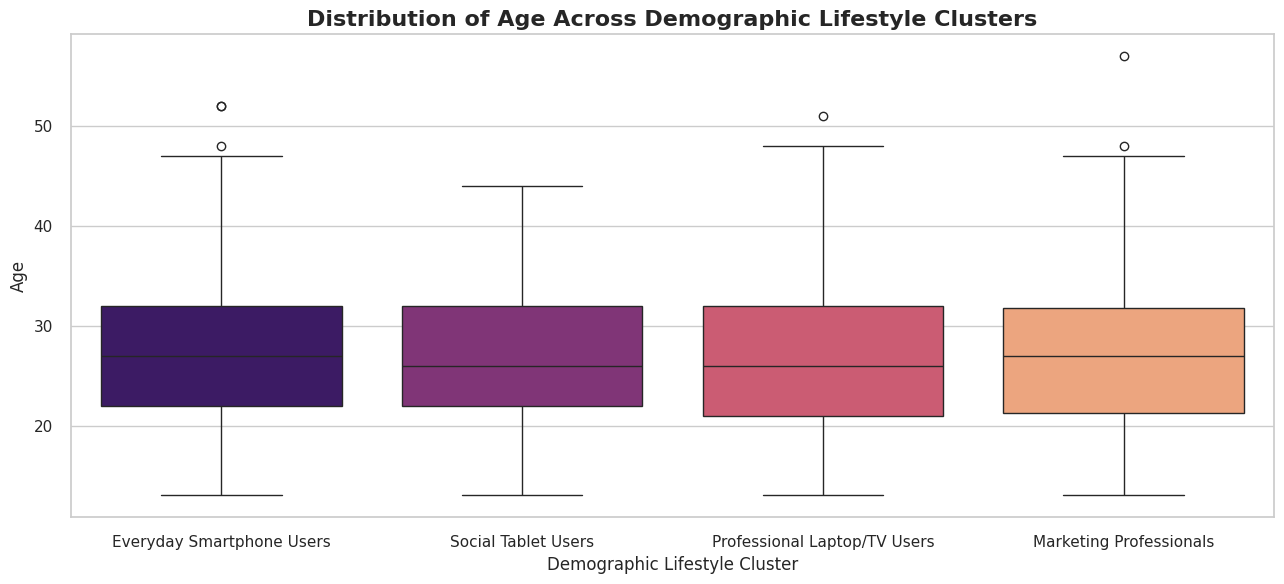

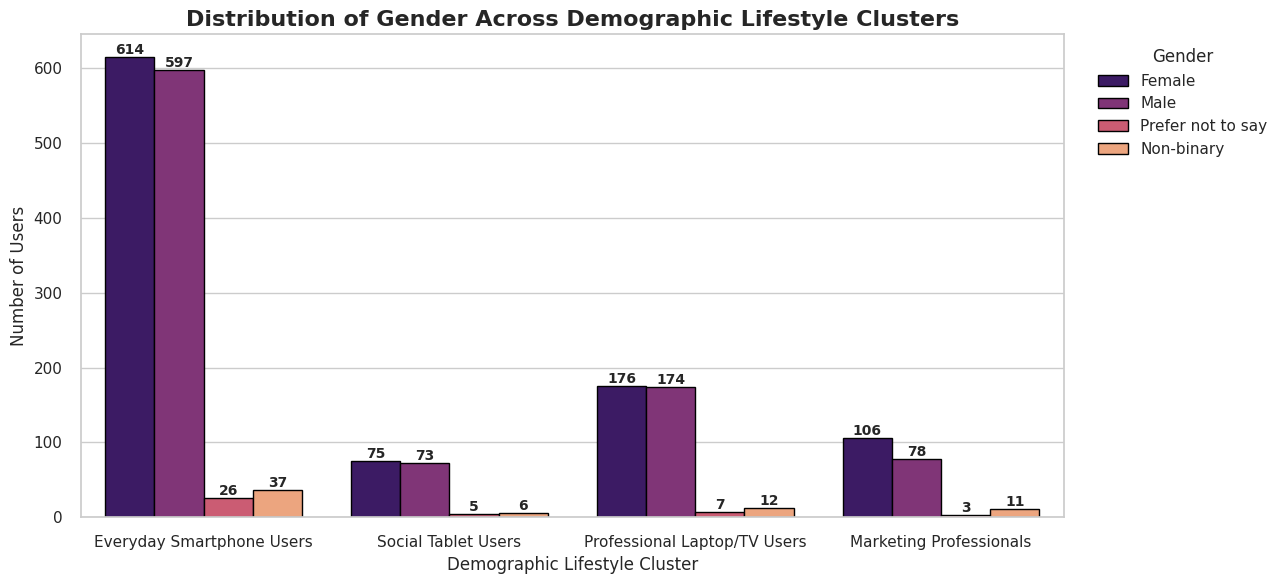

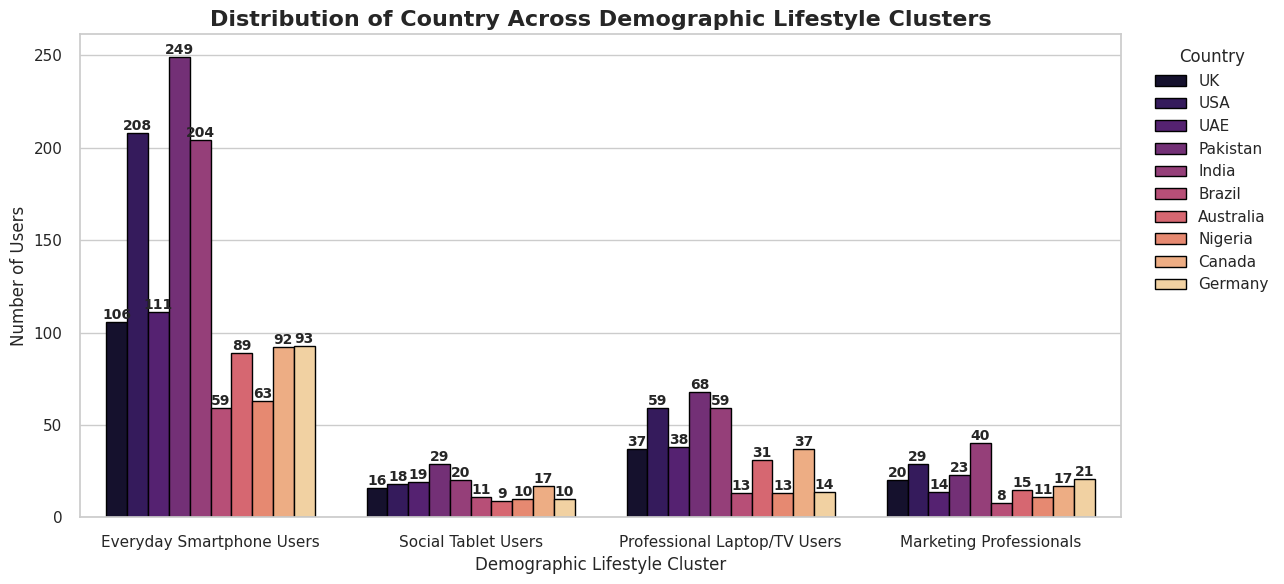

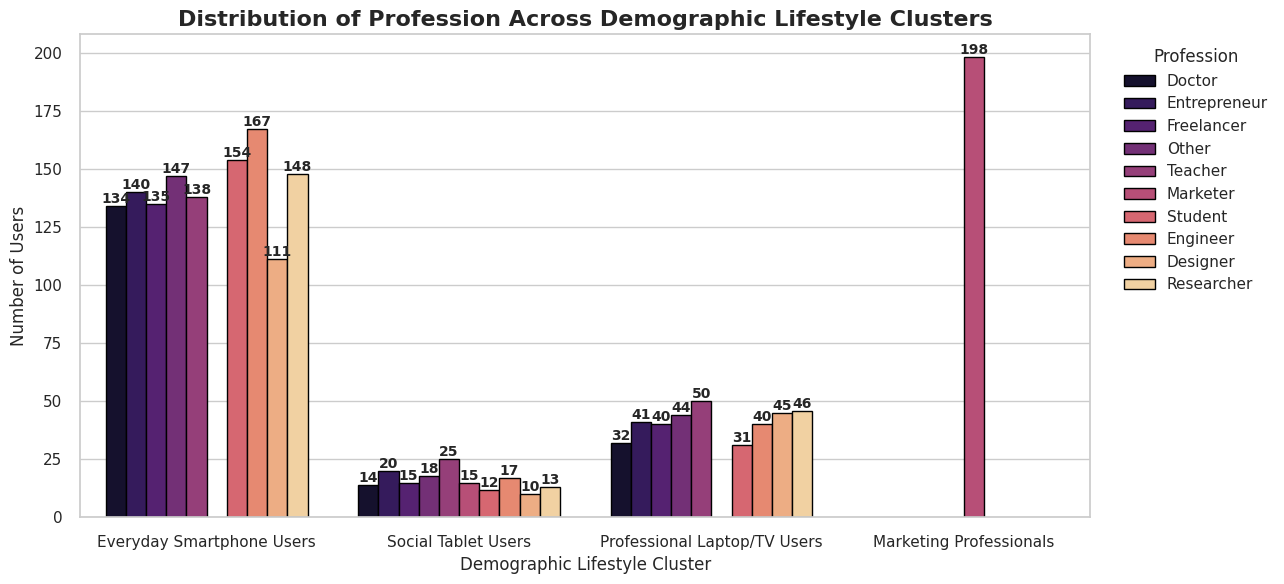

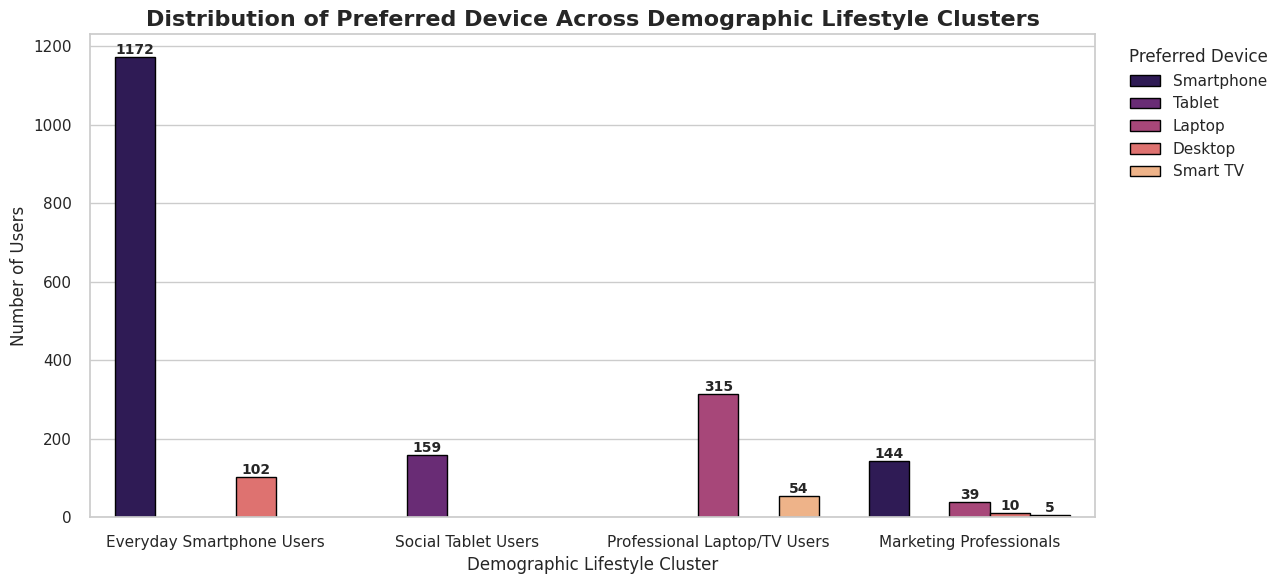

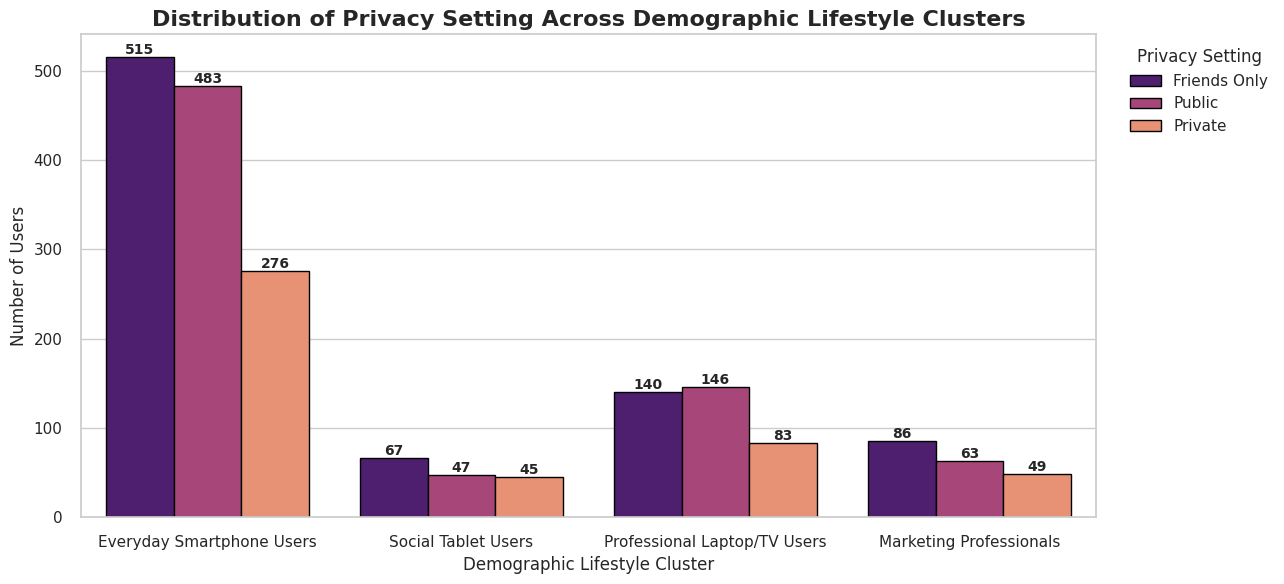

In [ ]:
sb.set_theme(style="whitegrid")

for feature in demographic_lifestyle_features:

    plt.figure(figsize=(13, 6))

    if feature == 'age':

        ax = sb.boxplot(
            data=df_cleaned,
            x='Demographic_Lifestyle_Segment',
            y=feature,
            palette='magma'
        )

        plt.ylabel('Age')

    else:

        ax = sb.countplot(
            data=df_cleaned,
            x='Demographic_Lifestyle_Segment',
            hue=feature,
            palette='magma',
            edgecolor='black'
        )

        # Add counts on bars
        for container in ax.containers:
            ax.bar_label(container, fontsize=10, fontweight='bold')

        plt.ylabel('Number of Users')

        plt.legend(
            title=feature.replace('_', ' ').title(),
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )

    plt.title(
        f'Distribution of {feature.replace("_", " ").title()} Across Demographic Lifestyle Clusters',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Demographic Lifestyle Cluster')


    plt.tight_layout()
    plt.show()

#### DBSCAN CLustering

In [ ]:
# Example for Social features (X_demographic_lifestyle_scaled)
dbscan = DBSCAN(eps=5, min_samples=5) # Tune these parameters
df_cleaned['DBSCAN_cluster_demographic_lifestyle'] = dbscan.fit_predict(X_demographic_lifestyle_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_demographic_lifestyle'].value_counts())

DBSCAN_cluster_demographic_lifestyle
 0    1836
 2      53
 1      51
 3      31
-1      29
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_demographic_lifestyle_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_demographic_lifestyle_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_demographic_lifestyle']
mask = d_labels != -1

sil_d = silhouette_score(X_demographic_lifestyle_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_demographic_lifestyle_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.08
KMeans Davies-Bouldin Index: 2.83

DBSCAN Silhouette Score: 0.22
DBSCAN Davies-Bouldin Index: 1.53


In [ ]:
# Percentage crosstab of features
for feature in demographic_lifestyle_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_demographic_lifestyle'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


age


age,13,14,15,16,17,18,19,20,21,22,...,42,43,44,45,46,47,48,51,52,57
DBSCAN_cluster_demographic_lifestyle,,,,,,,,,,,,,,,,,,,,,
-1,14.0,0.0,3.0,3.0,0.0,7.0,3.0,0.0,0.0,3.0,...,3.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
0,4.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,4.0,5.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,4.0,2.0,2.0,2.0,4.0,2.0,10.0,6.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,6.0,0.0,2.0,2.0,0.0,6.0,8.0,6.0,2.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,0.0,3.0,3.0,3.0,6.0,0.0,6.0,0.0,13.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



gender


gender,Female,Male,Non-binary,Prefer not to say
DBSCAN_cluster_demographic_lifestyle,,,,
-1,3.0,17.0,45.0,34.0
0,52.0,48.0,0.0,0.0
1,47.0,53.0,0.0,0.0
2,0.0,0.0,100.0,0.0
3,0.0,0.0,0.0,100.0



country


...

profession,Designer,Doctor,Engineer,Entrepreneur,Freelancer,Marketer,Other,Researcher,Student,Teacher
DBSCAN_cluster_demographic_lifestyle,,,,,,,,,,
-1,7.0,0.0,7.0,17.0,7.0,14.0,10.0,10.0,7.0,21.0
0,8.0,9.0,11.0,10.0,9.0,11.0,10.0,10.0,10.0,10.0
1,16.0,6.0,10.0,4.0,10.0,8.0,14.0,16.0,4.0,14.0
2,8.0,4.0,8.0,17.0,9.0,19.0,11.0,11.0,4.0,9.0
3,16.0,26.0,10.0,0.0,13.0,0.0,10.0,3.0,6.0,16.0



preferred_device


preferred_device,Desktop,Laptop,Smart TV,Smartphone,Tablet
DBSCAN_cluster_demographic_lifestyle,,,,,
-1,0.0,14.0,28.0,31.0,28.0
0,6.0,18.0,0.0,68.0,8.0
1,0.0,0.0,100.0,0.0,0.0
2,2.0,21.0,0.0,74.0,4.0
3,6.0,19.0,0.0,71.0,3.0



privacy_setting


privacy_setting,Friends Only,Private,Public
DBSCAN_cluster_demographic_lifestyle,,,
-1,41.0,28.0,31.0
0,40.0,23.0,37.0
1,47.0,25.0,27.0
2,47.0,23.0,30.0
3,45.0,13.0,42.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Spendings_names = {
   -1: "Diverse Lifestyle Users",
    0: "Mainstream Lifestyle Users",
    1: "Career-Focused Users",
    2: "Independent Identity Users",
    3: "Privacy-Oriented Users "
}

df_cleaned['DBSCAN_lifestyle_demographic_Names'] = df_cleaned['DBSCAN_cluster_demographic_lifestyle'].map(dbscan_Spendings_names)
print(df_cleaned['DBSCAN_lifestyle_demographic_Names'].value_counts())


DBSCAN_lifestyle_demographic_Names
Mainstream Lifestyle Users    1836
Independent Identity Users      53
Career-Focused Users            51
Privacy-Oriented Users          31
Diverse Lifestyle Users         29
Name: count, dtype: int64


### **Mental Health & Usage Impact Clustering**

In [ ]:
mental_health_features = np.array([
    'sleep_disruption',
    'self_reported_mental_health_score',
    'screen_time_concern',
    'daily_usage_hours'
])
X_Mental_Health_Usage_implact = df_cleaned[mental_health_features]

#### Scaling And Encoding

In [ ]:
x_Mental_Health = pd.get_dummies(X_Mental_Health_Usage_implact, drop_first=True) # Encoding
X_Mental_Health_scaled = StandardScaler().fit_transform(x_Mental_Health) # Scaling

['self_reported_mental_health_score', 'daily_usage_hours']
['sleep_disruption', 'screen_time_concern']


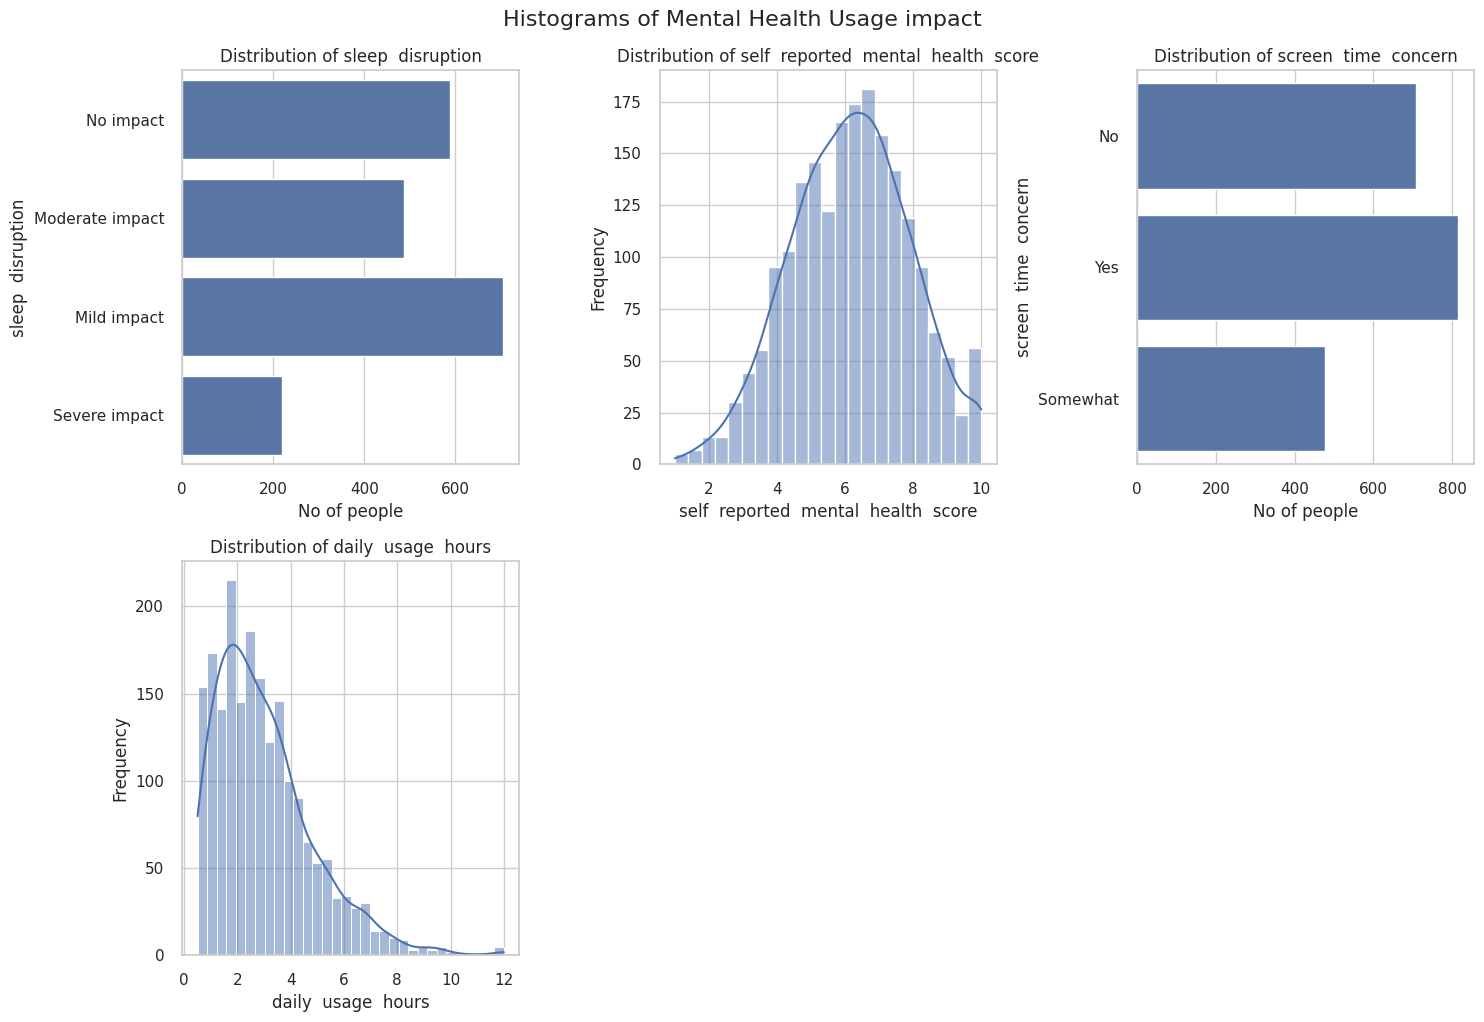

In [ ]:
numerical =[]
objects = []

plt.figure(figsize=(15, 10))
num_features = len(X_Mental_Health_Usage_implact.columns)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(X_Mental_Health_Usage_implact.columns):
    plt.subplot(num_rows, num_cols, i + 1)

    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        objects.append(feature)
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature.replace("_","  ")}')
        plt.xlabel('No of people')
        plt.ylabel(feature.replace("_","  "))
    else: # Handle numerical features
        numerical.append(feature)
        sb.histplot(df_cleaned[feature], kde=True)
        plt.title(f'Distribution of {feature.replace("_","  ")}')
        plt.xlabel(feature.replace("_","  "))
        plt.ylabel('Frequency')

print(numerical)
print(objects)

plt.tight_layout()
plt.suptitle('Histograms of Mental Health Usage impact', y=1.02, fontsize=16)
plt.show()

['self_reported_mental_health_score', 'daily_usage_hours']  -- numerical


['sleep_disruption', 'screen_time_concern'] -- categorical


#### Elbow Method for clustering

In [ ]:
inertia = []
silhouette_scores =[]
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X_Mental_Health_scaled)
    inertia.append(kmeans.inertia_)

    # Silhouette score
    labels = kmeans.fit_predict(X_Mental_Health_scaled)
    score = silhouette_score(X_Mental_Health_scaled, labels)
    silhouette_scores.append(score)

print("Elbow score: ")
print(inertia)

for k, score in zip(K, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")



Elbow score: 
[11623.45474296799, 9551.388969396095, 7918.306406001015, 6722.789706131857, 6170.069851463748, 5642.0642198915675, 5161.4281638815355, 4785.78045494539, 4421.160652776706]
K=2: Silhouette Score = 0.1849
K=3: Silhouette Score = 0.2439
K=4: Silhouette Score = 0.2797
K=5: Silhouette Score = 0.2933
K=6: Silhouette Score = 0.2736
K=7: Silhouette Score = 0.3048
K=8: Silhouette Score = 0.3329
K=9: Silhouette Score = 0.3532
K=10: Silhouette Score = 0.3581


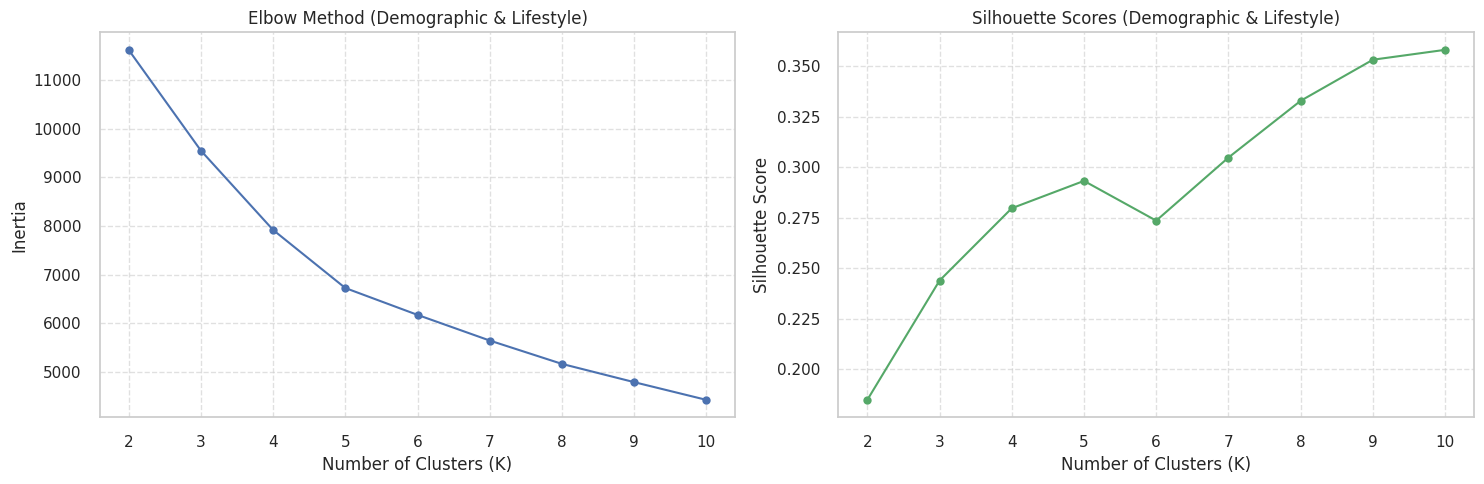

In [ ]:
plt.figure(figsize=(15, 5))

# Plotting Inertia (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o', color='b')
plt.title('Elbow Method (Demographic & Lifestyle)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='g')
plt.title('Silhouette Scores (Demographic & Lifestyle)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Clustering- Kmeans and PCA

In [ ]:
kmeans_model = apply_kmeans(k=5,cluster_name='Kmeans_clusters_Mental_Health', x_scaled=X_Mental_Health_scaled) # X_Mental_Health_scaled

Kmeans_clusters_Mental_Health
0    535
1    460
4    414
3    371
2    220
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'Mental_Health_scaled'
pca_Df = apply_PCA(X_Mental_Health_scaled, df_cleaned, cluster_col_name='Kmeans_clusters_Mental_Health', output_cluster_col_name='Mental_Health_Clusters')



In [ ]:
import plotly.express as px
# Call the function to visualize the PCA results
apply_PCA_visualization (pca_Df, 'Mental_Health_Clusters')

#### Profiling of CLusters by naming

In [ ]:
# Identify ONLY numerical features within mental_health_featuress to avoid TypeErrors
numerical_mental_health_features = [f for f in mental_health_features if df_cleaned[f].dtype in ['int64', 'float64']]

# Group by cluster and calculate mean only for numeric columns
cluster_summary_numerical = df_cleaned.groupby('Kmeans_clusters_Mental_Health')[numerical_mental_health_features].mean()

display(cluster_summary_numerical)

,self_reported_mental_health_score,daily_usage_hours
Kmeans_clusters_Mental_Health,,
0,6.090093,3.077944
1,6.091957,2.862609
2,6.140000,3.095909
3,6.262264,2.911590
4,6.298792,3.035024


In [ ]:
# Numirical Features Profiling -- mental_health_features
categorical_mental_health_features = [f for f in mental_health_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in mental_health_features:
    print(f"\nMost frequent '{feature.replace("_"," ").title()}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_clusters_Mental_Health')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'Sleep Disruption' by KMeans Cluster:


,sleep_disruption
Kmeans_clusters_Mental_Health,
0,Mild impact
1,No impact
2,Severe impact
3,Moderate impact
4,Mild impact



Most frequent 'Self Reported Mental Health Score' by KMeans Cluster:


,self_reported_mental_health_score
Kmeans_clusters_Mental_Health,
0,6.5
1,6.7
2,6.1
3,6.2
4,10.0



Most frequent 'Screen Time Concern' by KMeans Cluster:


,screen_time_concern
Kmeans_clusters_Mental_Health,
0,Yes
1,Yes
2,No
3,Yes
4,Somewhat



Most frequent 'Daily Usage Hours' by KMeans Cluster:


,daily_usage_hours
Kmeans_clusters_Mental_Health,
0,0.5
1,0.5
2,3.6
3,2.5
4,1.8


In [ ]:
# Percentage crosstab of features
for feature in mental_health_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_clusters_Mental_Health'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


sleep_disruption


sleep_disruption,Mild impact,Moderate impact,No impact,Severe impact
Kmeans_clusters_Mental_Health,,,,
0,100.0,0.0,0.0,0.0
1,0.0,0.0,100.0,0.0
2,0.0,0.0,0.0,100.0
3,0.0,100.0,0.0,0.0
4,41.0,28.0,31.0,0.0



self_reported_mental_health_score


self_reported_mental_health_score,1.0,1.2,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,...,9.1,9.2,9.3,9.4,9.5,9.6,9.7,9.8,9.9,10.0
Kmeans_clusters_Mental_Health,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0



screen_time_concern


screen_time_concern,No,Somewhat,Yes
Kmeans_clusters_Mental_Health,,,
0,45.0,0.0,55.0
1,48.0,0.0,52.0
2,38.0,28.0,34.0
3,44.0,0.0,56.0
4,0.0,100.0,0.0



daily_usage_hours


daily_usage_hours,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,...,9.2,9.4,9.5,9.6,9.7,9.9,10.0,10.5,11.1,12.0
Kmeans_clusters_Mental_Health,,,,,,,,,,,,,,,,,,,,,
0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5.0,1.0,3.0,2.0,1.0,1.0,3.0,2.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,1.0,1.0,3.0,2.0,2.0,2.0,4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,1.0,2.0,1.0,2.0,3.0,3.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# 'sleep_disruption',
#     'self_reported_mental_health_score',
#     'screen_time_concern',
#     'daily_usage_hours'

In [ ]:
# Map descriptive names for the Demographic & Lifestyle clusters
mental_health_cluster_names = {
    0: "Mid Impact Users",
    1: "Healthy Users",
    2: "High Impact Users",
    3: "Moderate Impact Users",
    4: "Balanced Users"
}

df_cleaned['mental_health_Segment'] = df_cleaned['Kmeans_clusters_Mental_Health'].map(mental_health_cluster_names)
print(df_cleaned['mental_health_Segment'].value_counts())

mental_health_Segment
Mid Impact Users         535
Healthy Users            460
Balanced Users           414
Moderate Impact Users    371
High Impact Users        220
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'Mental_Health_scaled'
pca_Df = apply_PCA(X_Mental_Health_scaled, df_cleaned, cluster_col_name='mental_health_Segment', output_cluster_col_name='Mental_Health_Clusters')



In [ ]:
import plotly.express as px
# Call the function to visualize the PCA results
apply_PCA_visualization (pca_Df, 'Mental_Health_Clusters')

**Identify categorical vs numerical features for appropriate plotting**

In [ ]:
pd.crosstab(df_cleaned['mental_health_Segment'], df_cleaned['screen_time_concern'])

screen_time_concern,No,Somewhat,Yes
mental_health_Segment,,,
Balanced Users,0,414,0
Healthy Users,219,0,241
High Impact Users,83,62,75
Mid Impact Users,242,0,293
Moderate Impact Users,165,0,206


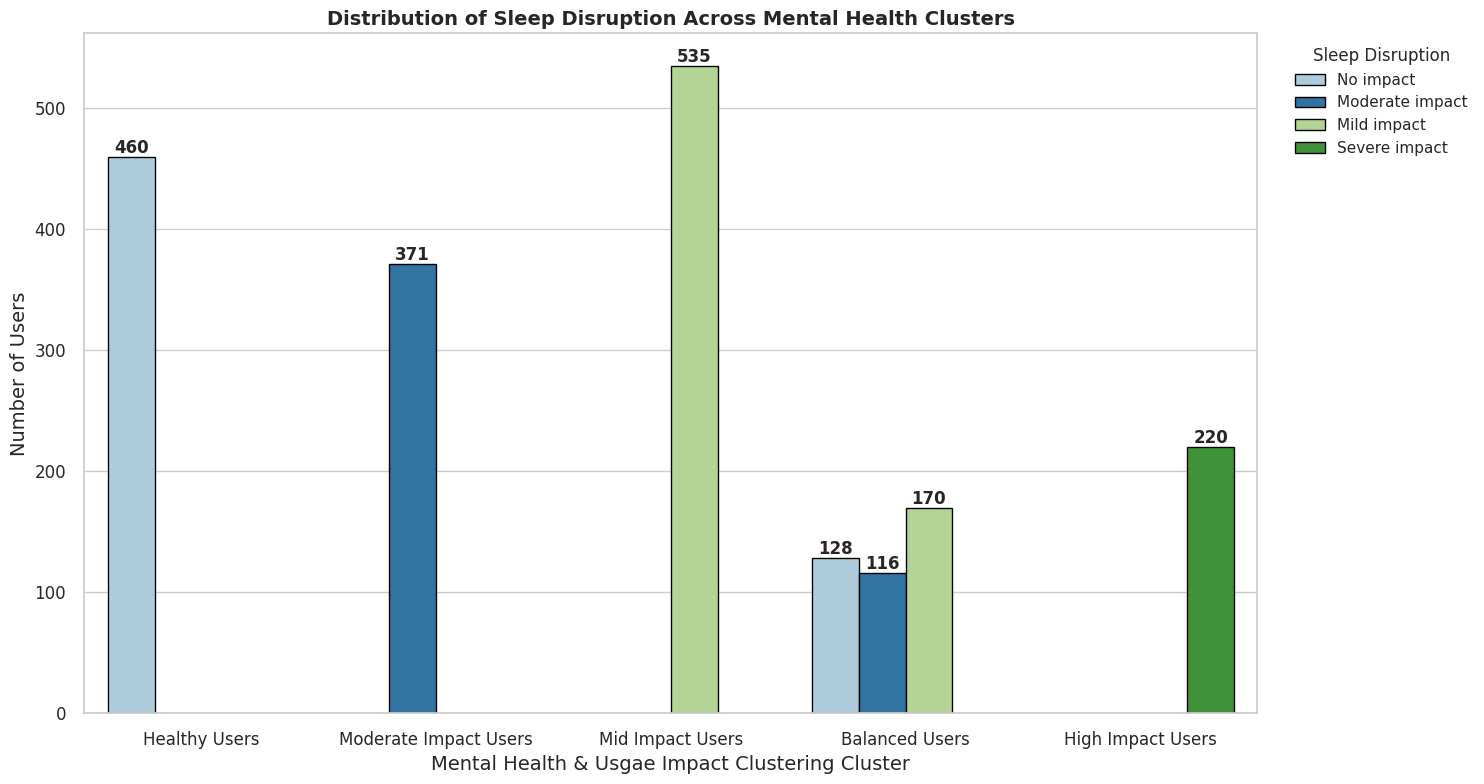

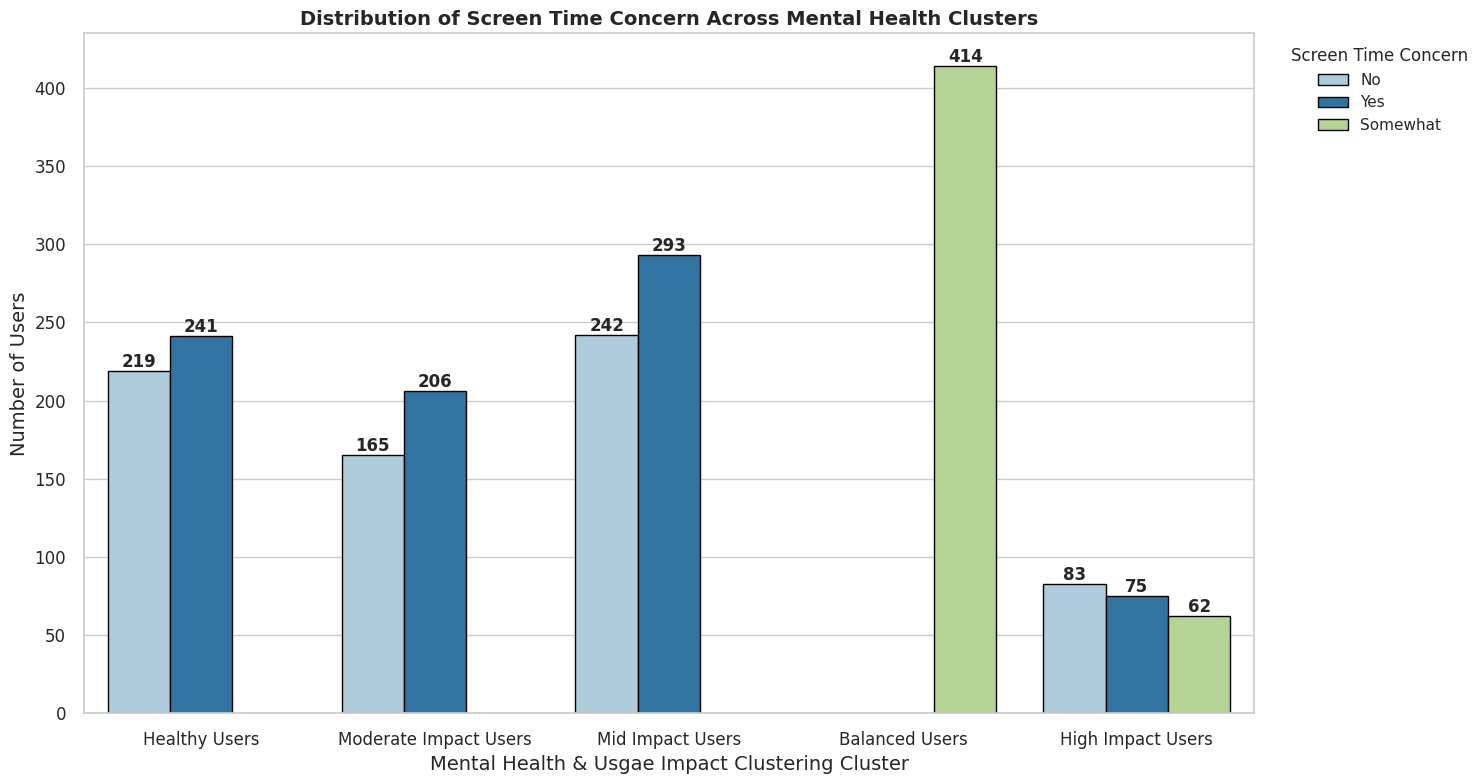

In [ ]:

sb.set_theme(style="whitegrid")

for f in objects:
  plt.figure(figsize=(15, 8))

  ax = sb.countplot(data=df_cleaned, x='mental_health_Segment', hue=f, palette='Paired', edgecolor='black')

  # Add counts on bars
  for container in ax.containers:
      ax.bar_label(container, fontsize=12, fontweight='bold')

  plt.title(f'Distribution of {f.replace("_", " ").title()} Across Mental Health Clusters', fontsize=14, fontweight='bold')
  plt.ylabel('Number of Users',fontweight=14, fontsize= 14)
  plt.legend(title='Sleep Disruption')
  plt.xlabel('Mental Health & Usgae Impact Clustering Cluster',fontweight=14, fontsize= 14 )


  plt.legend(
    title=f.replace("_", " ").title(),
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
  )

  plt.xticks(fontsize=12, fontweight=12)
  plt.yticks(fontsize=12, fontweight=12)
  plt.tight_layout()
  plt.show()

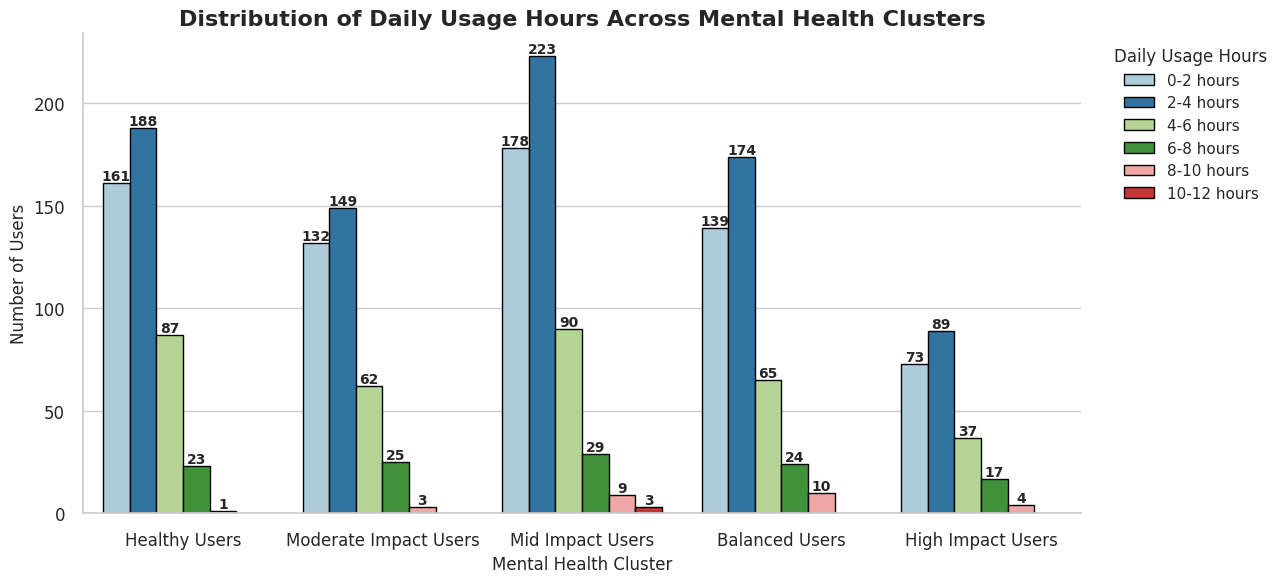

In [ ]:
max_usage = df_cleaned['daily_usage_hours'].max()

# Create 2-hour intervals
bins = np.arange(0, max_usage + 2, 2)
labels = [f'{int(b)}-{int(b+2)} hours' for b in bins[:-1]]

# Create temporary bins
df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['daily_usage_hours'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Style
sb.set_theme(style="whitegrid")

plt.figure(figsize=(13, 6))

ax = sb.countplot(
    data=df_cleaned,
    x='mental_health_Segment',
    hue='duration_bin',
    palette='Paired' ,
    edgecolor='black'
)

# Add counts
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold')

plt.title(
    'Distribution of Daily Usage Hours Across Mental Health Clusters',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Mental Health Cluster')
plt.ylabel('Number of Users')
plt.xticks(fontsize=12, fontweight=12)
plt.yticks(fontsize=12, fontweight=12)

plt.legend(
    title='Daily Usage Hours',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sb.despine()
plt.tight_layout()
plt.show()

# Cleanup
df_cleaned.drop(columns=['duration_bin'], inplace=True)

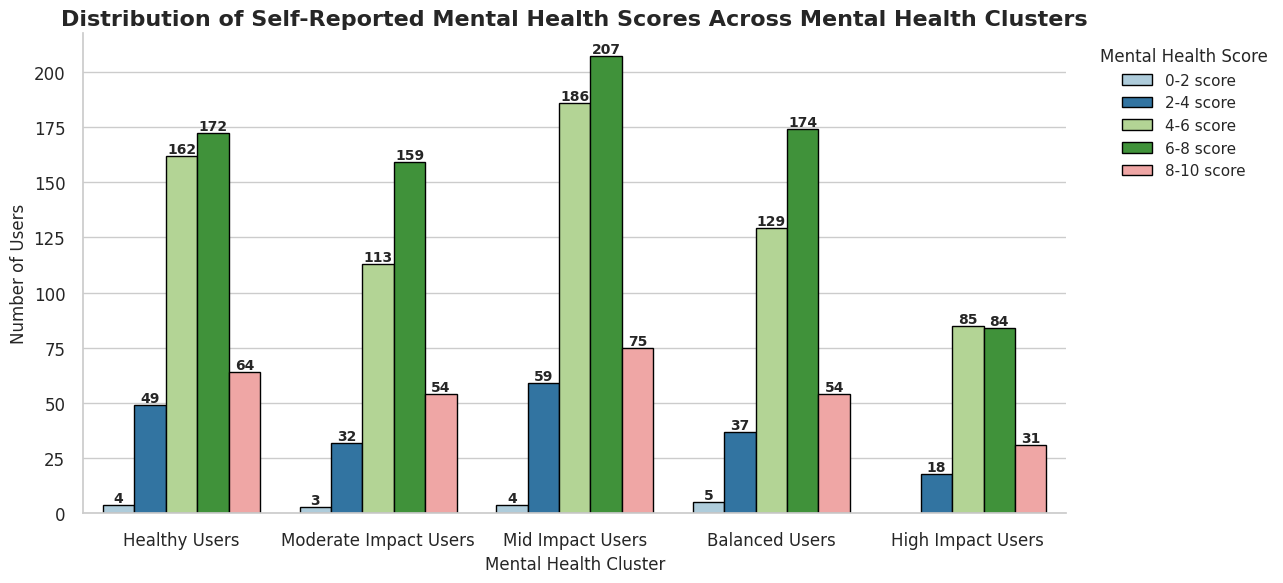

In [ ]:
max_usage = df_cleaned['self_reported_mental_health_score'].max()

# Create score intervals
bins = np.arange(0, max_usage + 2, 2)
labels = [f'{int(b)}-{int(b+2)} score' for b in bins[:-1]]

# Create temporary bins
df_cleaned['duration_bin'] = pd.cut(
    df_cleaned['self_reported_mental_health_score'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Style
sb.set_theme(style="whitegrid")

plt.figure(figsize=(13, 6))

ax = sb.countplot(
    data=df_cleaned,
    x='mental_health_Segment',
    hue='duration_bin',
    palette='Paired',
    edgecolor='black'
)

# Add counts
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold')

plt.title(
    'Distribution of Self-Reported Mental Health Scores Across Mental Health Clusters',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Mental Health Cluster')
plt.ylabel('Number of Users')
plt.xticks(fontsize=12, fontweight=12)
plt.yticks(fontsize=12, fontweight=12)

plt.legend(
    title='Mental Health Score',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sb.despine()
plt.tight_layout()
plt.show()

# Cleanup
df_cleaned.drop(columns=['duration_bin'], inplace=True)

#### DBSCAN Clustering

In [ ]:
# Example for MEntal heath features (mental_health_features)
dbscan = DBSCAN(eps=3, min_samples=5) # Tune these parameters
df_cleaned['DBSCAN_cluster_Mental_Health'] = dbscan.fit_predict(X_Mental_Health_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_Mental_Health'].value_counts())

DBSCAN_cluster_Mental_Health
0    1780
1     220
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_Mental_Health_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_Mental_Health_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_Mental_Health']
mask = d_labels != -1

sil_d = silhouette_score(X_Mental_Health_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_Mental_Health_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.29
KMeans Davies-Bouldin Index: 1.36

DBSCAN Silhouette Score: 0.28
DBSCAN Davies-Bouldin Index: 1.30


In [ ]:
# Percentage crosstab of features
for feature in mental_health_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_Mental_Health'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


sleep_disruption


sleep_disruption,Mild impact,Moderate impact,No impact,Severe impact
DBSCAN_cluster_Mental_Health,,,,
0,40.0,27.0,33.0,0.0
1,0.0,0.0,0.0,100.0



self_reported_mental_health_score


self_reported_mental_health_score,1.0,1.2,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,...,9.1,9.2,9.3,9.4,9.5,9.6,9.7,9.8,9.9,10.0
DBSCAN_cluster_Mental_Health,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0



screen_time_concern


screen_time_concern,No,Somewhat,Yes
DBSCAN_cluster_Mental_Health,,,
0,35.0,23.0,42.0
1,38.0,28.0,34.0



daily_usage_hours


daily_usage_hours,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,...,9.2,9.4,9.5,9.6,9.7,9.9,10.0,10.5,11.1,12.0
DBSCAN_cluster_Mental_Health,,,,,,,,,,,,,,,,,,,,,
0,4.0,1.0,2.0,1.0,2.0,2.0,3.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,1.0,1.0,3.0,2.0,2.0,2.0,4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Spendings_names = {
    0: "Moderate Impact Users",
    1: "High Impact Users",

}

df_cleaned['DBSCAN_Mental_Health_Names'] = df_cleaned['DBSCAN_cluster_Mental_Health'].map(dbscan_Spendings_names)
print(df_cleaned['DBSCAN_Mental_Health_Names'].value_counts())


DBSCAN_Mental_Health_Names
Moderate Impact Users    1780
High Impact Users         220
Name: count, dtype: int64


### **Platform Usage Behavior**

In [ ]:
platform_features = np.array([
    'primary_platform',
    'platforms_used_count',
    'peak_usage_time',
    'preferred_content_type',
    'privacy_setting'
])

x_Platform_Usage_Behavior= df_cleaned[platform_features]

#### scaling And Encoding

In [ ]:
X_Platform_Usage_Behavior = pd.get_dummies(x_Platform_Usage_Behavior, drop_first=True) # Encoding
X_Platform_Usage_Behavior_scaled = StandardScaler().fit_transform(X_Platform_Usage_Behavior) # Scaling

In [ ]:
pd.crosstab(df_cleaned['primary_platform'], df_cleaned['platforms_used_count']) # how many social media platforms a user typically engages with.

platforms_used_count,1,2,3,4,5
primary_platform,,,,,
Facebook,53,61,53,46,57
Instagram,85,71,96,65,98
LinkedIn,17,21,22,25,25
Pinterest,30,12,16,14,14
Snapchat,40,26,38,27,27
TikTok,65,80,79,78,93
Twitter/X,71,55,59,70,61
YouTube,50,55,47,48,50


[np.str_('platforms_used_count')]
[np.str_('primary_platform'), np.str_('peak_usage_time'), np.str_('preferred_content_type'), np.str_('privacy_setting')]


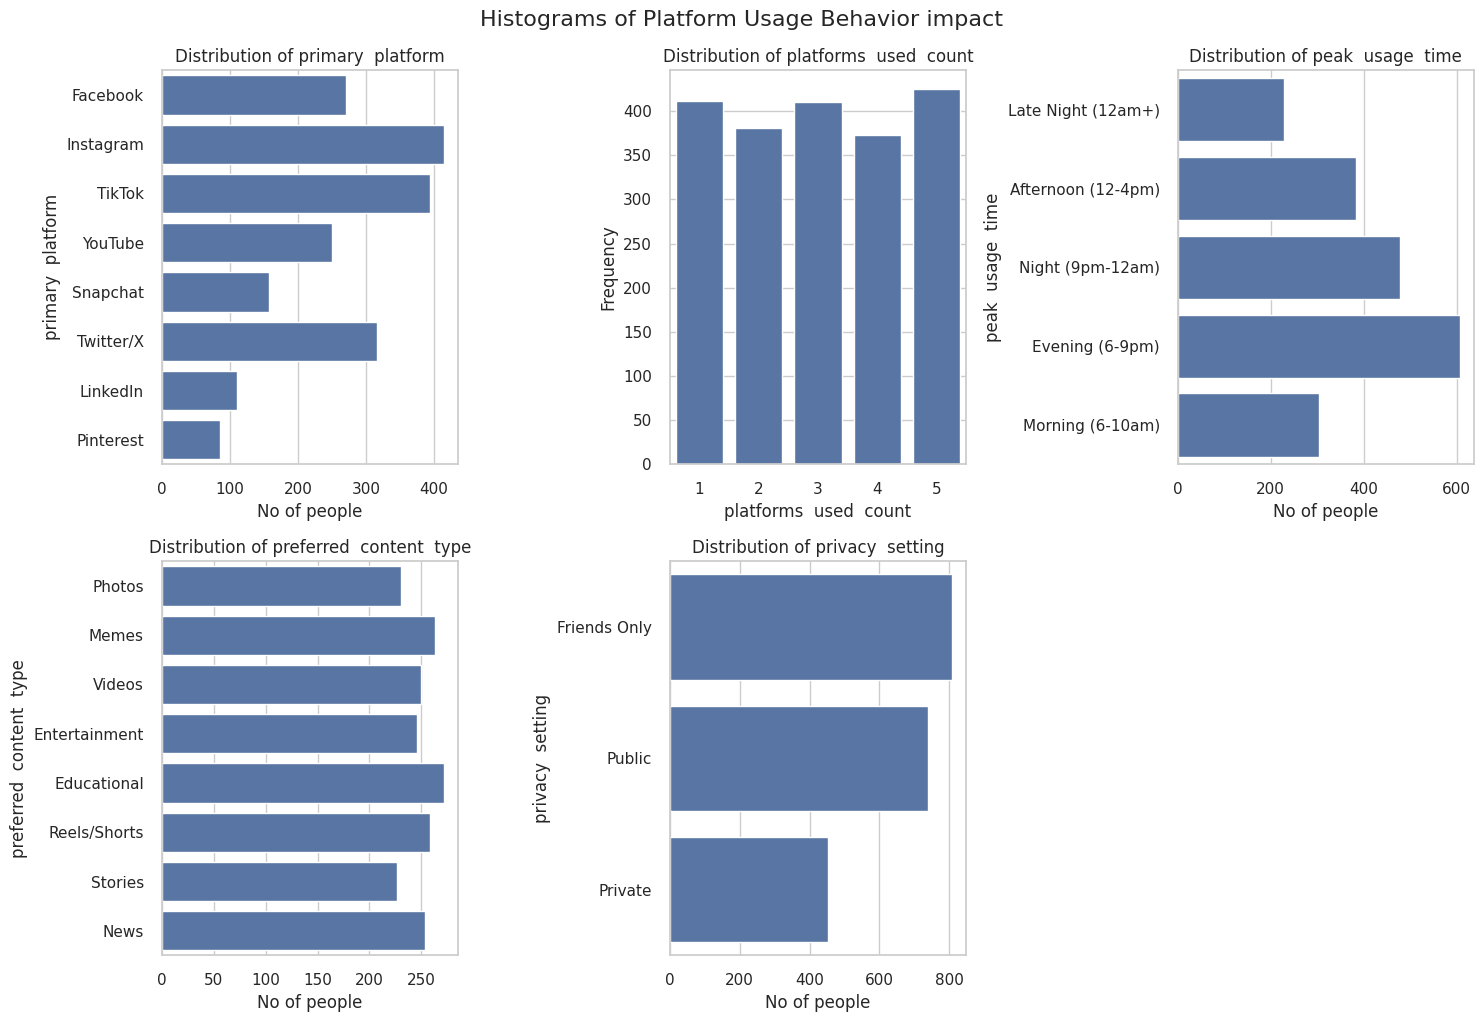

In [ ]:
numerical =[]
objects_platform = []

plt.figure(figsize=(15, 10))
num_features = len(platform_features)
# Calculate rows and columns for subplot grid, aiming for approx square layout
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

for i, feature in enumerate(platform_features):
    plt.subplot(num_rows, num_cols, i + 1)

    if df_cleaned[feature].dtype == 'object': # Handle categorical features
        objects_platform.append(feature)
        sb.countplot(y=df_cleaned[feature])
        plt.title(f'Distribution of {feature.replace("_","  ")}')
        plt.xlabel('No of people')
        plt.ylabel(feature.replace("_","  "))
    else: # Handle numerical features
        numerical.append(feature)
        sb.countplot(x= df_cleaned[feature])
        plt.title(f'Distribution of {feature.replace("_","  ")}')
        plt.xlabel(feature.replace("_","  "))
        plt.ylabel('Frequency')

print(numerical)
print(objects_platform)

plt.tight_layout()
plt.suptitle('Histograms of Platform Usage Behavior impact', y=1.02, fontsize=16)
plt.show()

#### Elbow Method and Silhouette Score for clustering

In [ ]:
inertia = []
silhouette_scores =[]
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X_Platform_Usage_Behavior_scaled)
    inertia.append(kmeans.inertia_)

    # Silhouette score
    labels = kmeans.fit_predict(X_Platform_Usage_Behavior_scaled)
    score = silhouette_score(X_Platform_Usage_Behavior_scaled, labels)
    silhouette_scores.append(score)

print("Elbow score: ")
print(inertia)

for k, score in zip(K, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")



Elbow score: 
[39437.31732302132, 37586.11103919392, 35208.18702070822, 33294.99719046308, 30999.308231001098, 29071.051552783825, 27498.38534137245, 26354.21723102857, 25995.84107127577]
K=2: Silhouette Score = 0.0572
K=3: Silhouette Score = 0.0909
K=4: Silhouette Score = 0.1010
K=5: Silhouette Score = 0.1332
K=6: Silhouette Score = 0.1617
K=7: Silhouette Score = 0.1746
K=8: Silhouette Score = 0.1828
K=9: Silhouette Score = 0.1567
K=10: Silhouette Score = 0.1579


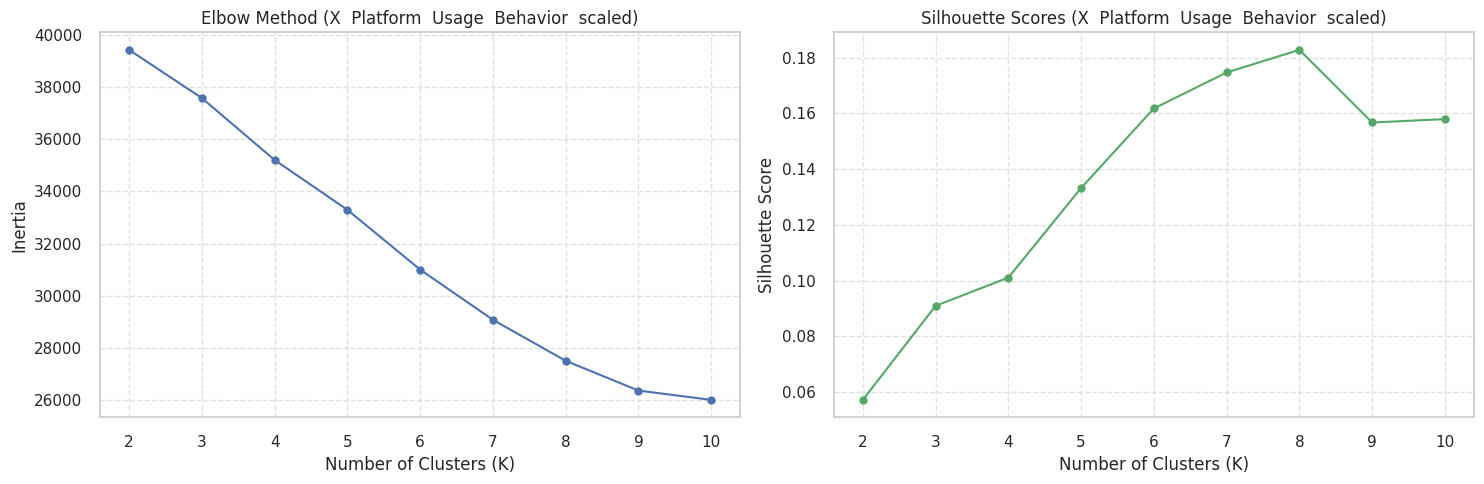

In [ ]:
plt.figure(figsize=(15, 5))
titile ='X_Platform_Usage_Behavior_scaled'
# Plotting Inertia (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o', color='b')
plt.title(f'Elbow Method ({titile.replace("_","  ")})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.6)

# Plotting Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='g')
plt.title(f'Silhouette Scores ({titile.replace("_","  ")})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Clustering- Kmeans and PCA

In [ ]:
kmeans_model = apply_kmeans(k=5,cluster_name='Kmeans_cluster_Platform_Usage_Behavior', x_scaled=X_Platform_Usage_Behavior_scaled) # X_Platform_Usage_Behavior_scaled

Kmeans_cluster_Platform_Usage_Behavior
1    785
4    485
2    254
3    246
0    230
Name: count, dtype: int64


In [ ]:
# Implement the function call with a new output column name, for example 'Platform_Usage_Behavior_scaled'
pca_Df = apply_PCA(X_Platform_Usage_Behavior_scaled, df_cleaned, cluster_col_name='Kmeans_cluster_Platform_Usage_Behavior', output_cluster_col_name='Platform_Usage_Behavior_Clusters')

In [ ]:
# Call the function to visualize the PCA results
apply_PCA_visualization(pca_Df, 'Platform_Usage_Behavior_Clusters')

#### Profiling of CLusters by naming

In [ ]:
# Identify ONLY numerical features within demographic_lifestyle_features to avoid TypeErrors
numerical_platform_features = [f for f in platform_features if df_cleaned[f].dtype in ['int64', 'float64']]

# Group by cluster and calculate mean only for numeric columns
cluster_summary_numerical = df_cleaned.groupby('Kmeans_cluster_Platform_Usage_Behavior')[numerical_platform_features].mean()

display(cluster_summary_numerical)

,platforms_used_count
Kmeans_cluster_Platform_Usage_Behavior,
0,3.034783
1,3.021656
2,2.885827
3,3.048780
4,3.024742


In [ ]:
# Numirical Features Profiling
categorical_numerical_platform_features = [f for f in platform_features if f in df_cleaned.select_dtypes(include=['object', 'category']).columns]

for feature in platform_features:
    print(f"\nMost frequent '{feature.replace("_"," ").title()}' by KMeans Cluster:")
    mode_by_cluster = df_cleaned.groupby('Kmeans_cluster_Platform_Usage_Behavior')[feature].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
    display(mode_by_cluster)


Most frequent 'Primary Platform' by KMeans Cluster:


,primary_platform
Kmeans_cluster_Platform_Usage_Behavior,
0,TikTok
1,TikTok
2,Instagram
3,Twitter/X
4,Instagram



Most frequent 'Platforms Used Count' by KMeans Cluster:


,platforms_used_count
Kmeans_cluster_Platform_Usage_Behavior,
0,5
1,5
2,1
3,2
4,4



Most frequent 'Peak Usage Time' by KMeans Cluster:


,peak_usage_time
Kmeans_cluster_Platform_Usage_Behavior,
0,Evening (6-9pm)
1,Evening (6-9pm)
2,Evening (6-9pm)
3,Evening (6-9pm)
4,Night (9pm-12am)



Most frequent 'Preferred Content Type' by KMeans Cluster:


,preferred_content_type
Kmeans_cluster_Platform_Usage_Behavior,
0,Photos
1,Educational
2,News
3,Entertainment
4,Reels/Shorts



Most frequent 'Privacy Setting' by KMeans Cluster:


,privacy_setting
Kmeans_cluster_Platform_Usage_Behavior,
0,Friends Only
1,Friends Only
2,Friends Only
3,Friends Only
4,Friends Only


In [ ]:
# Percentage crosstab of features
for feature in categorical_numerical_platform_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['Kmeans_cluster_Platform_Usage_Behavior'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


primary_platform


primary_platform,Facebook,Instagram,LinkedIn,Pinterest,Snapchat,TikTok,Twitter/X,YouTube
Kmeans_cluster_Platform_Usage_Behavior,,,,,,,,
0,14.0,20.0,3.0,4.0,10.0,23.0,14.0,12.0
1,13.0,19.0,6.0,5.0,6.0,21.0,16.0,13.0
2,13.0,23.0,6.0,4.0,9.0,19.0,15.0,13.0
3,12.0,20.0,4.0,3.0,9.0,19.0,21.0,12.0
4,15.0,22.0,6.0,4.0,9.0,17.0,14.0,12.0



peak_usage_time


peak_usage_time,Afternoon (12-4pm),Evening (6-9pm),Late Night (12am+),Morning (6-10am),Night (9pm-12am)
Kmeans_cluster_Platform_Usage_Behavior,,,,,
0,21.0,34.0,12.0,11.0,22.0
1,18.0,33.0,11.0,15.0,23.0
2,17.0,31.0,11.0,17.0,24.0
3,19.0,27.0,17.0,14.0,24.0
4,20.0,26.0,10.0,16.0,27.0



preferred_content_type


preferred_content_type,Educational,Entertainment,Memes,News,Photos,Reels/Shorts,Stories,Videos
Kmeans_cluster_Platform_Usage_Behavior,,,,,,,,
0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
1,35.0,0.0,34.0,0.0,0.0,0.0,0.0,32.0
2,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
3,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,53.0,47.0,0.0



privacy_setting


privacy_setting,Friends Only,Private,Public
Kmeans_cluster_Platform_Usage_Behavior,,,
0,46.0,20.0,34.0
1,38.0,26.0,36.0
2,43.0,18.0,39.0
3,40.0,22.0,38.0
4,40.0,21.0,39.0


In [ ]:
# Map descriptive names for the socail platform
demographic_lifestyle_cluster_names = {
    0: "Visual Social Users",
    1: "Mixed Social Users",
    2: "News Socaial Professionals",
    3: "Entertainment Social Users",
    4: "Short-Video Social Users"
}

df_cleaned['Platform_Usage_Behavior_Segment'] = df_cleaned['Kmeans_cluster_Platform_Usage_Behavior'].map(demographic_lifestyle_cluster_names)

In [ ]:
# Implement the function call with a new output column name, for example 'Platform_Usage_Behavior_scaled'
pca_Df = apply_PCA(X_Platform_Usage_Behavior_scaled, df_cleaned, cluster_col_name='Platform_Usage_Behavior_Segment', output_cluster_col_name='Platform_Usage_Behavior_Clusters')

In [ ]:
# Call the function to visualize the PCA results
apply_PCA_visualization(pca_Df, 'Platform_Usage_Behavior_Clusters')

**Identify categorical vs numerical features for appropriate plotting**

In [ ]:
pd.crosstab(df_cleaned['Platform_Usage_Behavior_Segment'], df_cleaned['preferred_content_type'])

preferred_content_type,Educational,Entertainment,Memes,News,Photos,Reels/Shorts,Stories,Videos
Platform_Usage_Behavior_Segment,,,,,,,,
Entertainment Social Users,0,246,0,0,0,0,0,0
Mixed Social Users,272,0,263,0,0,0,0,250
News Socaial Professionals,0,0,0,254,0,0,0,0
Short-Video Social Users,0,0,0,0,0,258,227,0
Visual Social Users,0,0,0,0,230,0,0,0


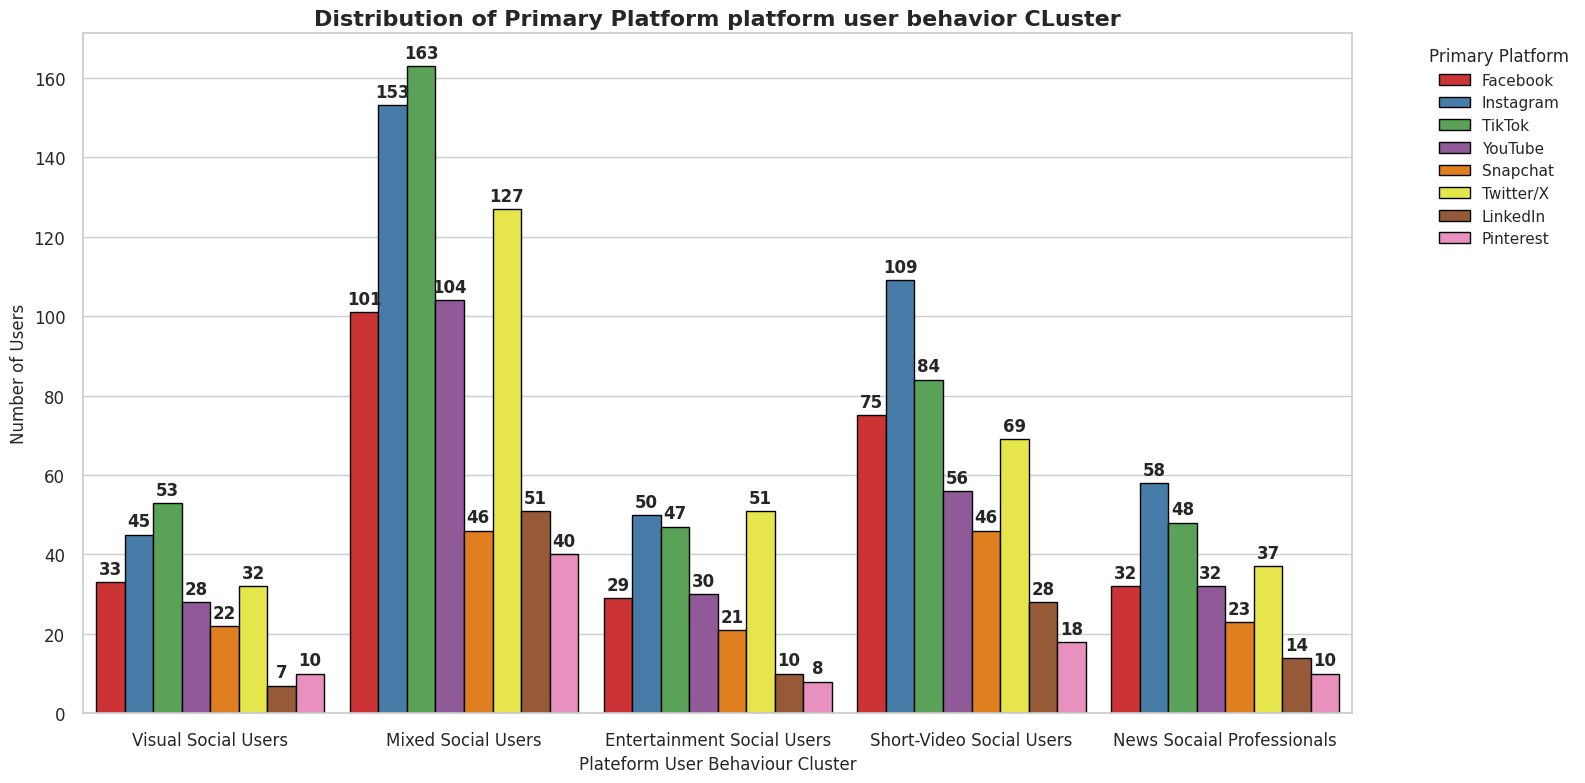

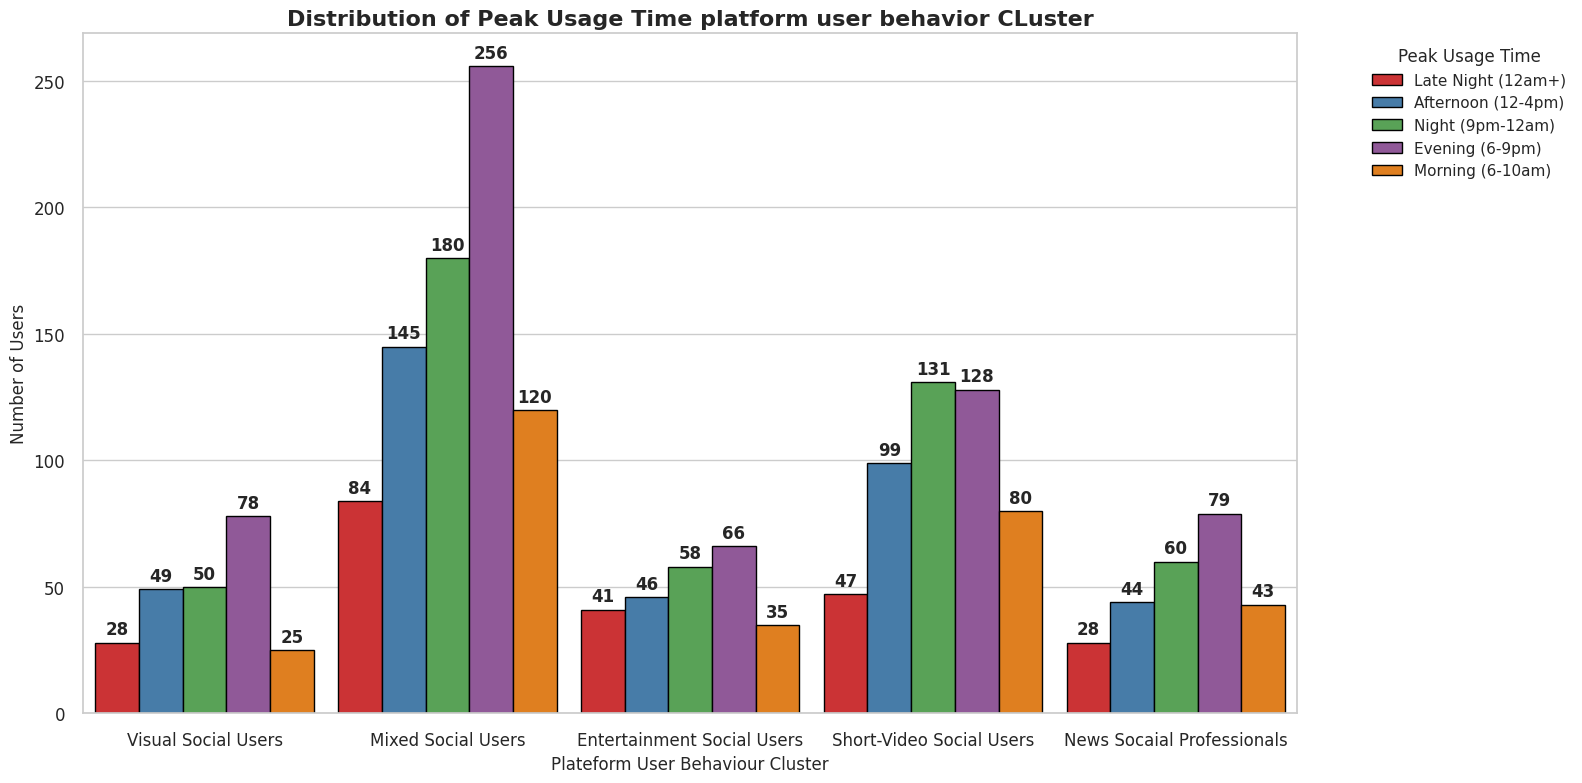

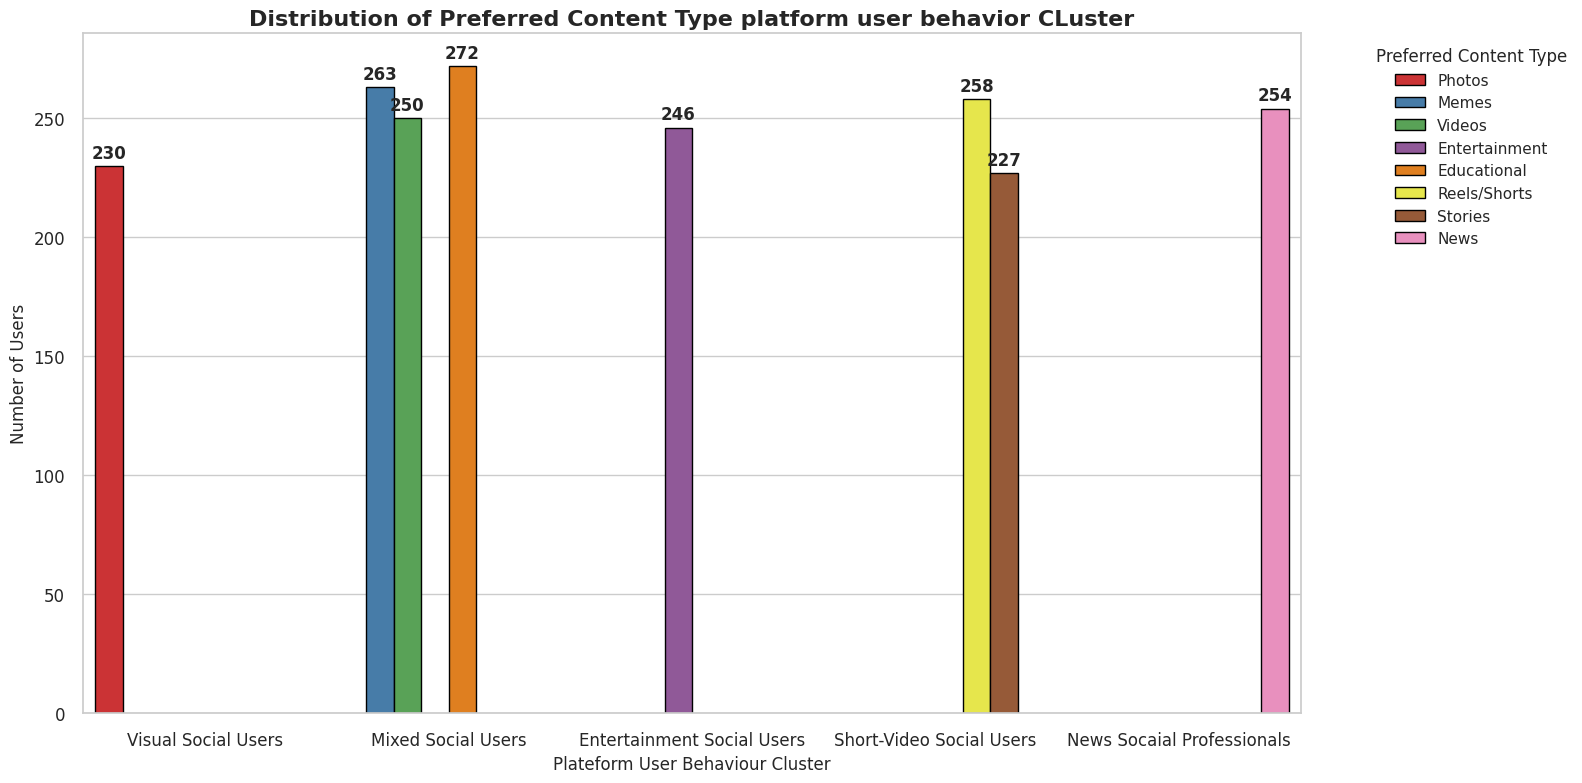

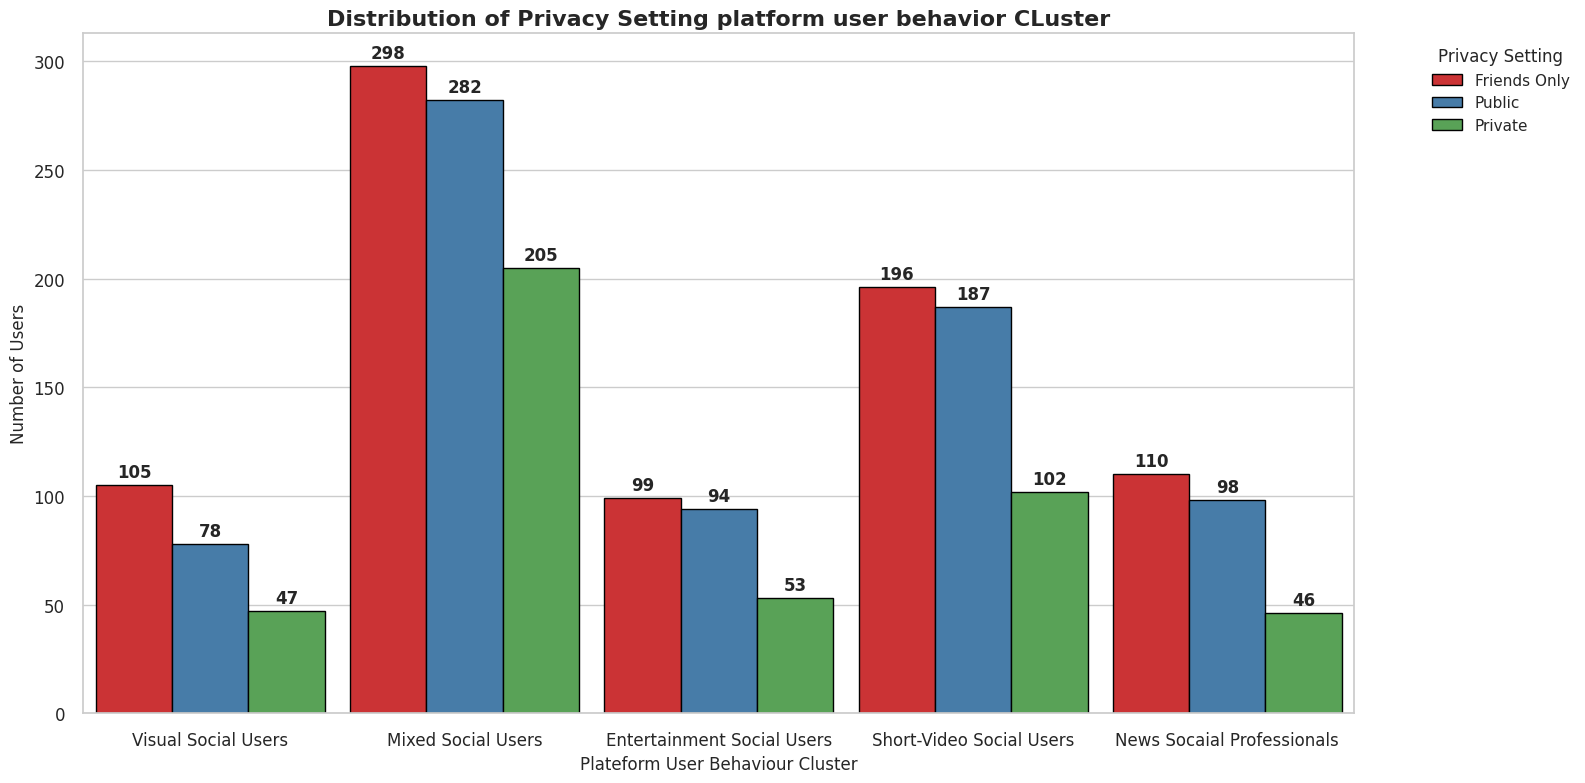

In [ ]:
sb.set_theme(style="whitegrid")
for f in objects_platform:
  plt.figure(figsize=(16, 8))
  plt.title(f'Distribution of {f.replace("_", " ").title()} platform user behavior CLuster',
            fontsize=16, fontweight='bold')

  ax = sb.countplot(data=df_cleaned, x='Platform_Usage_Behavior_Segment', hue=f,
                    palette='Set1',edgecolor='black',width=0.9)

  # Add clunts on bars
  for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold',padding=3)

  plt.ylabel('Number of Users')
  plt.xlabel('Plateform User Behaviour Cluster')
  plt.xticks(fontsize=12, fontweight=12)
  plt.yticks(fontsize=12, fontweight=12)

  plt.legend(title= f.replace("_"," ").title(), bbox_to_anchor=(1.05, 1), loc='upper left')

  plt.tight_layout()
  plt.show()

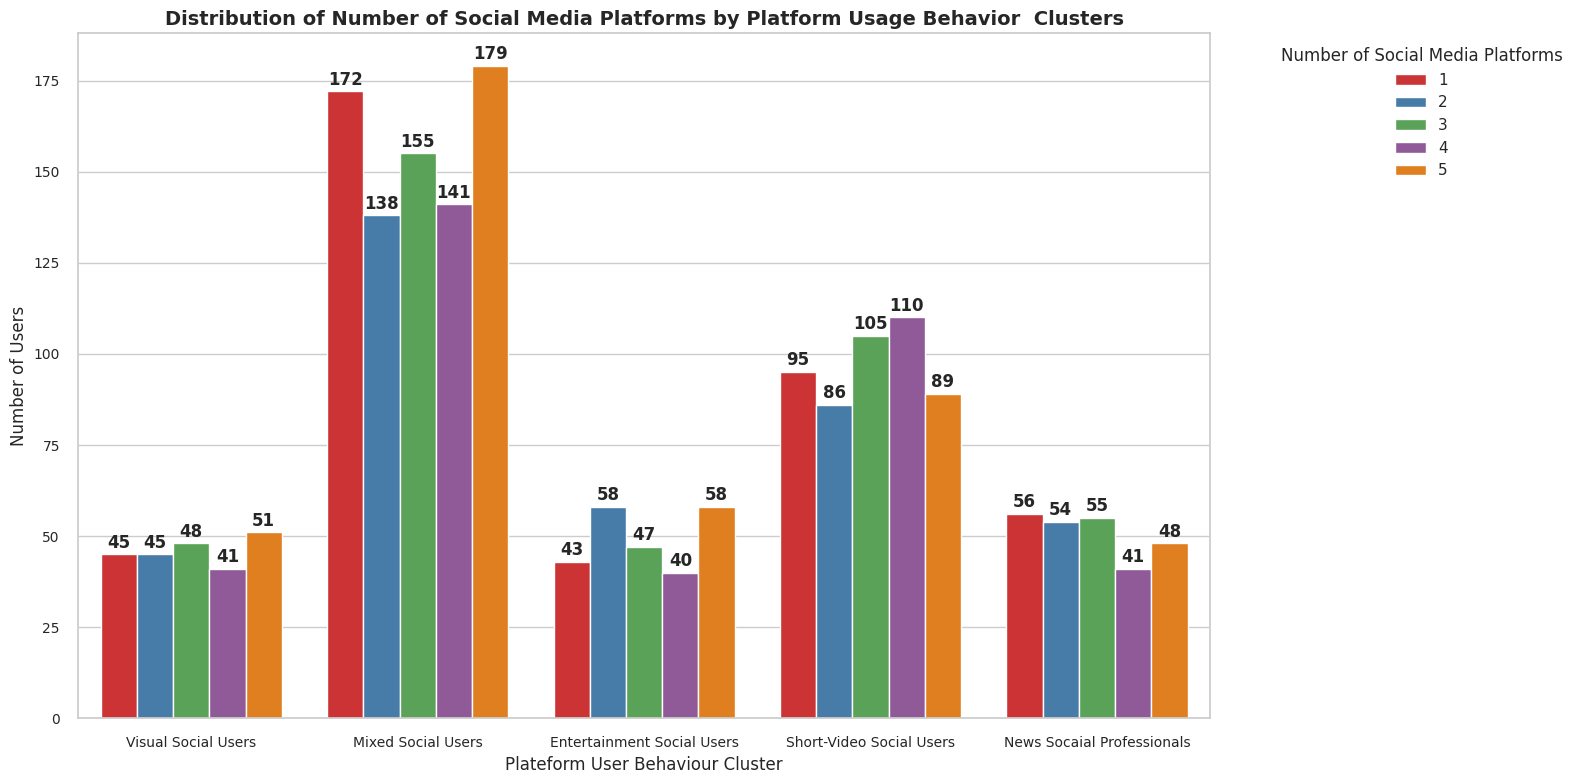

In [ ]:
plt.figure(figsize=(16, 8))
ax = sb.countplot(
      data=df_cleaned,
      x='Platform_Usage_Behavior_Segment',
      hue='platforms_used_count',
      palette='Set1'
  )
# Add clunts on bars
for container in ax.containers:
   ax.bar_label(container, fontsize=12, fontweight='bold',padding=2)


plt.ylabel('Number of Users',fontsize=12, fontweight=12)
plt.xlabel('Plateform User Behaviour Cluster',fontsize=12, fontweight=12)
plt.xticks(fontsize=10, fontweight=12)
plt.yticks(fontsize=10, fontweight=12)


plt.legend(
    title='Number of Social Media Platforms',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Distribution of Number of Social Media Platforms by Platform Usage Behavior  Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### DBSCAN Clustering

In [ ]:
# Example for Plateform usage feature (platform_features)
dbscan = DBSCAN(eps=3.5, min_samples=6) # Tune these parameters
df_cleaned['DBSCAN_cluster_Plateform_Usage'] = dbscan.fit_predict(X_Platform_Usage_Behavior_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_cluster_Plateform_Usage'].value_counts())

DBSCAN_cluster_Plateform_Usage
 0    1646
 1     156
 3     106
 2      63
-1      17
 4      12
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_k = silhouette_score(X_Platform_Usage_Behavior_scaled, kmeans_model.labels_)
dbi_k = davies_bouldin_score(X_Platform_Usage_Behavior_scaled, kmeans_model.labels_)

# DBSCAN
d_labels = df_cleaned['DBSCAN_cluster_Plateform_Usage']
mask = d_labels != -1

sil_d = silhouette_score(X_Platform_Usage_Behavior_scaled[mask], d_labels[mask])
dbi_d = davies_bouldin_score(X_Platform_Usage_Behavior_scaled[mask], d_labels[mask])

print(f"KMeans Silhouette Score: {sil_k:.2f}")
print(f"KMeans Davies-Bouldin Index: {dbi_k:.2f}")

print(f"\nDBSCAN Silhouette Score: {sil_d:.2f}")
print(f"DBSCAN Davies-Bouldin Index: {dbi_d:.2f}")

KMeans Silhouette Score: 0.13
KMeans Davies-Bouldin Index: 2.70

DBSCAN Silhouette Score: 0.14
DBSCAN Davies-Bouldin Index: 1.92


In [ ]:
# Percentage crosstab of features
for feature in platform_features:
    print(f"\n{feature}")
    display(
        pd.crosstab(
            df_cleaned['DBSCAN_cluster_Plateform_Usage'],
            df_cleaned[feature],
            normalize='index'
        ).round(2) * 100
    )


primary_platform


primary_platform,Facebook,Instagram,LinkedIn,Pinterest,Snapchat,TikTok,Twitter/X,YouTube
DBSCAN_cluster_Plateform_Usage,,,,,,,,
-1,0.0,0.0,24.0,65.0,12.0,0.0,0.0,0.0
0,16.0,25.0,0.0,0.0,0.0,24.0,19.0,15.0
1,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
2,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
3,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0



platforms_used_count


platforms_used_count,1,2,3,4,5
DBSCAN_cluster_Plateform_Usage,,,,,
-1,41.0,18.0,12.0,12.0,18.0
0,20.0,20.0,20.0,19.0,22.0
1,25.0,16.0,24.0,17.0,17.0
2,37.0,16.0,19.0,14.0,14.0
3,15.0,19.0,21.0,23.0,23.0
4,17.0,8.0,17.0,33.0,25.0



peak_usage_time


peak_usage_time,Afternoon (12-4pm),Evening (6-9pm),Late Night (12am+),Morning (6-10am),Night (9pm-12am)
DBSCAN_cluster_Plateform_Usage,,,,,
-1,6.0,0.0,41.0,53.0,0.0
0,20.0,31.0,11.0,15.0,23.0
1,19.0,26.0,15.0,14.0,27.0
2,17.0,38.0,6.0,6.0,32.0
3,16.0,31.0,7.0,17.0,29.0
4,17.0,33.0,42.0,0.0,8.0



preferred_content_type


preferred_content_type,Educational,Entertainment,Memes,News,Photos,Reels/Shorts,Stories,Videos
DBSCAN_cluster_Plateform_Usage,,,,,,,,
-1,18.0,24.0,12.0,6.0,12.0,0.0,0.0,29.0
0,14.0,13.0,13.0,13.0,12.0,13.0,11.0,13.0
1,8.0,13.0,9.0,15.0,14.0,16.0,13.0,12.0
2,19.0,6.0,14.0,14.0,16.0,14.0,14.0,2.0
3,20.0,9.0,18.0,13.0,5.0,17.0,9.0,8.0
4,8.0,0.0,0.0,0.0,0.0,0.0,0.0,92.0



privacy_setting


privacy_setting,Friends Only,Private,Public
DBSCAN_cluster_Plateform_Usage,,,
-1,53.0,12.0,35.0
0,40.0,23.0,37.0
1,43.0,21.0,37.0
2,32.0,27.0,41.0
3,40.0,20.0,41.0
4,67.0,8.0,25.0


In [ ]:
# Create a DataFrame for the scores
scores_data = {
    'Algorithm': ['K-means', 'DBSCAN'],
    'Silhouette Score': [sil_k, sil_d],
    'Davies-Bouldin Index': [dbi_k, dbi_d]
}
scores_df = pd.DataFrame(scores_data)

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=('Silhouette Score Comparison', 'Davies-Bouldin Index Comparison'))

# Create Silhouette Score bar chart
fig_sil = px.bar(scores_df, x='Algorithm', y='Silhouette Score',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Choose a palette
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Create Davies-Bouldin Index bar chart
fig_dbi = px.bar(scores_df, x='Algorithm', y='Davies-Bouldin Index',
                 color='Algorithm', # Differentiate bars by algorithm
                 color_discrete_sequence=px.colors.qualitative.Vivid, # Keep palette consistent
                 text_auto='.2f' # Automatically display values with 2 decimal places
                )

# Add traces to subplots
for trace in fig_sil.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_dbi.data:
    fig.add_trace(trace, row=1, col=2)

# Update layout for titles, axis labels and ranges
fig.update_layout(
    height=500,
    width=1000,
    showlegend=False, # Show legend to identify colors
    title_text="Comparison of Clustering Algorithm Evaluation Metrics",
    title_x=0.5,
    title_font_size=20
)

fig.update_yaxes(title_text='Silhouette Score', row=1, col=1, range=[0, max(sil_k, sil_d) * 1.2])
fig.update_yaxes(title_text='Davies-Bouldin Index', row=1, col=2, range=[0, max(dbi_k, dbi_d) * 1.2])

# Adjust bar text position if needed
fig.update_traces(textposition='outside') # Place text labels outside the bars

fig.show()

In [ ]:
dbscan_Spendings_names = {
   -1: "Diverse Platform Users",
    0: "Multi-Platform Users",
    1: "Snapchat Users",
    2: "Pinterest Users",
    3: "LinkedIn Professionals",
    4: "Video Lovers"

}

df_cleaned['DBSCAN_Cluster_Plateform_Names'] = df_cleaned['DBSCAN_cluster_Plateform_Usage'].map(dbscan_Spendings_names)
print(df_cleaned['DBSCAN_Cluster_Plateform_Names'].value_counts())


DBSCAN_Cluster_Plateform_Names
Multi-Platform Users      1646
Snapchat Users             156
LinkedIn Professionals     106
Pinterest Users             63
Diverse Platform Users      17
Video Lovers                12
Name: count, dtype: int64


# DBSCAN

In [ ]:
# combine selected features
features = numeric_features + categorical_features
# create copy for clustering
data = df[features].copy()
data.head()

,age,platforms_used_count,daily_usage_hours,sessions_per_day,avg_session_duration_min,followers_count,following_count,posts_per_week,likes_given_per_day,comments_per_day,...,scroll_speed,purchased_via_social_media,primary_purpose,sleep_disruption,screen_time_concern,notification_frequency,privacy_setting,influencer_status,mood_while_scrolling,takes_social_media_breaks
0,30,1,1.6,2,48.0,353,99,1,17,1,...,Medium,Yes,Entertainment,No impact,No,Do Not Disturb,Friends Only,No,Neutral,No
1,25,2,2.4,5,28.8,276,514,2,28,3,...,Medium,Yes,News & Updates,Moderate impact,No,Selected,Public,No,Neutral,Yes
2,32,5,0.5,6,5.0,203,422,3,26,4,...,Slow,No,Learning,Mild impact,Yes,Always On,Friends Only,No,Happy,Yes
3,39,4,3.0,7,25.7,29083,474,1,16,3,...,Fast,No,Entertainment,Mild impact,Somewhat,Always On,Public,Yes,Happy,No
4,25,3,3.9,7,33.4,104,197,2,27,7,...,Fast,No,Entertainment,Mild impact,No,Do Not Disturb,Public,No,Inspired,No


In [ ]:
# encoding
x = pd.get_dummies(df_cleaned, drop_first=True)
X_scaled = StandardScaler().fit_transform(x) # Feature Scaling

In [ ]:
from sklearn.cluster import DBSCAN

# Example for User Behavior features (X_scaled)
dbscan = DBSCAN(eps=10, min_samples=6) # Tune these parameters
df_cleaned['DBSCAN_User_Behavior_Cluster'] = dbscan.fit_predict(X_scaled)

# Cluster labels for noise points are -1
print(df_cleaned['DBSCAN_User_Behavior_Cluster'].value_counts())

DBSCAN_User_Behavior_Cluster
 0    1552
-1     448
Name: count, dtype: int64
